## PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores  

Práctica final Módulo DATA SCIENCE - 4 nov 2025  

Contenidos:  

0. Funciones Auxiliares | Imports  
1. Dataset  
    1.1 Descarga  
    1.2 Exploración de datos  
    >   1.2.1 Matriz de Correlación  
    >   1.2.2 Distribución de features por target  
    >   1.2.3 Distribución por era  
    >   1.2.4 Era specificity  

    1.3 Técnicas de preprocesamiento  
    >   1.3.1 Resample  
    >   1.3.2 PCA  
    >   1.3.3 Estandarización  
2. Modeling  
    2.1 División del conjunto de datos  
    2.2 Pruebas sobre métodos de preprocesamiento sobre Linear Regression  
    >   (Baseline, Estandarización, PCA, Resampled, Era split)  

    2.3 Modelos descartados  
    >   (K-NN, Random Forest Regressor)  

    2.4 Modelos a considerar  
    >   (LGBM Regressor, Cat Boost Regressor, XGB Regressor)  

    2.5 Análisis modelos lineal VS no lineal  
    >   2.5.1 Modelado de XGB en base a distintos preprocesamientos  
    >   2.5.2 Conclusiones  

    2.6 Entrenamiento y comparativa de modelos finales  
    >   2.6.1 Descarga de datos medium, ::2  
    >   2.6.2 Partición del dataset  
    >   2.6.3 Entrenamiento  
    >   2.6.4 Conclusiones  

    2.7 Overfitting  
3. Validation  
    3.1 F1 score VS Coeficiente de correlación de Pearson  
    3.2 Métricas de rendimiento  
4. Improvement & Investigation  
    4.1 Feature Neutralization  
    >   4.1.1 Entender cómo funciona *Neutralize* de Numerai  
    >   4.1.2 Neutralización a distintas proporciones

    4.2 Ridge Regression  
    >   4.2.1 Pruebas con distintas alphas  
    >   4.2.2 Ridge Regression estandarizado  
    >   4.2.3 Linear Regression VS Ridge Regression  

    4.3 Lasso  
    >   4.3.1 Pruebas con distintas alphas  
    >   4.3.2 LassoCV VS Linear Regression  
    
5. Submission

### 0. FUNCIONES AUXILIARES | IMPORTS

In [1]:
# Instala dependencias
!pip install -q --upgrade numerapi imblearn pandas pyarrow matplotlib lightgbm xgboost catboost scikit-learn scipy cloudpickle==3.1.1
!pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import json
from numerapi import NumerAPI
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import seaborn as sns
import matplotlib.gridspec as gridspec
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import matplotlib.colors as mcolors
from numerai_tools.scoring import neutralize
import cloudpickle
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

In [3]:
# Funciones auxiliares
# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

def corr_plots(per_era_corr_test, per_era_corr_val):
    fig, axs = plt.subplots(1,2, figsize=(20, 5))
    colors = sns.color_palette("PuRd", 2)
    # Gráfica de correlación por "era" 
    per_era_corr_test.plot(kind="bar", title="Validation Correlation", xticks=[], snap=False, color=colors[0], ax=axs[0])
    per_era_corr_test.cumsum().plot(kind="line", title="Cumulative Validation Correlation", color=colors[0], ax=axs[1])

    per_era_corr_val.plot(kind="bar", title="Validation Correlation", xticks=[], snap=False, color=colors[1], ax=axs[0])
    per_era_corr_val.cumsum().plot(kind="line", title="Cumulative Validation Correlation", color=colors[1], ax=axs[1])
    
    legend = [plt.Line2D([0], [0], linestyle="-", solid_capstyle='butt', color=colors[i % len(colors)], lw=7) for i in range(2)]
    axs[1].legend(legend, ["Test", "Validation"], title="Legend", loc='lower right')

    plt.show()

def calc_metricas(model, per_era_corr, df=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])):
    # Calcula métricas de rendimiento
    corr_mean = per_era_corr.mean()
    corr_std = per_era_corr.std(ddof=0)
    corr_sharpe = corr_mean / corr_std
    max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

    df[model] = [corr_mean, corr_std, corr_sharpe, max_drawdown]
    return df

### 1. DATASET

#### 1.1 Descarga del dataset.

In [4]:
# Descarga dataset train y validation - feature_set -> small
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
napi = NumerAPI()
DATA_VERSION = "v5.0"

# Descarga los datos de entrenamiento y los metadatos de las características
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_set = feature_metadata["feature_sets"]["small"]

train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]

# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

2025-11-04 11:14:49,472 INFO numerapi.utils: target file already exists
2025-11-04 11:14:49,473 INFO numerapi.utils: download complete
2025-11-04 11:14:50,764 INFO numerapi.utils: target file already exists
2025-11-04 11:14:50,764 INFO numerapi.utils: download complete
2025-11-04 11:14:52,132 INFO numerapi.utils: target file already exists
2025-11-04 11:14:52,132 INFO numerapi.utils: download complete


#### 1.2 Exploración de datos

1.2.1 Matriz de correlación  

> Esta es una de las gráficas más útiles para EDA, ya que fácilmente muestra cuánto de relacionadas están las variables entre sí.  
> Un valor absoluto ya sea de 1 o de -1, indica que esas dos características están totalmente relacionadas. A no ser que se trate de la diagonal de la matriz, no debería de haber características con un nivel de correlación de 1, ya que puede indicar columnas duplicadas o derivadas de otras, lo cual solo generan ruido.  
En cambio, si la correlación está muy cercana a 0, indica que hay poca correlación. Es muy útil comparalos con la característica objetivo a predecir, ya que puede indicar potenciales características que se puede obviar y asi simplificar los datos.  

Para este dataset, se ha realizado la matriz al set de features small con una sample de 5000 de los datos.  

Si observamos las dos matrices situados en la parte superior, vemos las relaciones lineales (mediante Pearson) de las características de estos datos. A la izquierda podemos ver un cuadro general de los datos, y de ella podemos notar una gran cantidad de características que no aparentan aportar mucho. Si nos fijamos en la primera línea (o columna) vemos que ninguna característica está altamente correlacionada con target.  

A su derecha podemos ver un close up de las 10 características más correlacionadas con target. Ya se vería con la matriz anterior que no hay ninguna característica muy relacionada, al menos linealmente, con target. Entre las características, existen ciertas correclaciones bastante altas. Esto en el ámbito de finanzas, como es el caso, se puede explicar ya que varias métricas de riesgo tienden a subir o bajar juntas.  

Si nos desplazamos a las dos métricas en la parte inferior, vemos dos matrices de correlación monótonas (mediante Spearman). A la izquierda podemos ver que la matriz resultante es prácticamente idéntica a la de Pearson, pero en cambio, a la derecha, en el close up, aunque las carácterísticas sean prácticamente iguales a las top 10 de Pearson, se distribuyen en distinto orden (orden en cuanto al peso en el que influyen con target). El hecho de que las top 10 features cambien de orden entre ambos métodos indica que algunas relaciones son más lineales y otras más monótonas no-lineales.

Text(0.5, 1.0, 'Spearman (top 10)')

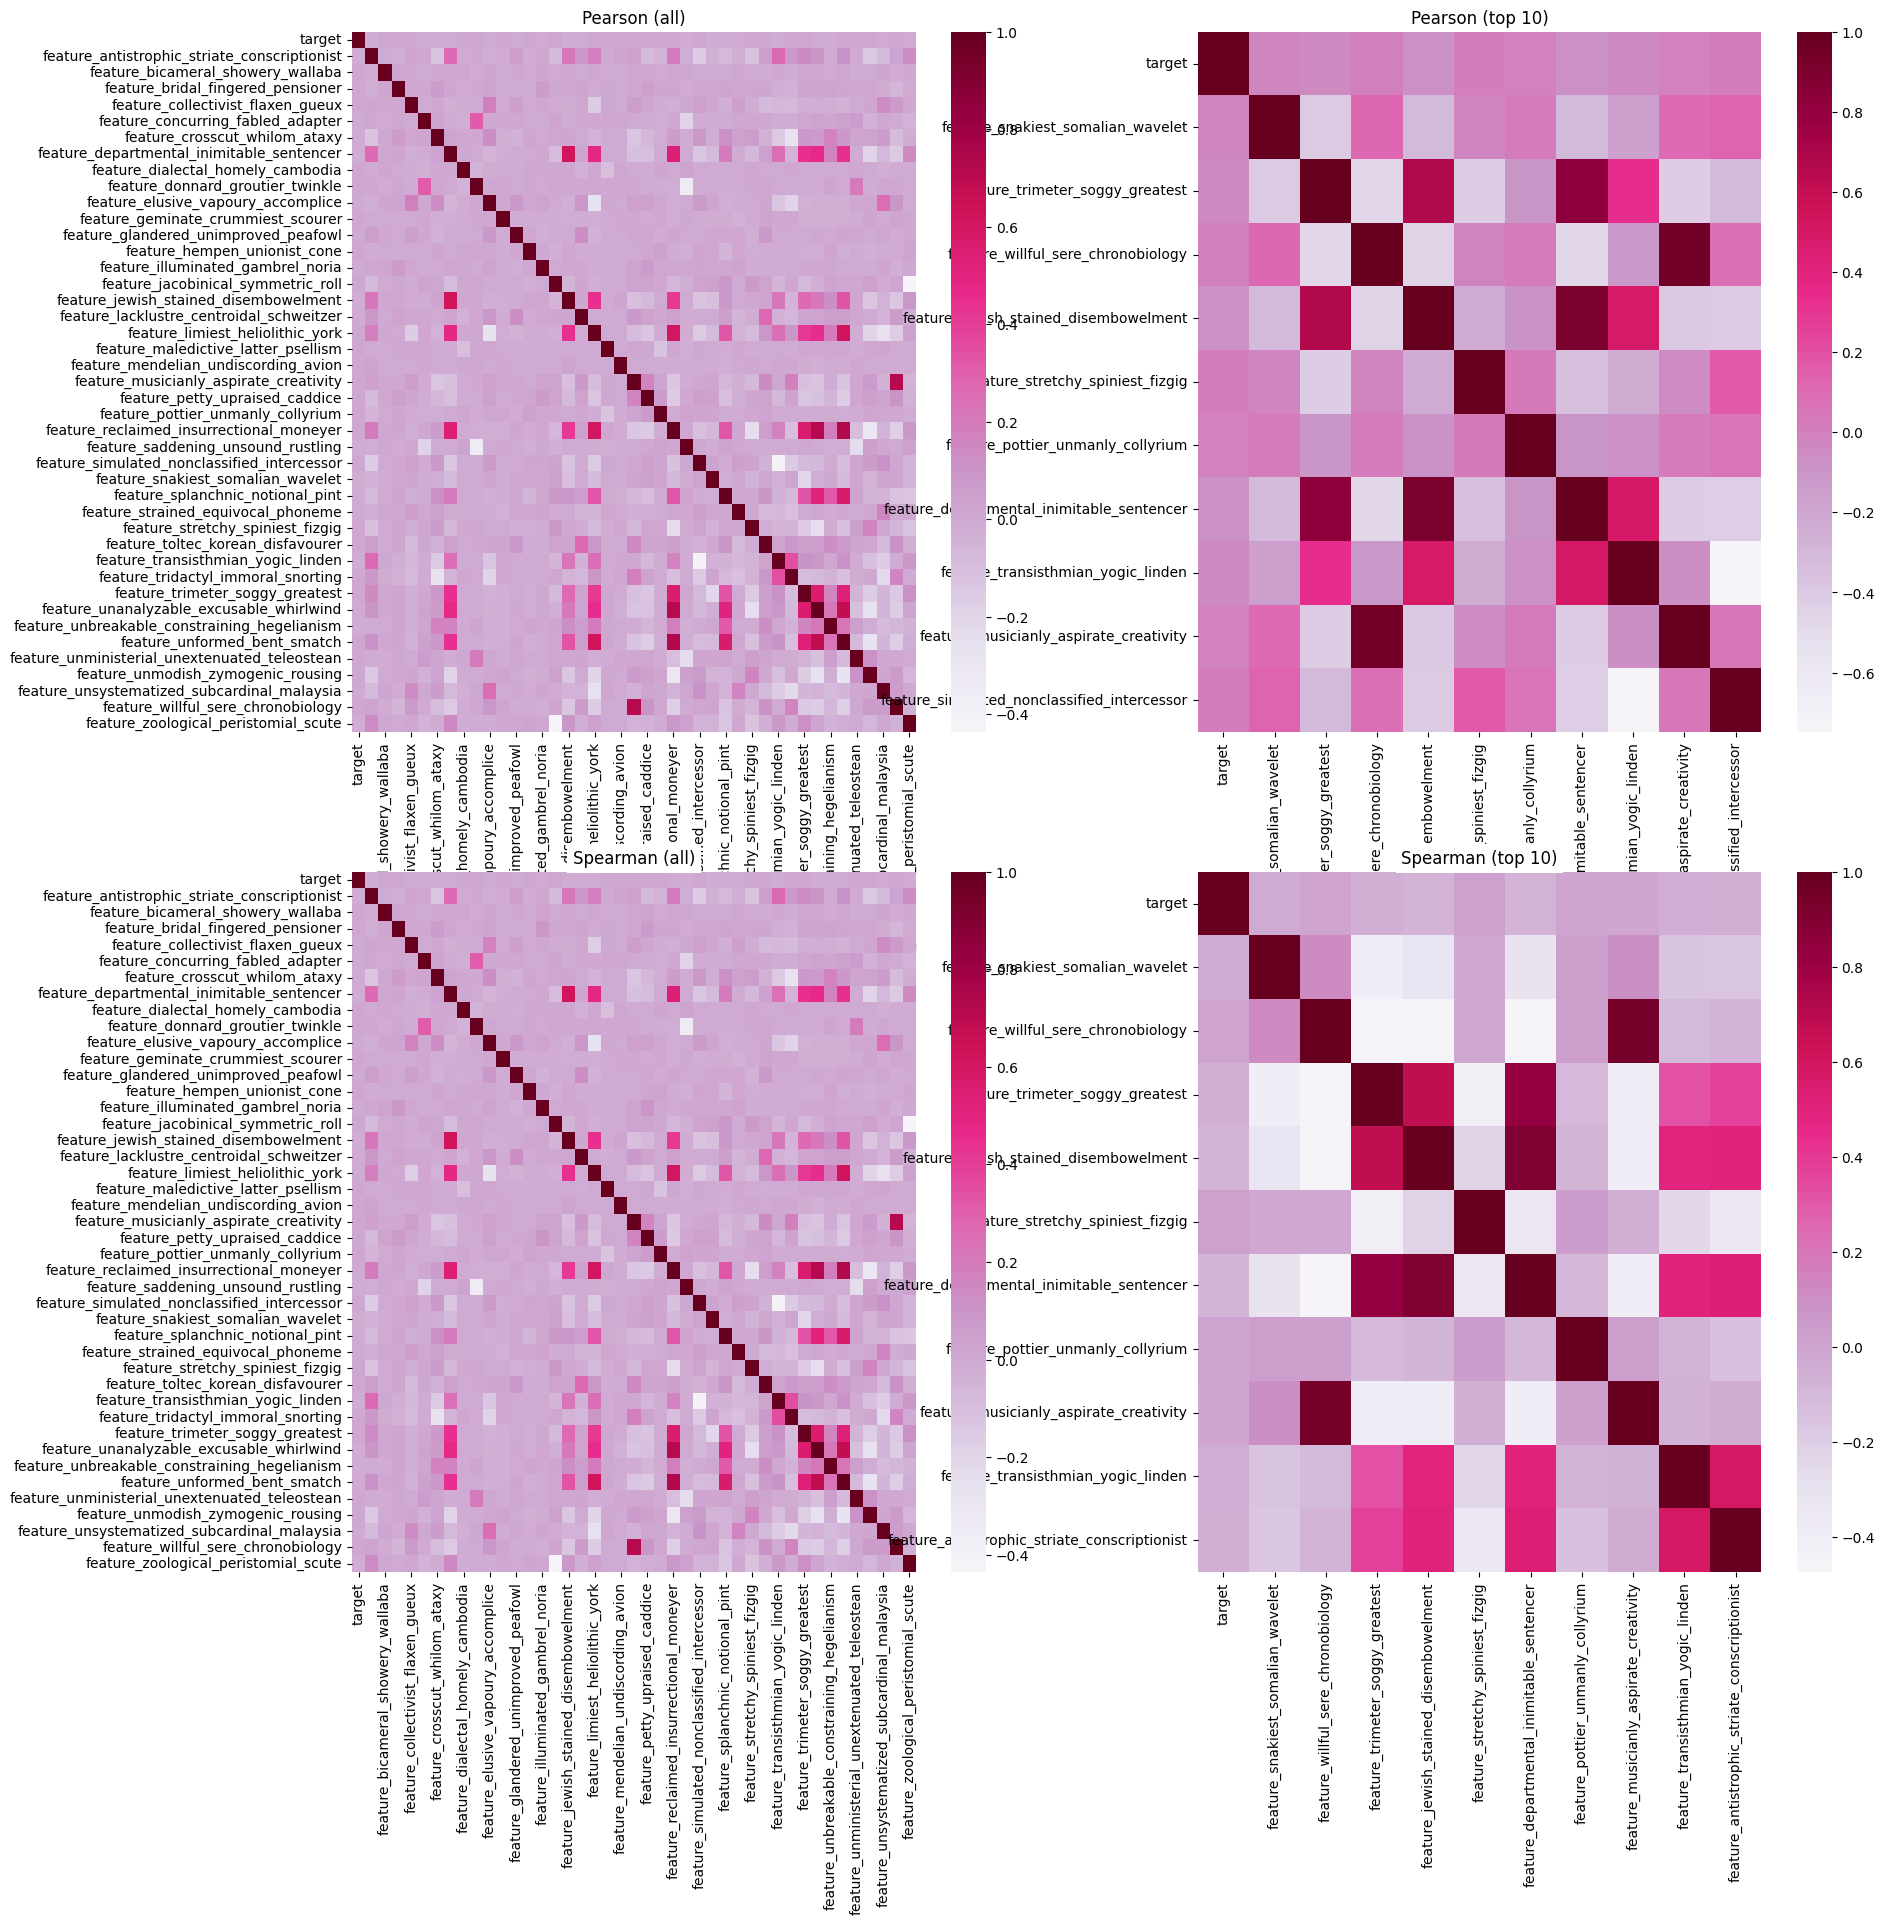

In [5]:
corr = train.corr(numeric_only=True)
top_features = corr["target"].abs().sort_values(ascending=False).head(11).index.to_list()
h_corr = corr[top_features].corr(numeric_only=True)

fig, axs = plt.subplots(2,2, figsize=(20, 20))
cmap = sns.color_palette("PuRd", as_cmap=True)
sns.heatmap(corr, cmap=cmap, ax=axs[0, 0])
axs[0, 0].set_title('Pearson (all)')
sns.heatmap(h_corr, cmap=cmap, ax=axs[0, 1])
axs[0, 1].set_title('Pearson (top 10)')

corr2 = train.corr(numeric_only=True, method='spearman')
top_features2 = corr2["target"].abs().sort_values(ascending=False).head(11).index.to_list()
h_corr2 = corr2[top_features2].corr(numeric_only=True)

cmap = sns.color_palette("PuRd", as_cmap=True)
sns.heatmap(corr2, cmap=cmap, ax=axs[1, 0])
axs[1, 0].set_title('Spearman (all)', bbox=dict(facecolor='white', alpha=1, edgecolor='none'))
sns.heatmap(h_corr2, cmap=cmap, ax=axs[1, 1])
axs[1, 1].set_title('Spearman (top 10)', bbox=dict(facecolor='white', alpha=1, edgecolor='none'))

1.2.2 Distribución de features por target  

Ambos pie charts siguen la misma estructura: la parte del centro muestra la distribución de target en el dataset, y la parte exterior muestra cómo se distribuye los valores de los features de todas las características por cada valor de target.  

La distribución de target muestra un desbalance hacia la clase central 0.5.  

En cuanto a la distribución de valores ordinales de las features, podemos ver que está bastante balanceado dentro de cada clase de target. Aunque en el pie de la izquierda, que considera todas las características, podemos ver que hay una pequeña preferencia hacia los feature etiquetados como 2. Y en el pie de la derecha, si analizamos únicamente las características más correlacionadas con target, este ligero desbalance hacia la clase 2 prácticamente desaparece.  

En conclusión, el desbalance está en target, no en las features. Las features presentan distribuciones consistentes independientemente de la clase de target.

Text(0.5, 1.0, 'feature class distribution by target (top 10 features).')

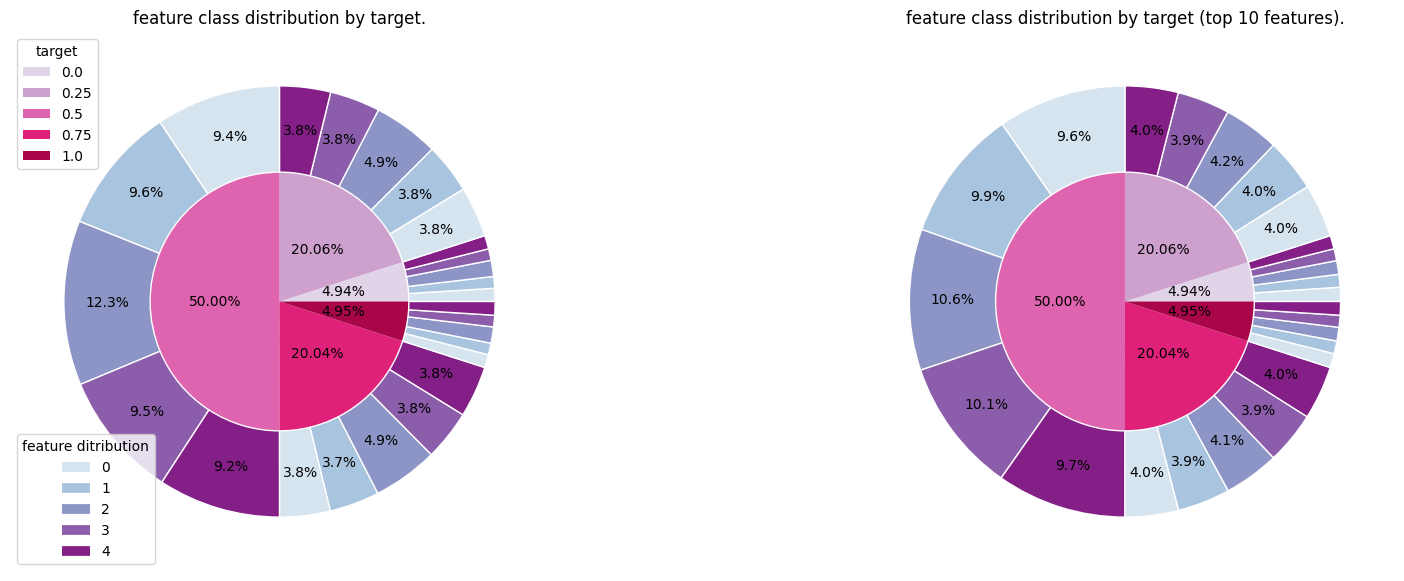

In [6]:
target = train['target'].value_counts().sort_index()

def get_feature_distribution(features):
    return (
        train.groupby('target')[features]
        .apply(lambda d: d.apply(pd.Series.value_counts).sum(axis=1))
        .to_dict(orient='index')
    )

def autopct_threshold(pct, threshold=3):
    return f'{pct:.1f}%' if pct >= threshold else ''


fig, axs = plt.subplots(1,2, figsize=(20,7))
colors = sns.color_palette("BuPu", 5)

labels = [v for d in get_feature_distribution(feature_set).values() for v in d.values()]
axs[0].pie(target, autopct='%1.2f%%', pctdistance=0.30, colors=sns.color_palette("PuRd", 5))
axs[0].pie(labels, autopct=lambda pct: autopct_threshold(pct), 
           pctdistance=0.80, wedgeprops=dict(width=0.4, edgecolor='w'), 
           colors=colors*5)

axs[0].add_artist(axs[0].legend(target.index, loc='upper left', title='target'))
legend = [plt.Line2D([0], [0], linestyle="-", solid_capstyle='butt', color=colors[i % len(colors)], lw=7) for i in range(5)]
axs[0].legend(legend, [0, 1, 2, 3, 4], title="feature ditribution", loc='lower left')
axs[0].set_title('feature class distribution by target.')

labels = [v for d in get_feature_distribution(top_features[1:]).values() for v in d.values()]
axs[1].pie(target, autopct='%1.2f%%', pctdistance=0.30, colors=sns.color_palette("PuRd", 5))
axs[1].pie(labels, autopct=lambda pct: autopct_threshold(pct), 
           pctdistance=0.80, wedgeprops=dict(width=0.4, edgecolor='w'), 
           colors=colors*5)
axs[1].set_title('feature class distribution by target (top 10 features).')

1.2.3 Distribución por era  

A continuación se muestran varias gráficas de distribución de distintos datos según Eras.  
En el primer gráfico, podemos observar la cantidad de mercados disponibles (o al menos de los que hay datos) por era, con un mínimo en la era 1 (aprox 2200) y un máximo al rededor de la era 240 (aprox 6000). A partir de más o menos la era 70, la cantidad de mercados se mantiene entre 4000 y 6000.  

A la derecha podemos ver la media de target a través de las distintas eras. Aunque visualmente parece haber fluctuación, el rango de variación es extremadamente reducido: únicamente oscila entre 0.49 y 0.51. Teniendo en cuenta que la clase 0.5 predomina con una mayoría del 50% en el dataset, estas pequeñas variaciones son esperables y no indican cambios sustanciales en las condiciones de mercado o regímenes económicos.  

Finalmente, en la parte inferior vemos una distribución más detallada del target por los distintos eras. Como es de esperar, la mediana está siempre en la clase 0.5. En algunas eras, incluso todo el IQR se encuentra en el valor de 0.5, teniendo todas las demás clases como outliers. Hay otras eras, en cambio, que siguen una distribución más equilibrada, con el IQR entre 0.25 y 0.75. Lo que sí podemos concluir es que en todas las eras existen valores de todas las clases de target, y no podemos concluir mucho más de su distribución a parte de que casi todas se concentran en la clase 0.5.  

Como conclusión, este dataset no presenta mucha variabilidad temporal, más bien es prácticamente nula. La mediana constante en 0.5 refuerza la estacionariedad. Ésta poca variación temporal sugiere que los modelos deberán poder generalizar bien a otros períodos, sin necesidad de ajustes específicos por régimen de mercado. La presencia de todas las clases en todas las eras indica que el problema de clasificación se mantiene factible a lo largo del tiempo.

2025-11-04 11:15:12,763 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:12,763 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:12,839 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:12,839 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:12,839 INFO matplotlib.

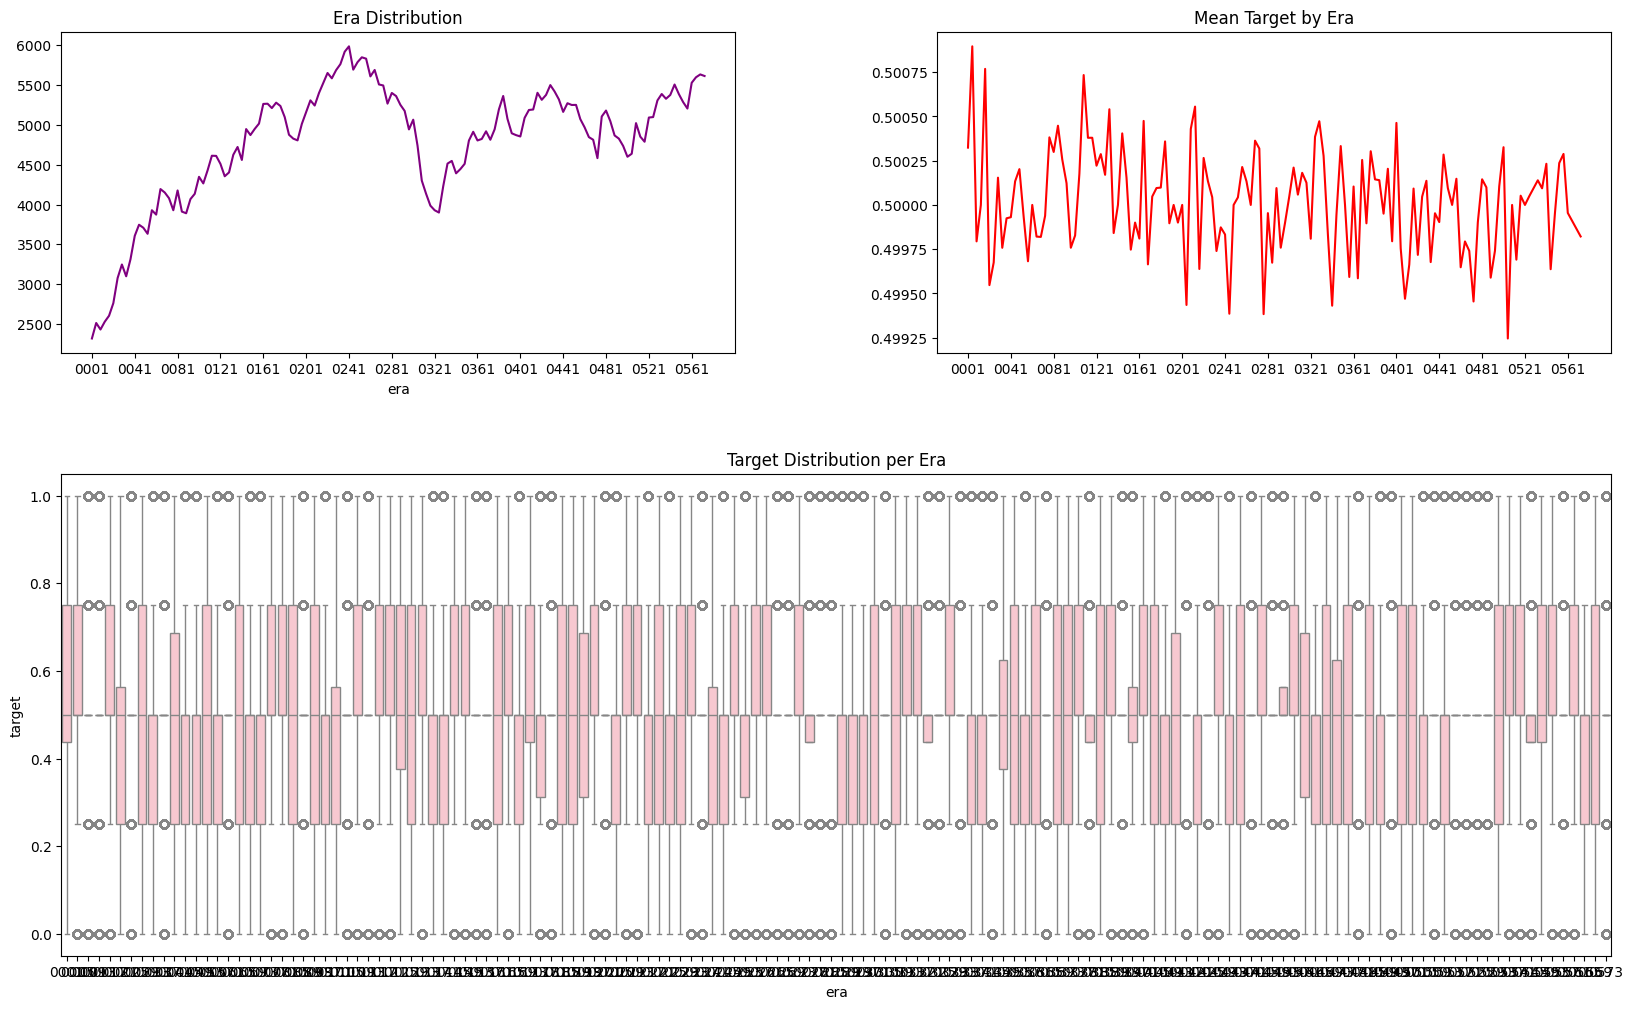

In [7]:
count = train["era"].value_counts().sort_index()
stat = train.groupby('era')['target'].agg(['mean']).reset_index()

# Create GridSpec layout
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.5], hspace=0.3, wspace=0.3)

# Top left: era distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(x=count.index, y=count.values, ax=ax1, color='purple')
ax1.set_title('Era Distribution')
ax1.set_xticks(count.index[::10])

# Top right: mean target by era
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(stat['era'], stat['mean'], color='red')
ax2.set_title('Mean Target by Era')
ax2.set_xticks(count.index[::10])

# Bottom: boxplot spanning both columns
ax3 = fig.add_subplot(gs[1, :])  
sns.boxplot(x='era', y='target', data=train, ax=ax3, color='pink')
ax3.set_title('Target Distribution per Era')

plt.show()

1.2.4 Era specificity  

> Era specificity mide la relación que hay entre las features a través de las eras. Si el valor es alto, indica que según la era, el valor de las features puede cambiar considerablemente (lo que puede significa que si entrenas muy bien con unas eras, no tiene por qué predecirte bien si se usan otras eras -> se ve como overfitting), en cambio un era specificity bajo indica que los datos no son dependientes de las eras (por lo que probablemente sea más consistente).  

En nuestros datos, podemos observar que hay una era specificity extremadamente baja, lo cual es lógico ya que los datos nos llegan ya preprocesados en valores discretos de 0-4, cada uno representando estadísticas rankeadas (probablemente percentiles, cuartiles...) y estén diseñadas para que tenga la misma distribución a través de las eras.  

Existe una única feature cuyo valor de era specificity destaca ligeramente sobre el resto, sin embargo, su magnitud sigue siendo muy pequeña, por lo que su impacto global es insignificante. Este pequeño desvío probablemente se deba a ruido estadístico o a una normalización imperfecta.

En conclusión, nuestro dataset muestra una estabilidad temporal muy alta, sin indicios de overfitting entre eras. Esto sugiere que el modelo debería mantener un rendimiento consistente incluso en eras completamente nuevas, como las que conforman el conjunto de validación.

2025-11-04 11:15:17,238 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:17,238 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:17,277 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:17,277 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:17,311 INFO matplotlib.

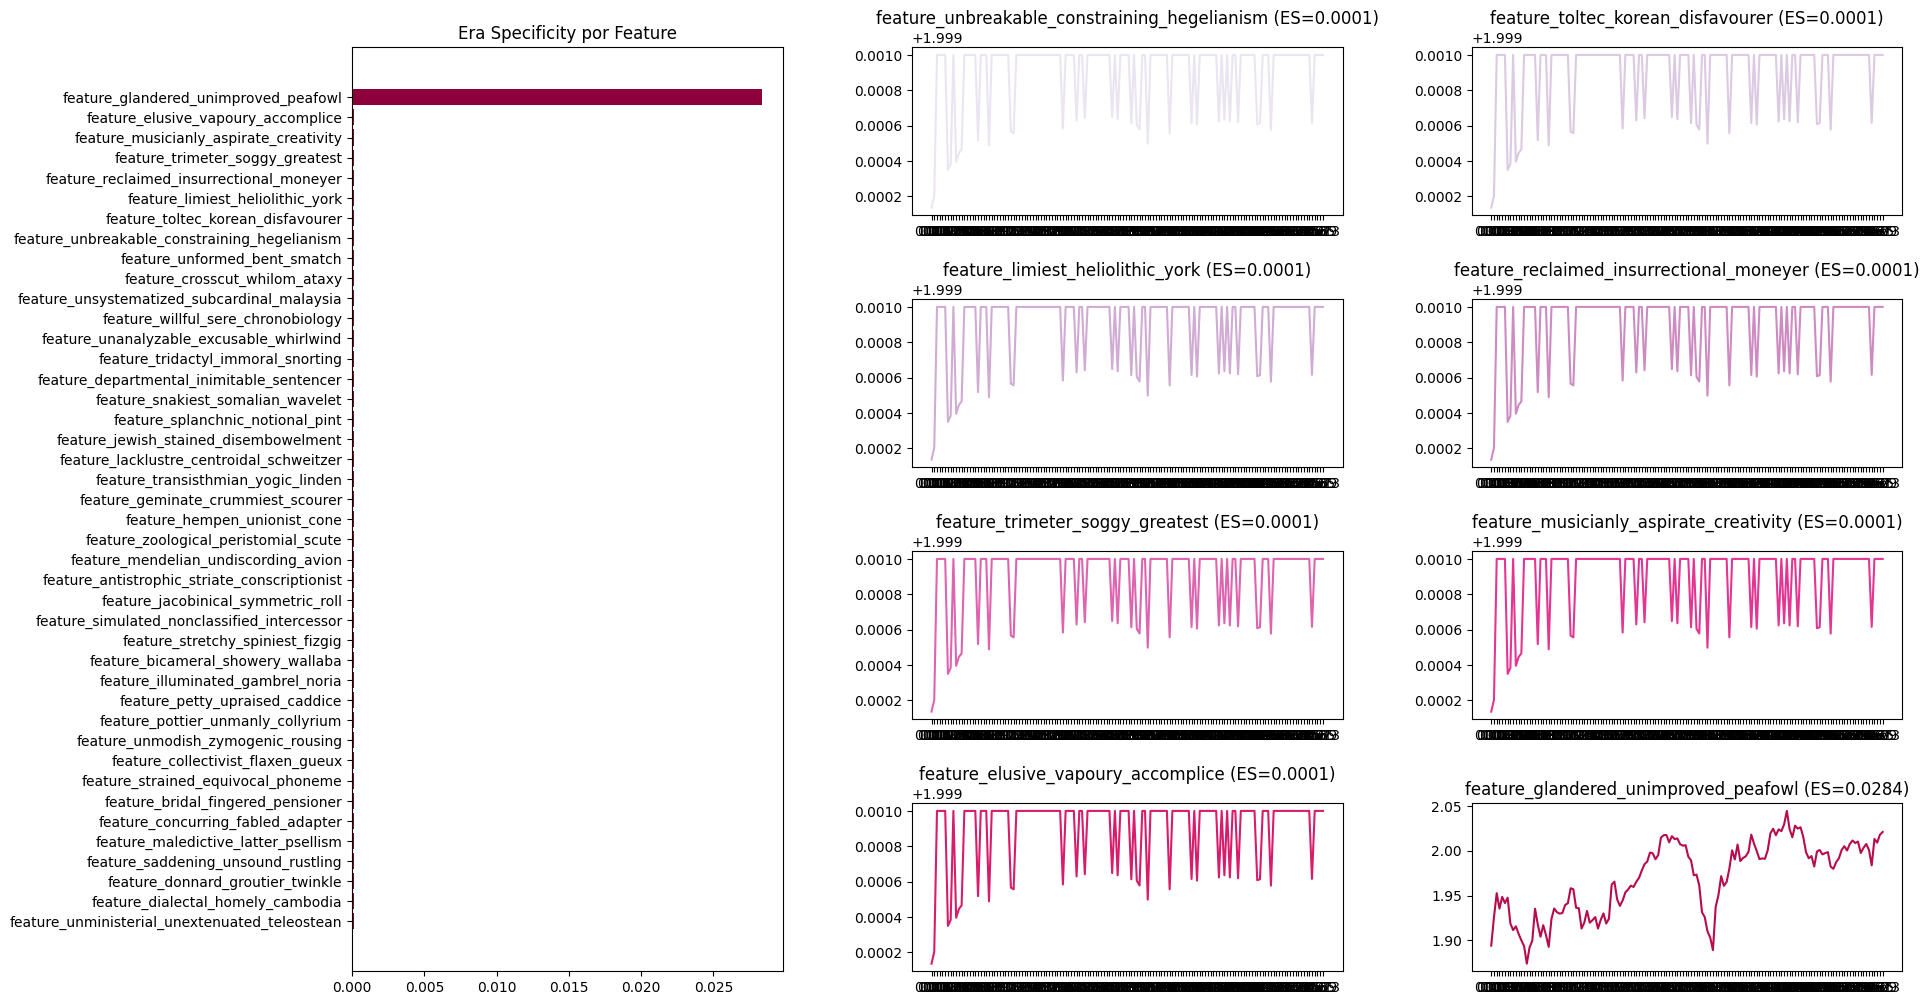

In [8]:
era_specificity = {}

for col in feature_set:
    era_variance = train.groupby('era')[col].mean().std()
    overall_variance = train[col].std()
    era_specificity[col] = era_variance / overall_variance

# Convertir a DataFrame
era_spec_df = pd.DataFrame.from_dict(era_specificity, orient='index', columns=['era_specificity'])
era_spec_df = era_spec_df.sort_values('era_specificity', ascending=True)

# Gráfico
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(4, 3, hspace=0.5, wspace=0.3)
colors = sns.color_palette("PuRd", 9)

ax1 = fig.add_subplot(gs[:, 0])
ax1.barh(era_spec_df.index, era_spec_df['era_specificity'], color=colors[8])
ax1.set_title('Era Specificity por Feature')

top_features = era_spec_df.tail(8).index.tolist()
for i, feature in enumerate(top_features):
    ax = fig.add_subplot(gs[i // 2, i % 2 + 1])
    era_means = train.groupby('era')[feature].mean()
    ax.plot(era_means.index, era_means.values, color=colors[i])
    ax.set_title(f"{feature} (ES={era_specificity[feature]:.4f})")


#### 1.3 Técnicas de preprocesamiento

1.3.1 Resample  

Se prepara un dataset con la clase 0.5 reducido al 80% de los datos originales, y las clases 0.0 y 1.0 incrementadas un 10% mediante replicación, para que la distribución sea más balanceada, por ende, que haya menos sesgo hacia 0.5, y un poquito más de sensibilidad hacia 0.0 y 1.0.  

Es muy importante tener en cuenta que:
- oversampling -> Riesgo de memorización sin aportar información nueva real (posible overfitting)  
- undersampling -> pérdida de datos  
- Distribución real -> Los modelos deben validarse con la distribución que encontrarán en producción.  

Por ello se intenta rebalancear lo más sutil posible, sin distorsionar excesivamente la distribución natural de los datos.

2025-11-04 11:15:21,318 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 11:15:21,325 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='target', ylabel='count'>

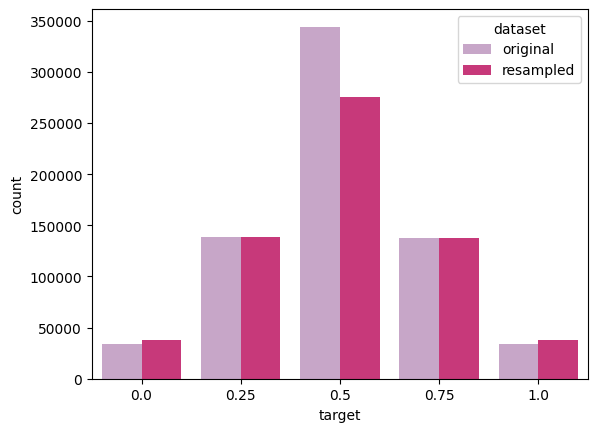

In [9]:
# se reduce la clase 0.5 a la mitad, y se duplica los de la clase 0 y 1
def resample(df):
    train_resampled = df.copy()
    train_resampled = pd.concat([train_resampled[train_resampled["target"] != 0.5], train_resampled[train_resampled["target"] == 0.5].sample(frac=0.8, random_state=42)])
    train_resampled = pd.concat([train_resampled[train_resampled["target"] != 0.0], train_resampled[train_resampled["target"] == 0.0].sample(frac=1.1, replace=True, random_state=42)])
    train_resampled = pd.concat([train_resampled[train_resampled["target"] != 1.0], train_resampled[train_resampled["target"] == 1.0].sample(frac=1.1, replace=True, random_state=42)])
    train_resampled = train_resampled.sample(frac=1, random_state=42).reset_index(drop=True)
    return train_resampled
"""
No se ha usado el undersampling y oversamplig de imblearn, porque no aceptan int o floats como clases, así que habría que pasar las y a str y luego volverlos a pasar a float. 
(Ese proceso tardaba mucho.)
"""
train_resampled = resample(train)
# Mostrar gráfica de distribución comparativa con las muestras originales
df_compare = pd.DataFrame({
    "target": train_resampled["target"].value_counts().sort_index().index,
    "original": train["target"].value_counts().sort_index(),
    "resampled": train_resampled["target"].value_counts().sort_index()
}).melt(id_vars="target", var_name="dataset", value_name="count")

sns.barplot(data=df_compare, x="target", y="count", hue="dataset", palette="PuRd")

1.3.2 PCA  

Se explora la aplicación de reducción de dimensionalidad con PCA, en el siguiente ejemplo se reduce para conservar el 98% de la varianza del dataset, resultando en 39 componentes.  

Mediante el pairplot generado, podemos observar no existen agrupaciones ni patrones claros en una dimensionalidad reducida. (Además, en las curvas KDE se vuelve a ver claramente el desbalance de ejemplos entre las clases de target.) Esta uniformidad en los scatter plots indica que las direcciones de máxima varianza no corresponden a diferencias significativas entre las clases objetivo. Y esto se puede deber a:  
- Que la relación entre las features y target no sea lineal (cosa que ya se pudo comprobar en la matriz de correlación Pearson)  
- O que, como suele pasar en datasets financieros, que las relaciones sean más estadísticas que geométricas.  
- También puede ser por que las features ya están prepocesadas (transformadas en valores de 0-4), habiendo perdido así información continua que PCA podría aprovechar.  

Sabiendo esto, podemos pensar que la reducción de la dimensionalidad en este dataset, a no ser que se utilice algún modelo en específico que trabaje mejor con dimensionalidades reducidas (como los modelos lineales), no aporta ningún beneficio realizar PCA. Sobretodo en modelos como Random Forest y otros que se verán más adelante, que ya manejan altas dimensionalidades sin problema, este paso se puede obviar.

Número de componentes tras PCA: 39


'\nSolo voy a mostrar 5 de los componentes porque son todas iguales. Y utiliza sample para que no tarde mucho de calcular.\n'

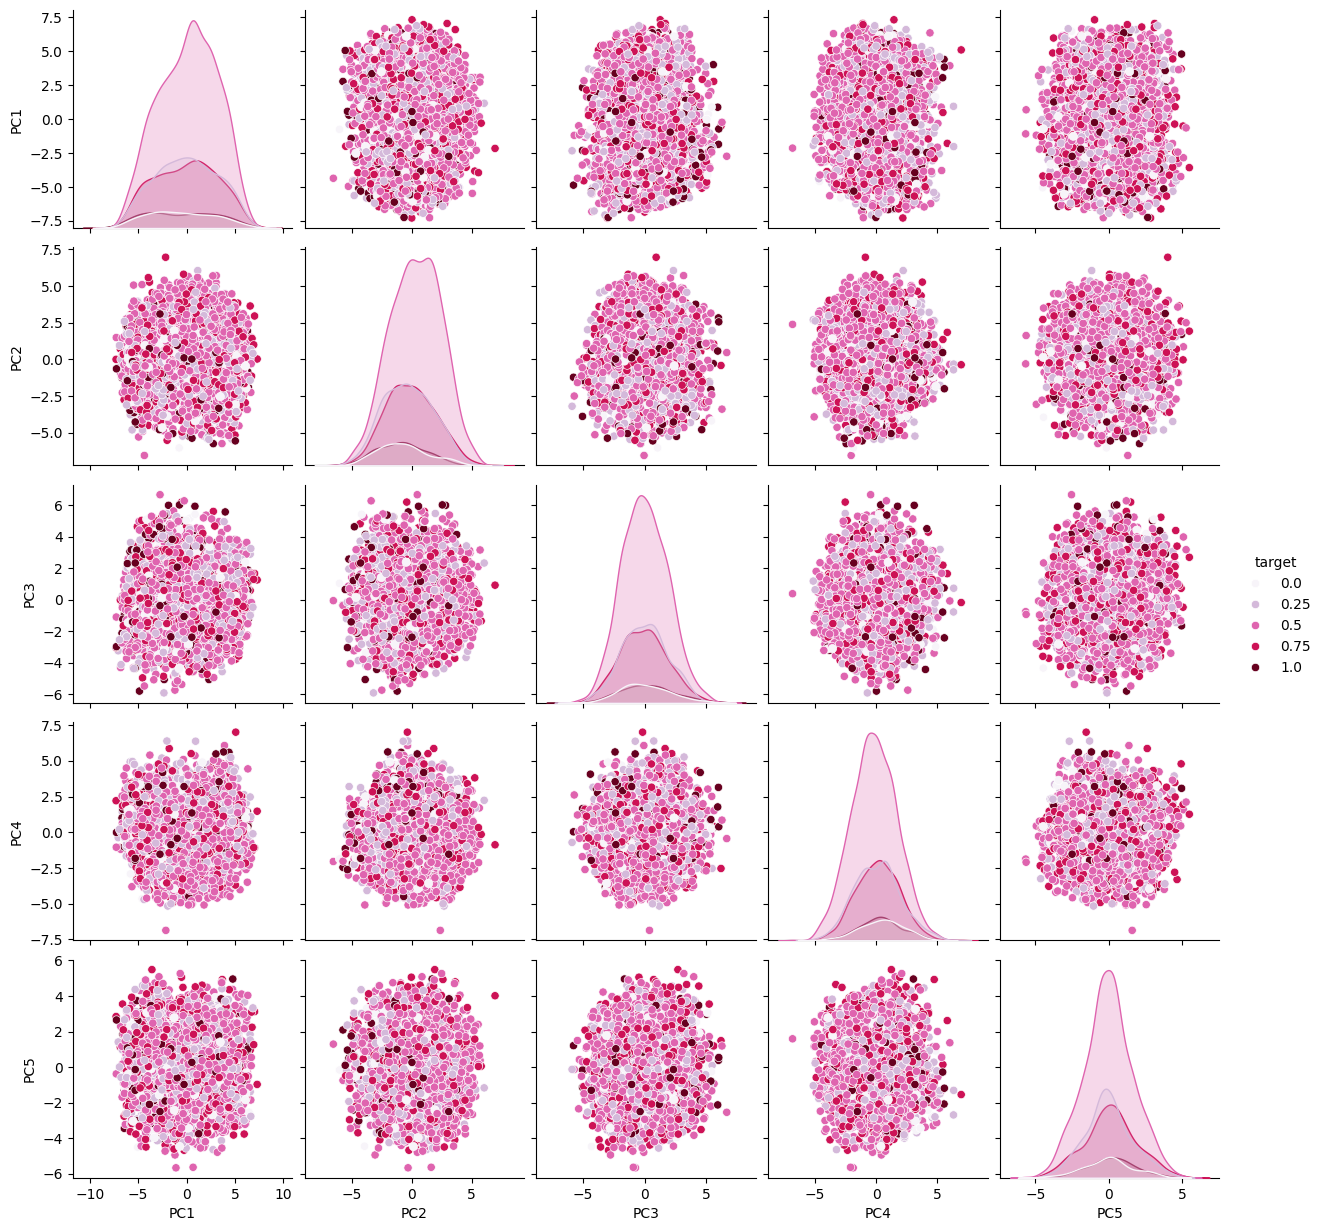

In [10]:
def apply_pca(components, train_set, test_set, val_set):
    pca = PCA(n_components=components)
    X_pca = pca.fit_transform(train_set)
    X_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

    X_test_pca = pca.transform(test_set)
    X_test_pca = pd.DataFrame(X_test_pca, columns=[f"PC{i+1}" for i in range(X_test_pca.shape[1])])

    X_val_pca = pca.transform(val_set)
    X_val_pca = pd.DataFrame(X_val_pca, columns=[f"PC{i+1}" for i in range(X_val_pca.shape[1])])

    print("Número de componentes tras PCA:", pca.n_components_)
    return X_pca, X_test_pca, X_val_pca

sample = train.sample(5000, random_state=42)

sample_pca, _, _ = apply_pca(0.98, sample[feature_set], sample[feature_set], validation[feature_set])

sample_pca["target"] = sample["target"].values
sns.pairplot(sample_pca, vars=[f'PC{i+1}' for i in range(5)], hue='target', palette='PuRd', diag_kind='kde', corner=False)
"""
Solo voy a mostrar 5 de los componentes porque son todas iguales. Y utiliza sample para que no tarde mucho de calcular.
"""


1.3.3 Estandarización  

> La estandarización consiste en reescalar las variables numéricas para que todas tengan una media de 0 y desviación estándar de 1. De esta manera, se consigue que todos los valores se encuentren dentro de una misma escala, y por ello, que ciertos procesos no den mayor peso a ciertas variables únicamente por estar a una escala más grande.  
> 
> Pero otro factor a considerar es el tipo de modelo a entrenar:   
> - Modelos lineales:  En este tipo de modelo, es importante que todos los valores estén a una misma escala para que los valores grandes no dominen la magnitud de los coeficientes.  
> - Modelos sensibles a distancias: Similar a los modelos lineales, cuanto mayor sea la escala, más dominará la distancia total, haciendo que otras variables sean ignoradas.  
> - Modelos basados en árboles: Generalmente no se usa ya que los árboles se basan en división por umbrales, no es distancias ni pesos.  

En el caso que tenemos presente, ya que todas las features del dataset se encuantran discretizadas en el mismo rango de valores enteros entre el 0 y el 4, están en una escala común y comparable. Por ello, generalmente no sería necesario ningún tipo de estandarización adicional. 

No obstante, se prepara para realizarse pruebas sobre modelos que son más sensibles a las distancias (por ejemplo K-NN), o que podrían sesgarse por la magnitud (Regresión lineal).  

Entonces, porqué se decide usar Standard Scaler, y no otros tipos de normalización/estandarización como MinMaxScaler o RobustScaler?  

|Tipo de escalado | Efecto sobre este dataset |   
|-|-|   
|Standard Scaler|Centra las variables en 0 y establece desviación estándar de 1. Aunque no es estrictamente necesario reescalar, el centrado puede mejorar la estabilidad numérica en modelos lineales con regularización como Ridge y facilitar la convergencia en algoritmos de optimización | 
|Min Max Scaler| LLevaría los valores de 0-4 -> 0-1. El resultado sería idéntico en comportamiento relativo, únicamente cambiaría la magnitud|  
|Robust Scaler|No aporta nada ya que no hay outliers|  

Por ello se concluye que Standard Scaler es la única que podría aportar valor marginal (estabilidad numérica y centrado en 0) para ciertos modelos lineales que se evaluarán más adelante, aunque el impacto será mínimo dado que las features ya están en una escala uniforme.

In [11]:
def standarize(X_train, X_test, X_val):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)
    return (
        pd.DataFrame(X_train_scaled, columns=X_train.columns),
        pd.DataFrame(X_test_scaled, columns=X_test.columns),
        pd.DataFrame(X_val_scaled, columns=X_val.columns)
    )

### 2. MODELING

#### 2.1 División del conjunto de datos

Se planea dividir el conjunto de datos de dos maneras distintas:  
- Random split: Dividir train en train_df y test_df, siendo test_df el 20% de los datos. Además, se aplica stratify al objetivo 'target' para que mantenga la proporcionalidad de las clases. Se le llama random ya que no tiene en cuenta las eras a la hora de dividirse, por lo que hay solapación de eras en train y test. (En validación no ya que el conjunto que se nos proporciona ya viene con eras distintas)  
- Era split: Divide el conjunto en train y test, teniendo en cuenta las eras, de manera que no exista solapación entre ellas. En este caso, se divide en 70% train - 30% test debido a que al dividirse por eras, si test tan solo tuviera un 20% de eras, el conjunto de test puede volverse demasiado pequeño o concentrarse en pocos contextos, dificultando una evaluación representativa del rendimiento fuera de sample. Adicionalmente, se deja un gap temporal entre los conjuntos para evitar el data leakage (ya que el target indica el valor a 4 eras a futuro).  

No se requiere crear un conjunto de test adicional ya que se proporciona un conjunto de validación adicional con eras completamente distintas a las del entrenamiento, que actuará como test final para medir el rendimiento real del modelo en producción.

In [12]:
def random_split(df):
    train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["target"], random_state=32)
    return train_df, test_df

def era_split(df):
    # Obtener eras únicas
    all_eras = sorted(df['era'].unique())
    
    # Definir tamaños
    n_train = int(len(all_eras) * 0.7)
    n_test = int(len(all_eras) * 0.3)
    train_eras = all_eras[:n_train - 4] # se resta 4 para que tenga un gap de eras -> evitar data leakage
    test_eras = all_eras[n_train:n_train + n_test - 4]
    
    # Crear datasets
    train_df = df[df['era'].isin(train_eras)].copy()
    test_df = df[df['era'].isin(test_eras)].copy()
    return train_df, test_df

train_df, test_df = random_split(train)
train_df_era, test_df_era = era_split(train)

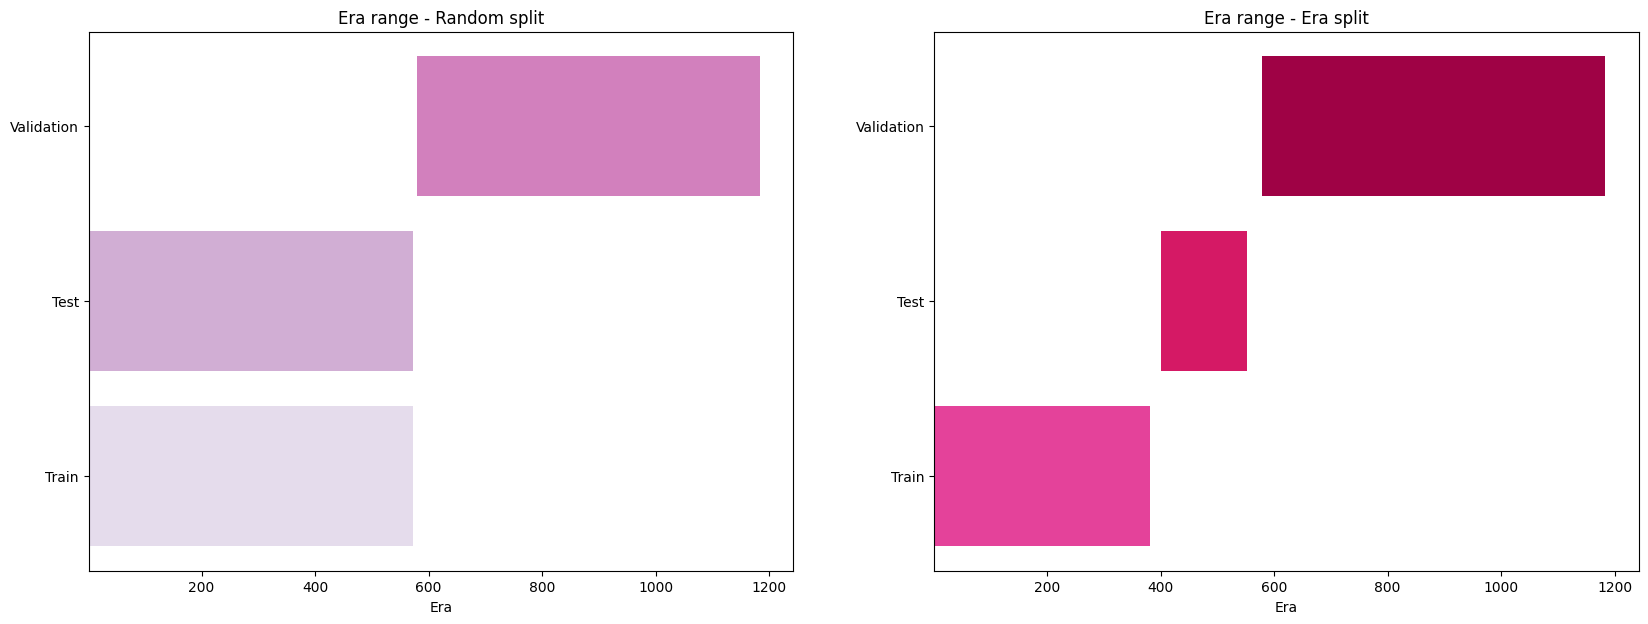

In [13]:
#Visualización de las eras que abarca cada conjunto de datos según el tipo de división
# Función para obtener el inicio y fin de cada set
def era_range(eras):
    return int(eras[0]), int(eras[-1])

# Crear figura
fig, axs = plt.subplots(1,2, figsize=(20,7))
colors = sns.color_palette("PuRd", 6)

# Graficar barras random split
train_start, train_end = era_range(sorted(train_df['era'].unique()))
test_start, test_end = era_range(sorted(test_df['era'].unique()))
val_start, val_end = era_range(sorted(validation['era'].unique()))

axs[0].barh('Train', train_end - train_start, left=train_start, color=colors[0])
axs[0].barh('Test', test_end - test_start, left=test_start, color=colors[1])
axs[0].barh('Validation', val_end - val_start, left=val_start, color=colors[2])
axs[0].set_xlabel('Era')
axs[0].set_title('Era range - Random split')
axs[0].set_yticks(['Train', 'Test', 'Validation'])

# Graficar barras era split
train_start, train_end = era_range(sorted(train_df_era['era'].unique()))
test_start, test_end = era_range(sorted(test_df_era['era'].unique()))
val_start, val_end = era_range(sorted(validation['era'].unique()))

axs[1].barh('Train', train_end - train_start, left=train_start, color=colors[3])
axs[1].barh('Test', test_end - test_start, left=test_start, color=colors[4])
axs[1].barh('Validation', val_end - val_start, left=val_start, color=colors[5])
axs[1].set_xlabel('Era')
axs[1].set_title('Era range - Era split')
axs[1].set_yticks(['Train', 'Test', 'Validation'])

#### 2.2 Pruebas sobre métodos de preprocesamiento sobre Linear Regression

2.2.1 Linear Regression - Baseline  

A pesar de ser eficiente computacionalmente, Linear Regression no obtiene buenos resultados en este dataset. Como se observó en la matriz de correlación de Pearson, las features no mantienen relaciones lineales significativas con el target.

Regresión Lineal sirve como baseline inferior, confirmando que el problema requiere modelos capaces de capturar relaciones no lineales complejas. Estos resultados establecen el umbral mínimo a superar.

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2057142829.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2057142829.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], 

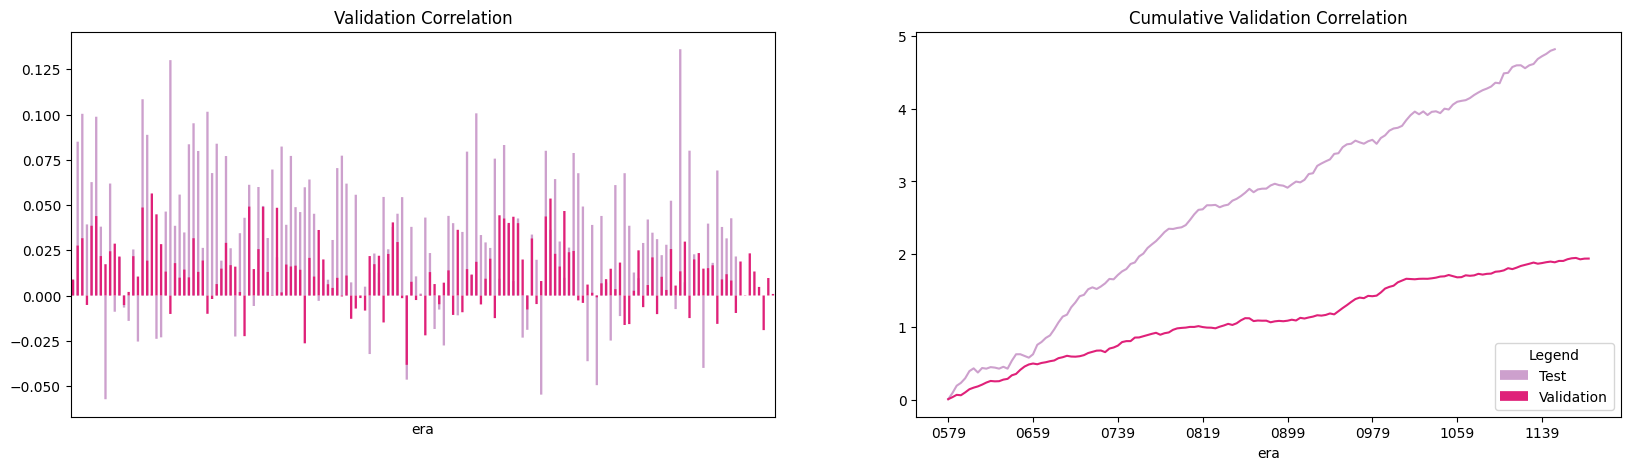

,lr_baseline_test,lr_baseline_val
mean,0.033443,0.012764
std,0.037634,0.017708
sharpe,0.888620,0.720837
max_drawdown,0.057309,0.056305


In [14]:
lr = LinearRegression()
lr.fit(train_df[feature_set], train_df["target"])

test_df["prediction"] = lr.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_baseline_test", per_era_corr_test)

validation["prediction"] = lr.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_baseline_val", per_era_corr_val, df_metrics_lr)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_lr

2.2.2 Linear Regression - Estandarizado 

Podemos observar que las métricas obtenidas al estandarizar los datos son idénticas al baseline, por lo que se puede confirmar que la estandarización no cambia el rendimiento en Regresión Lineal, ya que la solución de mínimos cuadrados es invariante a escalado lineal. Los coeficientes se ajustan proporcionalmente a la escala de las features, resultando en predicciones equivalentes.

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\648881564.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\648881564.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x

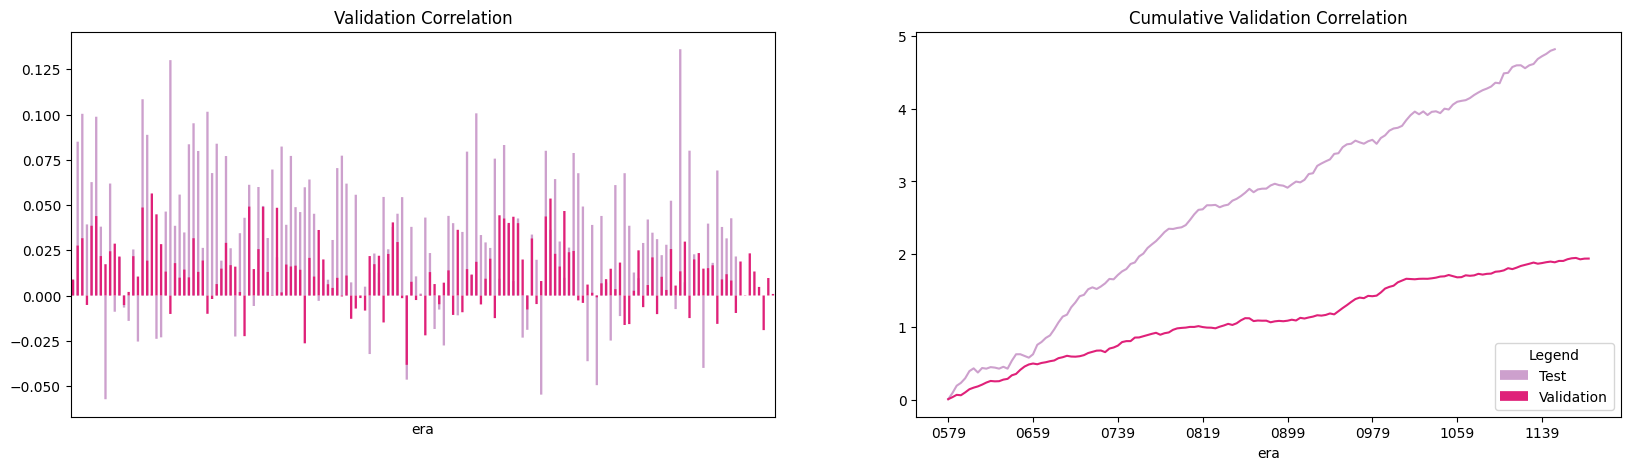

,lr_baseline_test,lr_baseline_val,lr_scaled_test,lr_scaled_val
mean,0.033443,0.012764,0.033443,0.012764
std,0.037634,0.017708,0.037634,0.017708
sharpe,0.888620,0.720837,0.888620,0.720837
max_drawdown,0.057309,0.056305,0.057309,0.056305


In [15]:
X_train, X_test, X_val = standarize(train_df[feature_set], test_df[feature_set], validation[feature_set])

lr.fit(X_train, train_df["target"])

test_df["prediction"] = lr.predict(X_test)
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_scaled_test", per_era_corr_test, df_metrics_lr)

validation["prediction"] = lr.predict(X_val)
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_scaled_val", per_era_corr_val, df_metrics_lr)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_lr

2.2.3 Linear Regression - PCA 

El resultado similar confirma que las direcciones de máxima varianza (capturadas por PCA) no corresponden a las direcciones relevantes para predecir el target.

Número de componentes tras PCA: 41


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2407944979.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2407944979.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"],

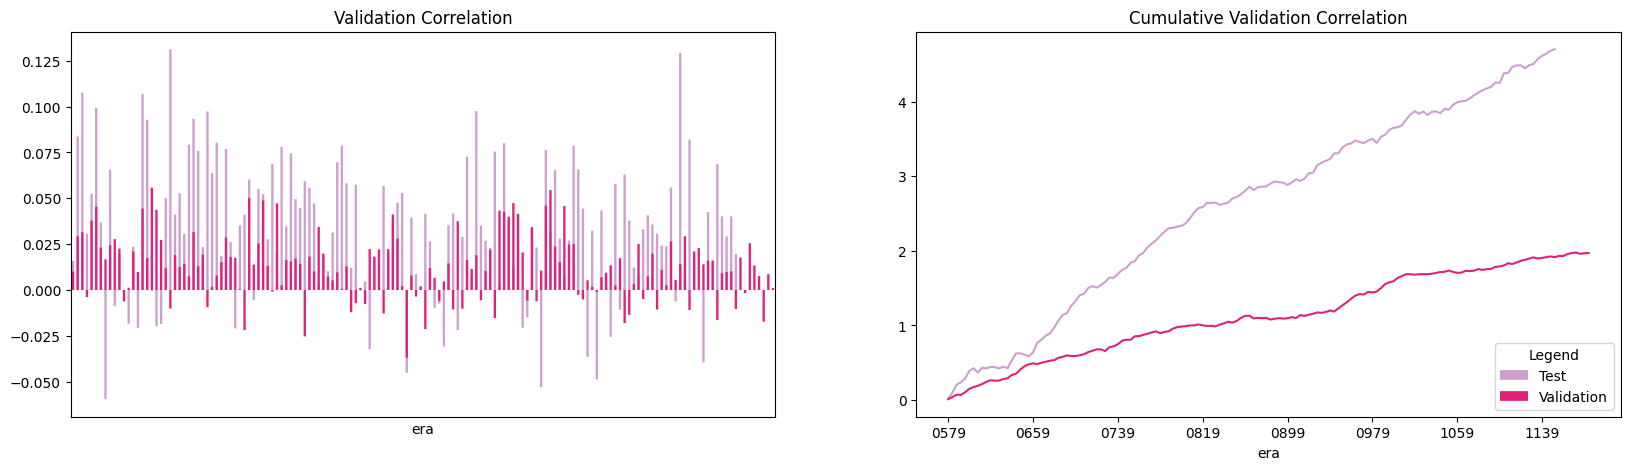

,lr_baseline_test,lr_baseline_val,lr_scaled_test,lr_scaled_val,lr_pca_test,lr_pca_val
mean,0.033443,0.012764,0.033443,0.012764,0.032680,0.012965
std,0.037634,0.017708,0.037634,0.017708,0.036907,0.017613
sharpe,0.888620,0.720837,0.888620,0.720837,0.885476,0.736143
max_drawdown,0.057309,0.056305,0.057309,0.056305,0.059539,0.051883


In [16]:
X_train, X_test, X_val = apply_pca(0.99, train_df[feature_set], test_df[feature_set], validation[feature_set])

lr.fit(X_train, train_df["target"])

test_df["prediction"] = lr.predict(X_test)
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_pca_test", per_era_corr_test, df_metrics_lr)

validation["prediction"] = lr.predict(X_val)
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_pca_val", per_era_corr_val, df_metrics_lr)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_lr

2.2.4 Linear Regression - Resampled

Al aplicar resampling, disminuye sharpe (un 0.2 en test y un 0.4 en validación), además de que aumenta el max drawdown. Estos deterioros se pueden atribuir a:
- La pérdida de información (undersampling de 0.5)
- El riesgo de overfitting (oversampling de 0.0/1.0)
- La distribución de train diverge de la real en validación

Se concluye que el resampling no aporta beneficio y confirma la decisión de no aplicarlo. Los modelos deben aprender a manejar la distribución natural del problema.

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2680625469.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2680625469.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"],

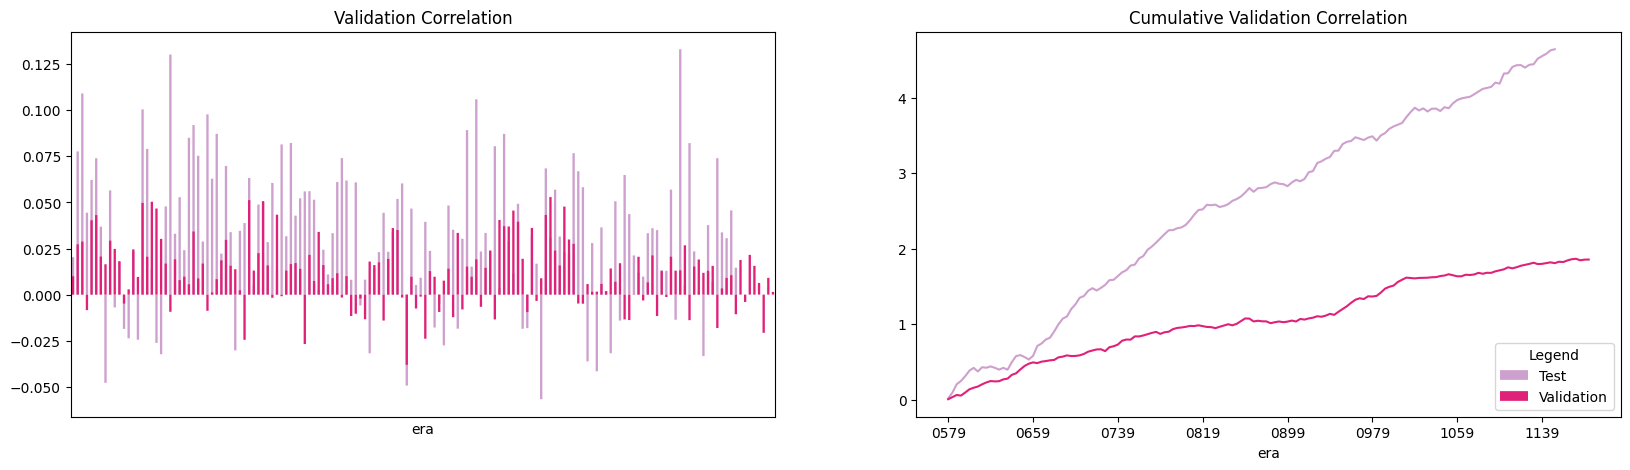

,lr_baseline_test,lr_baseline_val,lr_scaled_test,lr_scaled_val,lr_pca_test,lr_pca_val,lr_resampled_test,lr_resampled_val
mean,0.033443,0.012764,0.033443,0.012764,0.032680,0.012965,0.032217,0.012221
std,0.037634,0.017708,0.037634,0.017708,0.036907,0.017613,0.037188,0.017763
sharpe,0.888620,0.720837,0.888620,0.720837,0.885476,0.736143,0.866317,0.688007
max_drawdown,0.057309,0.056305,0.057309,0.056305,0.059539,0.051883,0.058490,0.062532


In [17]:
train_resampled = resample(train_df)

lr.fit(train_resampled[feature_set], train_resampled["target"])

test_df["prediction"] = lr.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_resampled_test", per_era_corr_test, df_metrics_lr)

validation["prediction"] = lr.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_resampled_val", per_era_corr_val, df_metrics_lr)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_lr

2.2.5 Linear Regression - Era split  

Al entrenar el modelo con una división más realista (no se comparten eras entre train, test ni validación) el conjunto de validación se mantiene en un rango razonable respecto a las demás métricas, mejora en un 0.1. En cambio en el conjunto de test, std baja un 0.02, max_drawdown se va a 0.009 y sharpe sube el doble.  

El conjunto de test obtiene un rendimiento drásticamente mayor e inesperado, una posible causa puede ser porque:  
(Ver gráficas comparativas de distribución de target y media de target por era de los distintos conjuntos de datos que hay un poco más abajo)  

Se puede apreciar claramente que en las gráficas inferiores de target medio por era, aunque la diferencia sea sutil, el conjunto de datos de test muestra una amplitud superior al set de train, por lo que permite al modelo capturar señales más claras, ya que la diferencia entre las clases son más pronunciadas, y como resultado, alejarse de 0.5 con más confianza. Pero en cambio, si nos fijamos en el conjunto de validación, éste tiene una amplitud mucho más similar que train.

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3318838129.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df_era.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3318838129.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction

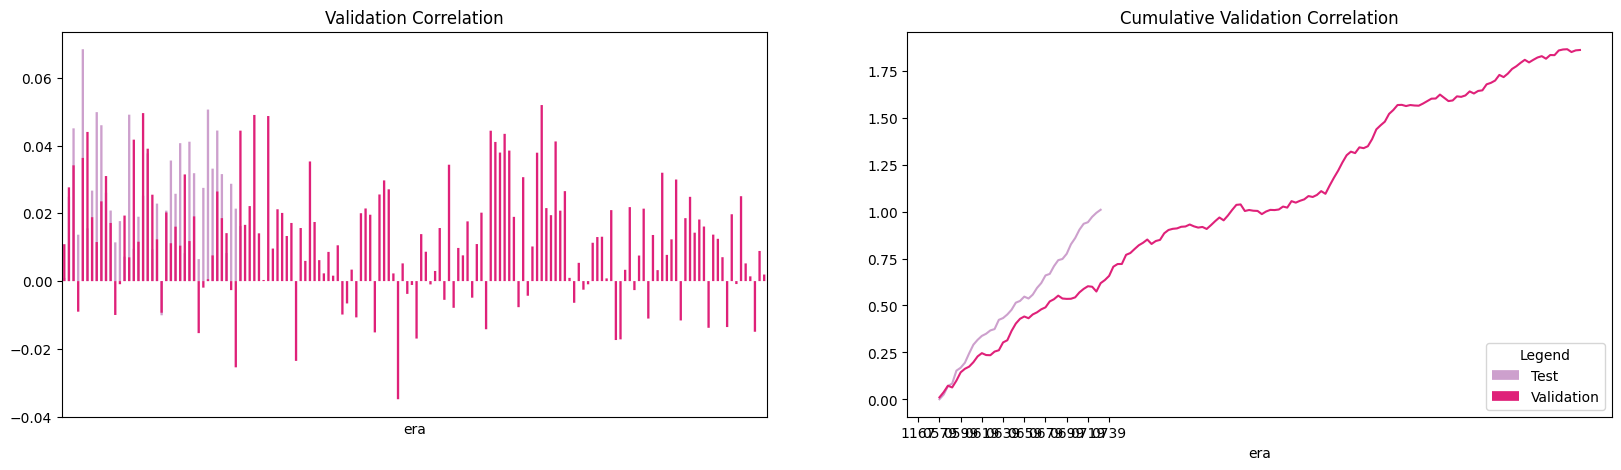

,lr_baseline_test,lr_baseline_val,lr_scaled_test,lr_scaled_val,lr_pca_test,lr_pca_val,lr_resampled_test,lr_resampled_val,lr_erasplit_test,lr_erasplit_val
mean,0.033443,0.012764,0.033443,0.012764,0.032680,0.012965,0.032217,0.012221,0.025889,0.012239
std,0.037634,0.017708,0.037634,0.017708,0.036907,0.017613,0.037188,0.017763,0.016040,0.017006
sharpe,0.888620,0.720837,0.888620,0.720837,0.885476,0.736143,0.866317,0.688007,1.614033,0.719698
max_drawdown,0.057309,0.056305,0.057309,0.056305,0.059539,0.051883,0.058490,0.062532,0.010093,0.051520


In [18]:
lr.fit(train_df_era[feature_set], train_df_era["target"])

test_df_era["prediction"] = lr.predict(test_df_era[feature_set])
per_era_corr_test = test_df_era.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_erasplit_test", per_era_corr_test, df_metrics_lr)

validation["prediction"] = lr.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lr = calc_metricas("lr_erasplit_val", per_era_corr_val, df_metrics_lr)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_lr

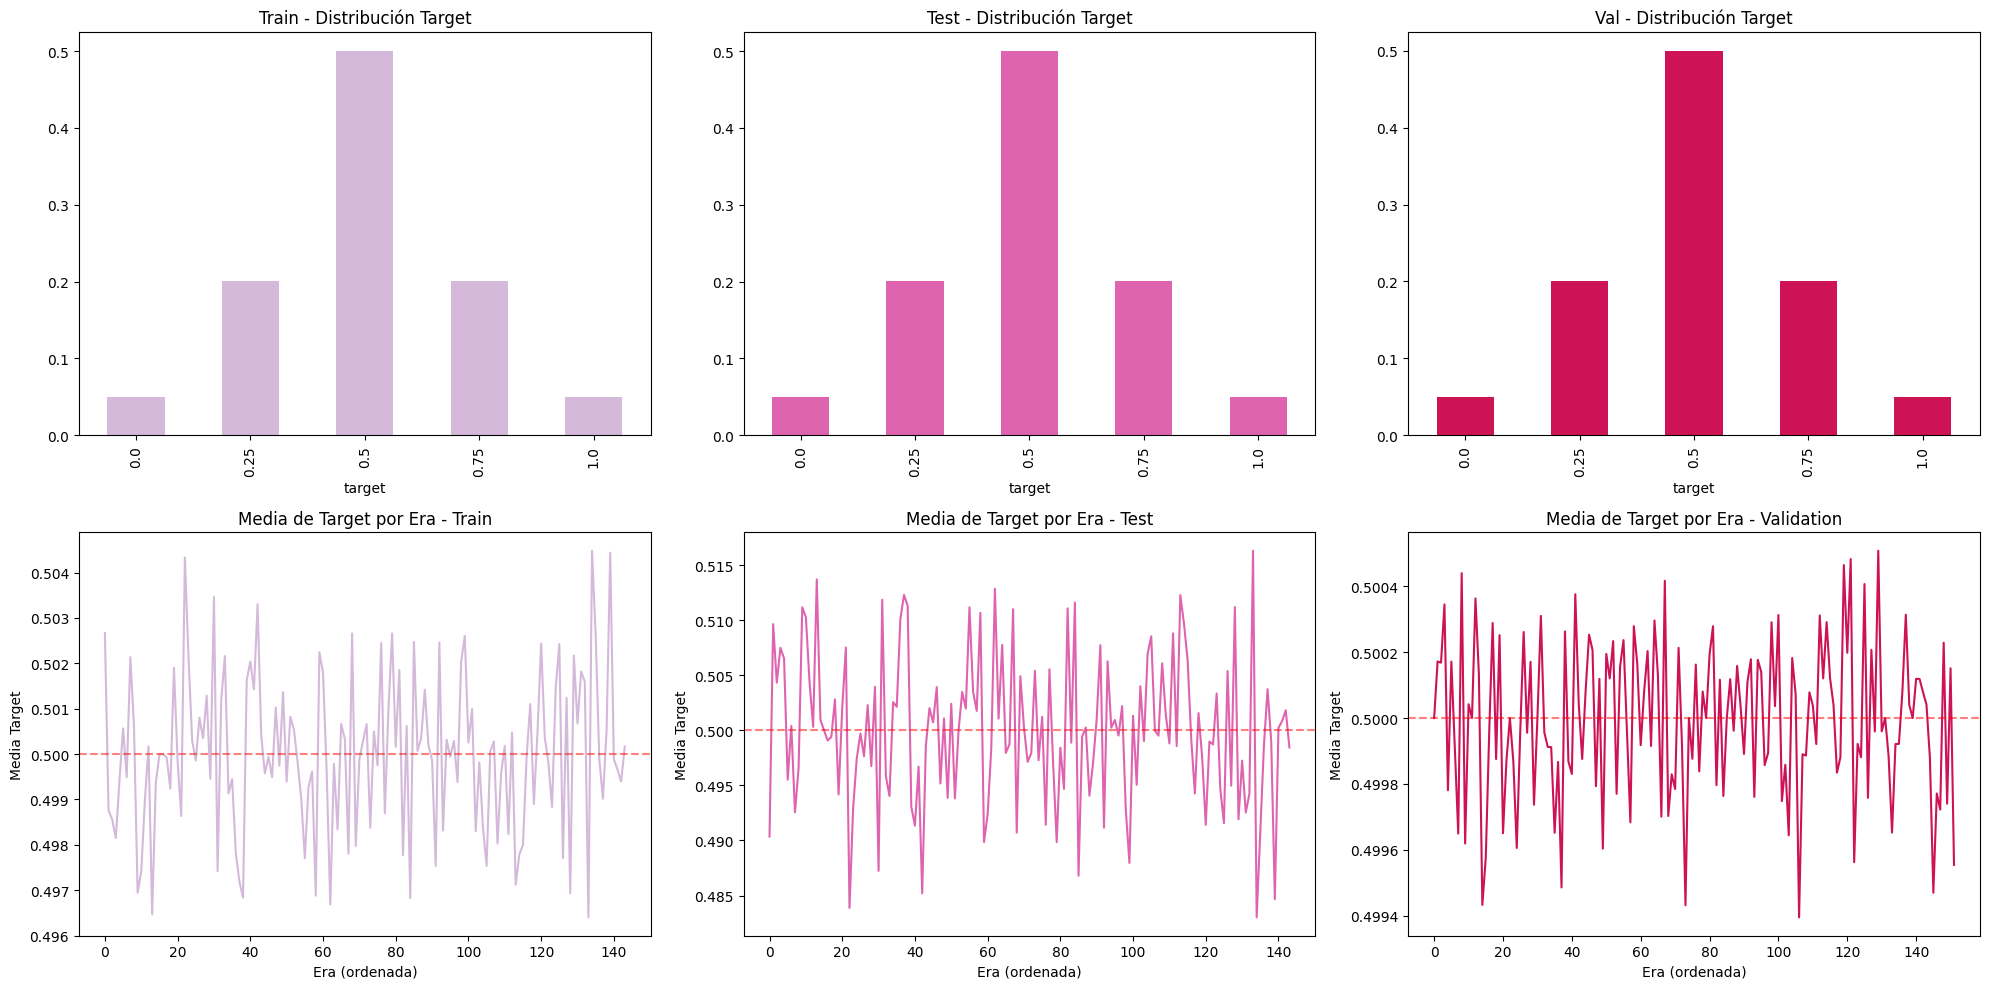

In [19]:
# Comparar distribución del target por conjunto
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
colors = sns.color_palette("PuRd", 3)
# Distribución del target
train_df['target'].value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[0,0], title='Train - Distribución Target', color=colors[0]
)
test_df['target'].value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[0,1], title='Test - Distribución Target', color=colors[1]
)
validation['target'].value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[0,2], title='Val - Distribución Target', color=colors[2]
)

# Media del target por era
train_era_means = train_df.groupby('era')['target'].mean()
test_era_means = test_df.groupby('era')['target'].mean()
val_era_means = validation.groupby('era')['target'].mean()

axes[1,0].plot(train_era_means.values, label='Train', color=colors[0])
axes[1,0].axhline(0.5, color='r', linestyle='--', alpha=0.5)
axes[1,0].set_title('Media de Target por Era - Train')
axes[1,0].set_xlabel('Era (ordenada)')
axes[1,0].set_ylabel('Media Target')

axes[1,1].plot(test_era_means.values, label='Test', color=colors[1])
axes[1,1].axhline(0.5, color='r', linestyle='--', alpha=0.5)
axes[1,1].set_title('Media de Target por Era - Test')
axes[1,1].set_xlabel('Era (ordenada)')
axes[1,1].set_ylabel('Media Target')

axes[1,2].plot(val_era_means.values, label='Validation', color=colors[2])
axes[1,2].axhline(0.5, color='r', linestyle='--', alpha=0.5)
axes[1,2].set_title('Media de Target por Era - Validation')
axes[1,2].set_xlabel('Era (ordenada)')
axes[1,2].set_ylabel('Media Target')

plt.tight_layout()

#### 2.3 Modelos descartados  

En esta sección se documentan modelos que se evaluaron pero se descartaron por rendimiento insuficiente o inviabilidad computacional.


In [20]:
df_metrics_discarded=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

2.3.1 K-NN - PCA | estandarizado  

Se intenta evaluar el rendimiento de K-NN aplicando PCA para reducir dimensionalidad y estandarización por completitud.  

Dada la magnitud del dataset, 8 componentes es la cantidad máxima que computacionalmente mi portátil ha sido capaz de soportar sin explotar. Se puede compruebar que el resultado es muy pobre e incosistente, llegando a obtener sharpe negaivos.  

A continuación se detallan algunas de las posibles razones por las que este modelo no es adecuado:  
- Como se puede observar en el pairplot de PCA, no existen agrupaciones claras en una dimensionalidad reducida. Por lo que no se pueden obtener buenos resulados con agrupaciones agresivas de PCA.  
- En una dimensionalidad alta, las distancias euclidianas se vuelven demasiado similares, por lo que tampoco sería posible capturar relaciones claras.  
- Las features están discretizadas a 0-4, no son mediciones continuas.
- K-NN asume que "muestras cercanas tienen targets similares", pero en finanzas la similitud de features no garantiza similitud de retornos futuros.

Por lo que se concluye que este modelo no es adecuado para este dataset.

Número de componentes tras PCA: 8


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2279297585.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2279297585.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"],

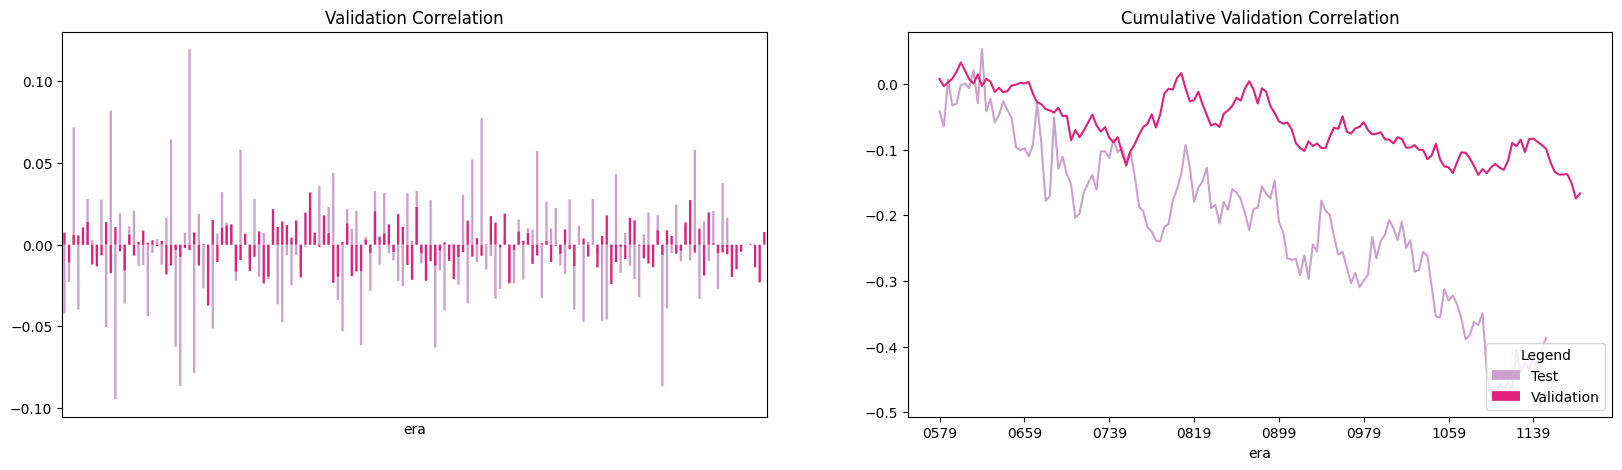

,knn_test,knn_val
mean,-0.002685,-0.001097
std,0.033854,0.012527
sharpe,-0.079320,-0.087533
max_drawdown,0.532899,0.206946


In [21]:
X_train, X_test, X_val = standarize(train_df[feature_set], test_df[feature_set], validation[feature_set])
X_train, X_test, X_val = apply_pca(8, X_train, X_test, validation[feature_set])

knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, train_df["target"])

test_df["prediction"] = knn.predict(X_test)
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_discarded = calc_metricas("knn_test", per_era_corr_test, df_metrics_discarded)

validation["prediction"] = knn.predict(X_val)
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_discarded = calc_metricas("knn_val", per_era_corr_val, df_metrics_discarded)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_discarded

2.3.2 Random Forest Regressor  

La predicción basada en árboles puede dar buenos resultados en este tipo de problemas no lineales, ya que es capaz de buscar relaciones entre features más complejas, pero entrenar un Random Forest en un dataset tan grande resulta costoso y redundante, ya que cada árbol se construye sobre un muestreo bootstrap independiente. Debido a esto, para datasets de gran tamaño es más eficiente emplear modelos de árboles optimizados como LightGBM, XGBoost o CatBoost, que implementan técnicas de aceleración y reducción de redundancia, ofreciendo mejor trade-off rendimiento/eficiencia.

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1969434586.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1969434586.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

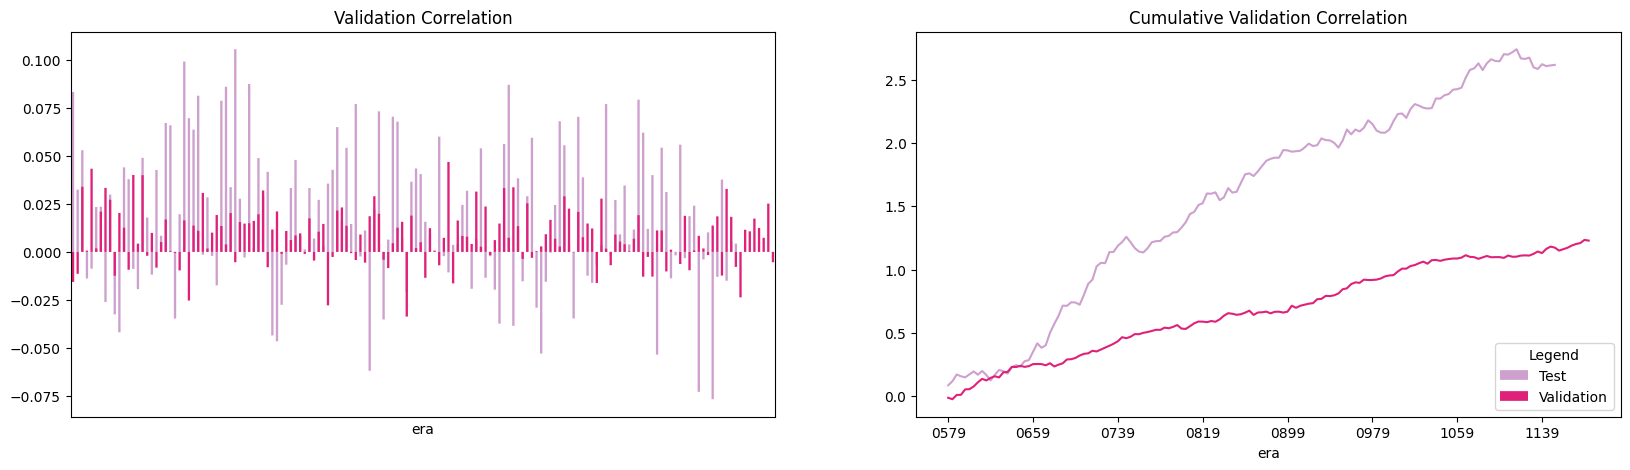

,knn_test,knn_val,rf_test,rf_val
mean,-0.002685,-0.001097,0.018195,0.008085
std,0.033854,0.012527,0.037291,0.014325
sharpe,-0.079320,-0.087533,0.487927,0.564423
max_drawdown,0.532899,0.206946,0.156318,0.033680


In [22]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    min_samples_split=10,
    random_state=42
)

rf.fit(train_df[feature_set], train_df["target"])

test_df["prediction"] = rf.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_discarded = calc_metricas("rf_test", per_era_corr_test, df_metrics_discarded)

validation["prediction"] = rf.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_discarded = calc_metricas("rf_val", per_era_corr_val, df_metrics_discarded)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_discarded

#### 2.4 Modelos a considerar  

En esta sección se evalúan modelos de Gradient Boosting (GB) optimizados, que representan el estado del arte en problemas de machine learning con datos tabulares de alta dimensionalidad.  

>   Gradient boosting o potenciación del gradiente, es una técnica de aprendizaje automático utilizado para el análisis de la regresión y para problemas de clasificación estadística, el cual produce un modelo predictivo en forma de un conjunto de modelos de predicción débiles, típicamente árboles de decisión. Construye el modelo de forma escalonada como lo hacen otros métodos de boosting, y los generaliza permitiendo la optimización arbitraria de una función de pérdida diferenciable.

Notas: La comparativa final de estos 3 modelos se realizará más adelante, en 2.6 Entrenamiento y comparativa de modelos finales.

In [23]:
df_metrics_potential=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

2.4.1 LGBM Regressor  

Este modelo basado en árboles está diseñado para velocidad y escalabilidad, por lo que en datasets grandes como este puede lucir muy bien. Es un modelo de GB, y su estrategia de crecimiento es mediante leaf-wise. Eso quiere decir que el árbol no crece por niveles, sino únicamente por la hoja con mayor ganancia (es decir, la que reduzca más las función de error o coste). De esta manera se produce un árbol muy profundo y asimétrico. De ahí su gran velocidad.  

El problema es que tiene mucho riesgo de overfitting, ya que su método se basa en descartar todo aquello que no sea la mejor hoja.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 550547, number of used features: 42
[LightGBM] [Info] Start training from score 0.500008


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2625638937.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2625638937.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

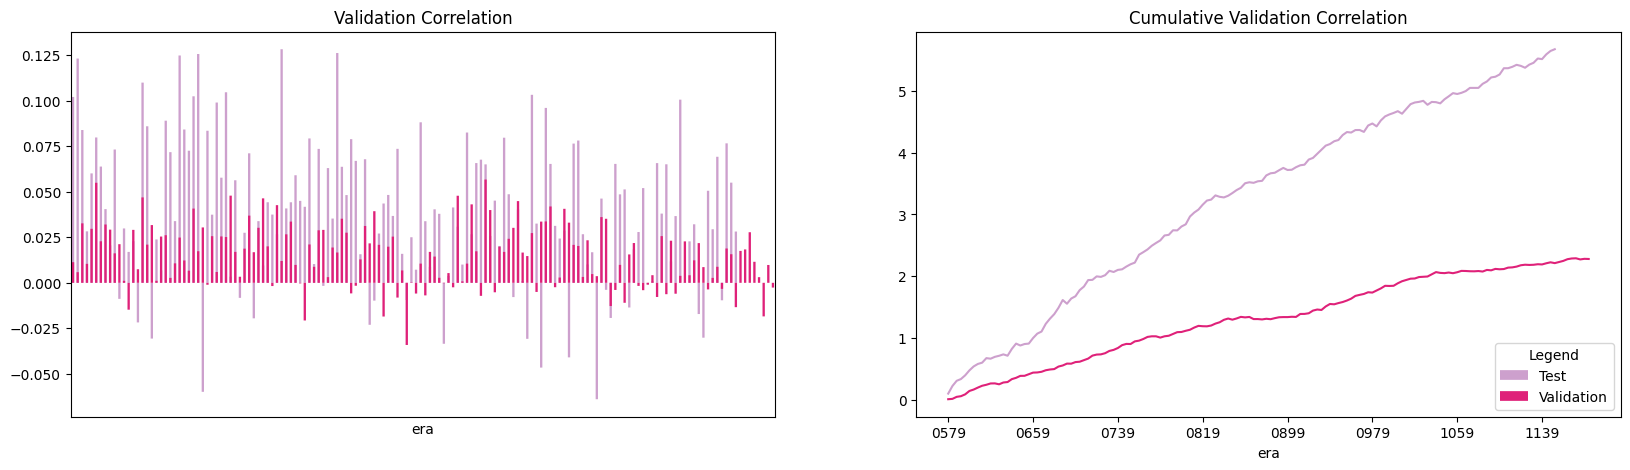

,lgbm_test,lgbm_val
mean,0.039394,0.014998
std,0.039790,0.016760
sharpe,0.990039,0.894914
max_drawdown,0.063978,0.041151


In [24]:
lgbm = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(train_df[feature_set], train_df["target"],
        eval_set=(test_df[feature_set], test_df["target"]))

test_df["prediction"] = lgbm.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("lgbm_test", per_era_corr_test, df_metrics_potential)

validation["prediction"] = lgbm.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("lgbm_val", per_era_corr_val, df_metrics_potential)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_potential

2.4.2 Cat Boost Regressor  

CatBoost (Categorical Boosting) es un framework de GB desarrollado por Yandex, especializado en el manejo de features categóricas y diseñado para reducir overfitting mediante técnicas innovadoras.  

La principal diferencia de este modelos es que implementa una variante llamada Ordered Boosting (OB) que mejora la estimación de gradientes para reducir prediction shift (un tipo específico de overfitting).  

En qué se diferencia entonces GB y OB?  
Se diferencian en la técnica de selección de muestras utilizadas para predecir. Mientras que en GB el modelo se entrena y evalúa sobre las mismas muestras, produciendo de esta manera un target leakage sutil, OB resuelve ese problema ordenando de manera aleatoria todas las muestras, y usando únicamente modelos entrenados con muestras anteriores, de esta manera consigue una simulación más fiel de cómo el modelo verá datos nuevos.  

Otra diferencia clave es que CatBoost es el único de los tres (LGBM, XGB y CatBoost) que puede manejar categorical features sin necesidad de encoding previo, ya que implementa Target Statistics internamente. Para ver su eficiencia, se han entrenado 2 modelos distintos, primero uno categorizando todas las columnas, y otra sin categorizarlas. Los resulatados obtenidos al categorizar las columnas difieren en un <0.2 en general en sharpe. Eso se debe a que, como las features ya estás discretizadas a 0-4, al categorizarlas únicamente está perdiendo la relación entre los valores.  

> Notas sobre Oblivious decision trees:  
> CatBoost utiliza esta característica, eso significa que cada nivel de árbol utiliza la misma feature y mismo threshold, resultando en árboles balanceados y simétricos. Esto lo que permite es conseguir predicciones rápidas con menor riesgo de overfitting, pero potencialmente menos expresivos que árboles asimétricos.


2.4.2.1 CatBoost con cat_features

0:	learn: 0.2231486	test: 0.2231457	best: 0.2231457 (0)	total: 1.07s	remaining: 17m 48s
100:	learn: 0.2231095	test: 0.2231253	best: 0.2231253 (100)	total: 1m 34s	remaining: 13m 58s
200:	learn: 0.2230784	test: 0.2231097	best: 0.2231097 (200)	total: 3m 10s	remaining: 12m 37s
300:	learn: 0.2230543	test: 0.2230983	best: 0.2230983 (300)	total: 4m 41s	remaining: 10m 53s
400:	learn: 0.2230338	test: 0.2230894	best: 0.2230893 (398)	total: 6m 11s	remaining: 9m 15s
500:	learn: 0.2230136	test: 0.2230831	best: 0.2230831 (500)	total: 7m 46s	remaining: 7m 44s
600:	learn: 0.2229959	test: 0.2230776	best: 0.2230776 (599)	total: 9m 23s	remaining: 6m 14s
700:	learn: 0.2229813	test: 0.2230732	best: 0.2230732 (700)	total: 11m 1s	remaining: 4m 41s
800:	learn: 0.2229635	test: 0.2230681	best: 0.2230681 (800)	total: 12m 40s	remaining: 3m 9s
900:	learn: 0.2229490	test: 0.2230651	best: 0.2230650 (898)	total: 14m 15s	remaining: 1m 34s
999:	learn: 0.2229359	test: 0.2230617	best: 0.2230617 (999)	total: 15m 51s	remai

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1132552602.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1132552602.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

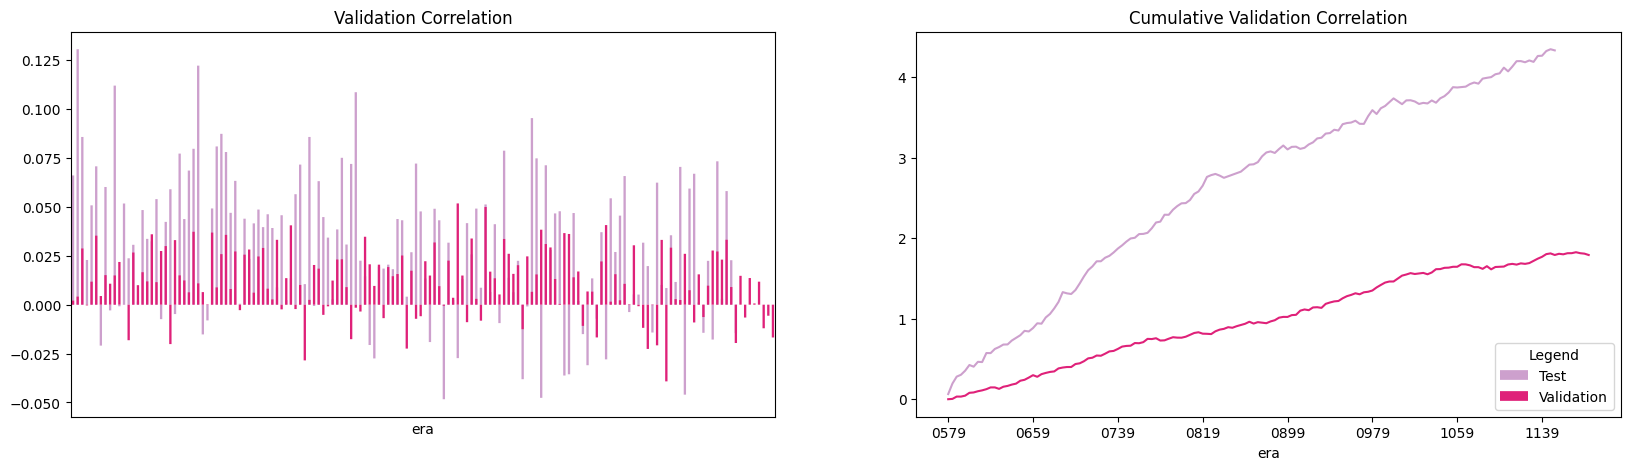

,lgbm_test,lgbm_val,cbr_cat_test,cbr_cat_val
mean,0.039394,0.014998,0.030090,0.011794
std,0.039790,0.016760,0.035966,0.016682
sharpe,0.990039,0.894914,0.836624,0.706944
max_drawdown,0.063978,0.041151,0.071833,0.062337


In [25]:
cbr = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    random_seed=42,
    bagging_temperature=0.5,
    cat_features=list(range(len(feature_set))),
    l2_leaf_reg=3
)

cbr.fit(train_df[feature_set], train_df["target"],
        eval_set=(test_df[feature_set], test_df["target"]),
        use_best_model=True,
        early_stopping_rounds=50,
        verbose=100
        )

test_df["prediction"] = cbr.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("cbr_cat_test", per_era_corr_test, df_metrics_potential)

validation["prediction"] = cbr.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("cbr_cat_val", per_era_corr_val, df_metrics_potential)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_potential

2.4.2.2 CatBoost sin cat_features

0:	learn: 0.2231476	test: 0.2231449	best: 0.2231449 (0)	total: 38.3ms	remaining: 38.2s
100:	learn: 0.2230516	test: 0.2230853	best: 0.2230853 (100)	total: 3.84s	remaining: 34.2s
200:	learn: 0.2229807	test: 0.2230519	best: 0.2230519 (200)	total: 7.76s	remaining: 30.9s
300:	learn: 0.2229210	test: 0.2230284	best: 0.2230284 (300)	total: 11.7s	remaining: 27.1s
400:	learn: 0.2228654	test: 0.2230069	best: 0.2230069 (400)	total: 15.6s	remaining: 23.3s
500:	learn: 0.2228156	test: 0.2229926	best: 0.2229926 (500)	total: 19.5s	remaining: 19.4s
600:	learn: 0.2227672	test: 0.2229775	best: 0.2229775 (600)	total: 23.6s	remaining: 15.7s
700:	learn: 0.2227217	test: 0.2229688	best: 0.2229688 (697)	total: 27.7s	remaining: 11.8s
800:	learn: 0.2226771	test: 0.2229602	best: 0.2229602 (795)	total: 31.8s	remaining: 7.89s
900:	learn: 0.2226347	test: 0.2229522	best: 0.2229521 (898)	total: 36s	remaining: 3.95s
999:	learn: 0.2225920	test: 0.2229451	best: 0.2229449 (995)	total: 40.2s	remaining: 0us

bestTest = 0.222

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3912878814.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3912878814.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

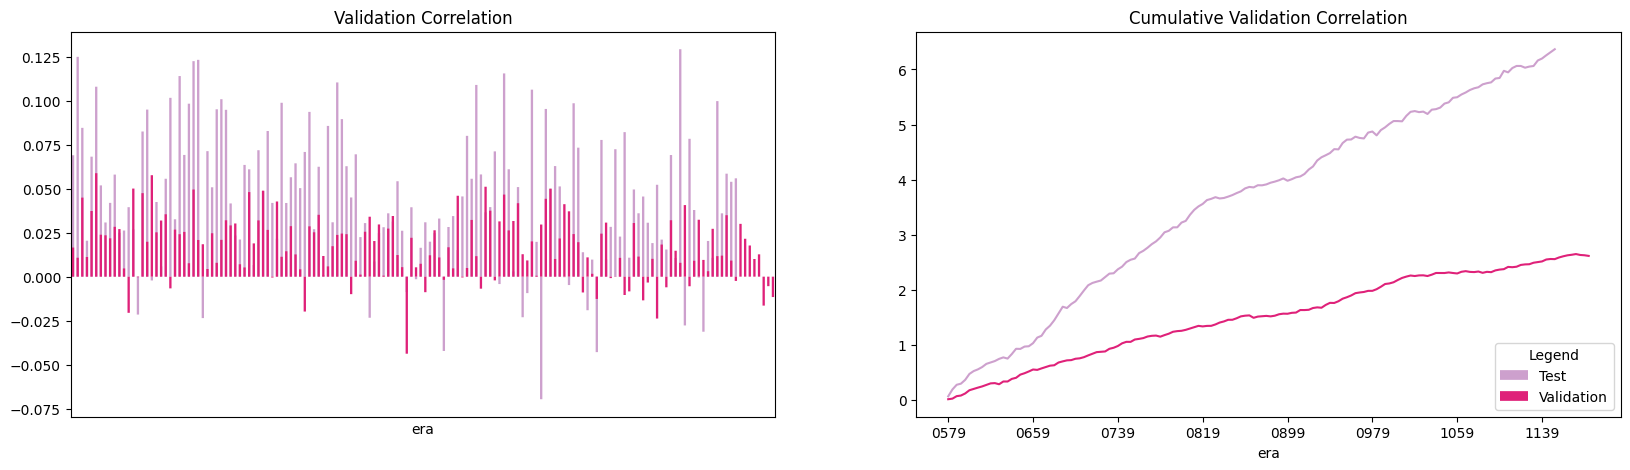

,lgbm_test,lgbm_val,cbr_cat_test,cbr_cat_val,cbr_test,cbr_val
mean,0.039394,0.014998,0.030090,0.011794,0.044218,0.017218
std,0.039790,0.016760,0.035966,0.016682,0.038761,0.017972
sharpe,0.990039,0.894914,0.836624,0.706944,1.140781,0.958021
max_drawdown,0.063978,0.041151,0.071833,0.062337,0.069686,0.043806


In [26]:
cbr = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    random_seed=42,
    bagging_temperature=0.5,
    #cat_features=list(range(len(feature_set))),
    l2_leaf_reg=3
)

cbr.fit(train_df[feature_set], train_df["target"],
        eval_set=(test_df[feature_set], test_df["target"]),
        use_best_model=True,
        early_stopping_rounds=50,
        verbose=100
        )

test_df["prediction"] = cbr.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("cbr_test", per_era_corr_test, df_metrics_potential)

validation["prediction"] = cbr.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("cbr_val", per_era_corr_val, df_metrics_potential)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_potential

2.4.3 XGB Regressor  

XGBoost (eXtreme Gradient Boosting) es un framework de GB altamente optimizado, considerado durante años el estándar de facto en competiciones de machine learning (especialmente Kaggle). Representa un equilibrio entre velocidad, rendimiento y estabilidad.

És más lento que LGBM, pero más rápido que CBR. A diferencia de LGBM, su gradient boosting se basa en level-wise, es decir que crece de manera simétrica por niveles (por ello es un poco más lento y menos eficiente que LGBM), pero gana en estabilidad, menos overfitting. En cambio, comparado con CBR, sigue siendo un modelo muy agresivo.  

> Notas interesantes: XGB Regressor es un *sparcity-aware algorithm*: Maneja valores faltantes eficientemente sin necesidad de imputación, aprende automáticamente la dirección óptima para valores faltantes.

[0]	validation_0-rmse:0.22314
[100]	validation_0-rmse:0.22298
[200]	validation_0-rmse:0.22295
[300]	validation_0-rmse:0.22294
[314]	validation_0-rmse:0.22294


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3048358109.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3048358109.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

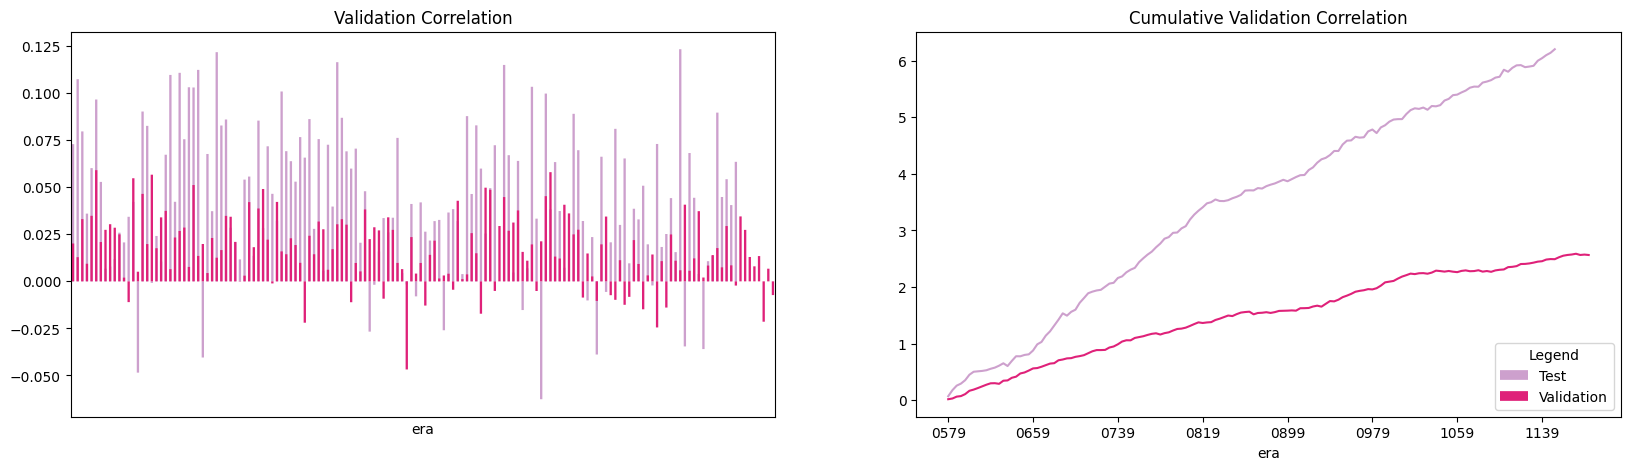

,lgbm_test,lgbm_val,cbr_cat_test,cbr_cat_val,cbr_test,cbr_val,xgb_test,xgb_val
mean,0.039394,0.014998,0.030090,0.011794,0.044218,0.017218,0.043060,0.016887
std,0.039790,0.016760,0.035966,0.016682,0.038761,0.017972,0.038228,0.018367
sharpe,0.990039,0.894914,0.836624,0.706944,1.140781,0.958021,1.126389,0.919430
max_drawdown,0.063978,0.041151,0.071833,0.062337,0.069686,0.043806,0.062601,0.046793


In [27]:
xgb = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    #min_child_weight=5,
    early_stopping_rounds=50,
    #reg_alpha=3,
    reg_lambda=30,
    random_state=42
)

xgb.fit(train_df[feature_set], train_df["target"],
        eval_set=[(test_df[feature_set], test_df["target"])],
        verbose=100)

test_df["prediction"] = xgb.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("xgb_test", per_era_corr_test, df_metrics_potential)

validation["prediction"] = xgb.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_potential = calc_metricas("xgb_val", per_era_corr_val, df_metrics_potential)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_potential

#### 2.5 Análisis modelos Lineal (Linear Regression) VS No Lineal (XGB Regressor)

In [28]:
df_metrics_xgb=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

2.5.1 Modelado de XGB en base a distintos preprocesamientos  

Para hacer una tabla comparativa, se va a definir un modelo XGB (con los parámetros por del modelo por defecto) y se van a probar todos los tipos de preprocesamiento vistos anteriormente.

2.5.1.1 XGB Baseline

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\207898463.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\207898463.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x

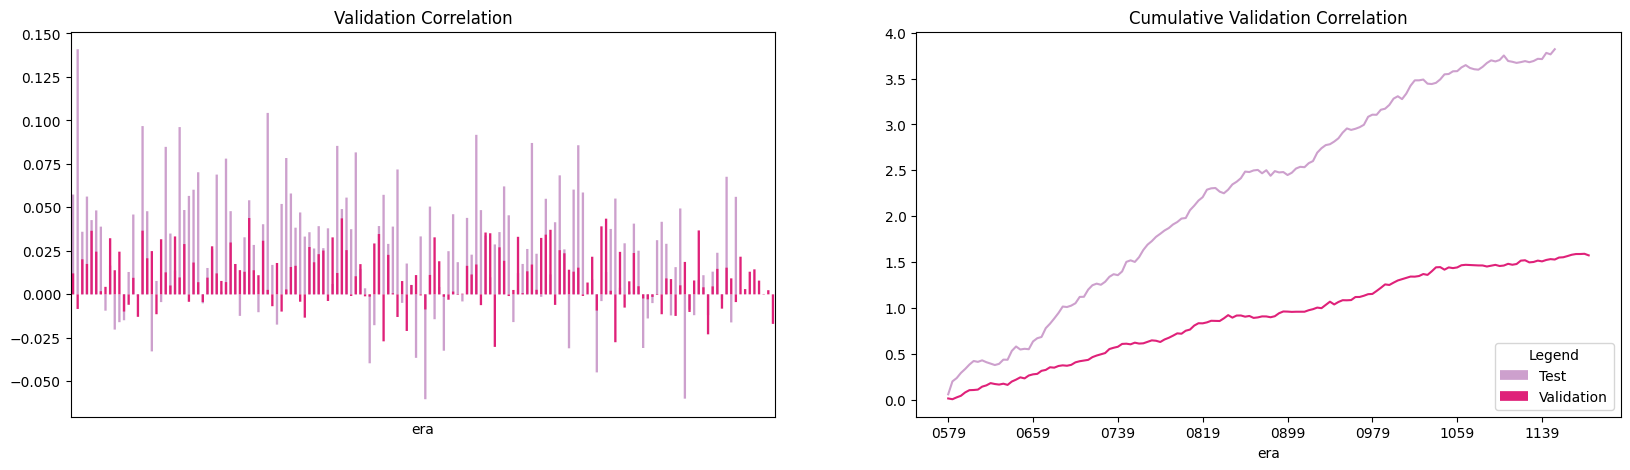

,xgb_baseline_test,xgb_baseline_val
mean,0.026527,0.010345
std,0.034558,0.015691
sharpe,0.767616,0.659247
max_drawdown,0.080686,0.030199


In [29]:
xgb_base = XGBRegressor()

xgb_base.fit(train_df[feature_set], train_df["target"])

test_df["prediction"] = xgb_base.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_baseline_test", per_era_corr_test, df_metrics_xgb)

validation["prediction"] = xgb_base.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_baseline_val", per_era_corr_val, df_metrics_xgb)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_xgb

2.5.1.2 XGB Estandarizado

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3561608578.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3561608578.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"],

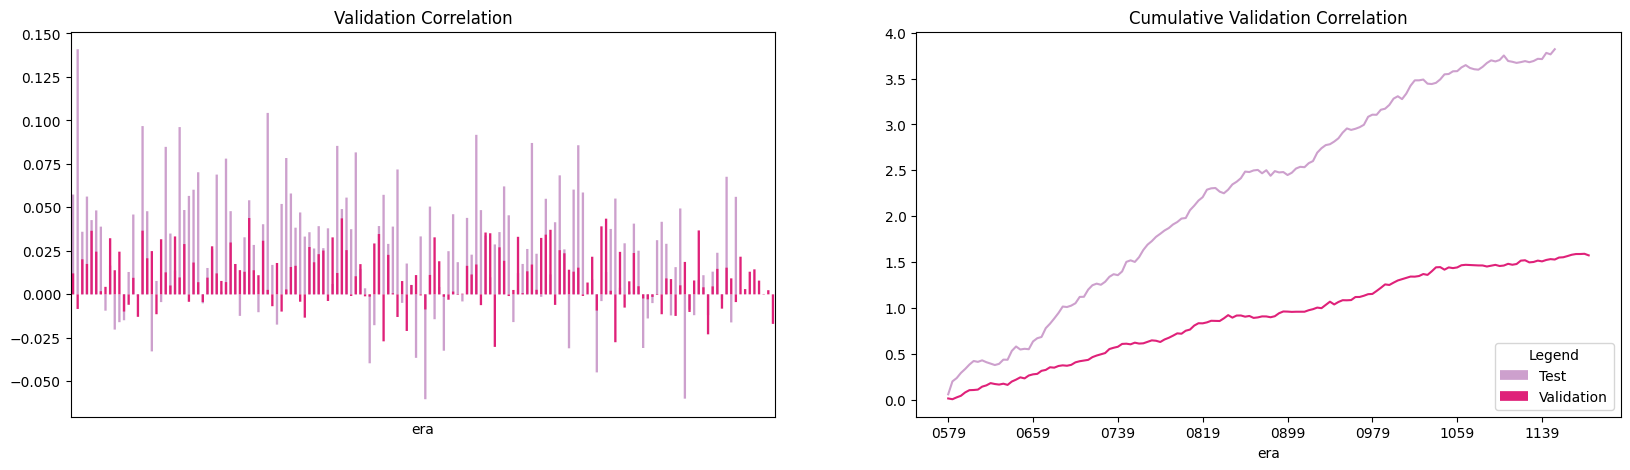

,xgb_baseline_test,xgb_baseline_val,xgb_scaled_test,xgb_scaled_val
mean,0.026527,0.010345,0.026527,0.010345
std,0.034558,0.015691,0.034558,0.015691
sharpe,0.767616,0.659247,0.767616,0.659247
max_drawdown,0.080686,0.030199,0.080686,0.030199


In [30]:
X_train, X_test, X_val = standarize(train_df[feature_set], test_df[feature_set], validation[feature_set])

xgb_base.fit(X_train, train_df["target"])

test_df["prediction"] = xgb_base.predict(X_test)
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_scaled_test", per_era_corr_test, df_metrics_xgb)

validation["prediction"] = xgb_base.predict(X_val)
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_scaled_val", per_era_corr_val, df_metrics_xgb)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_xgb

2.5.1.3 XGB PCA

Número de componentes tras PCA: 41


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1906231451.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1906231451.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"],

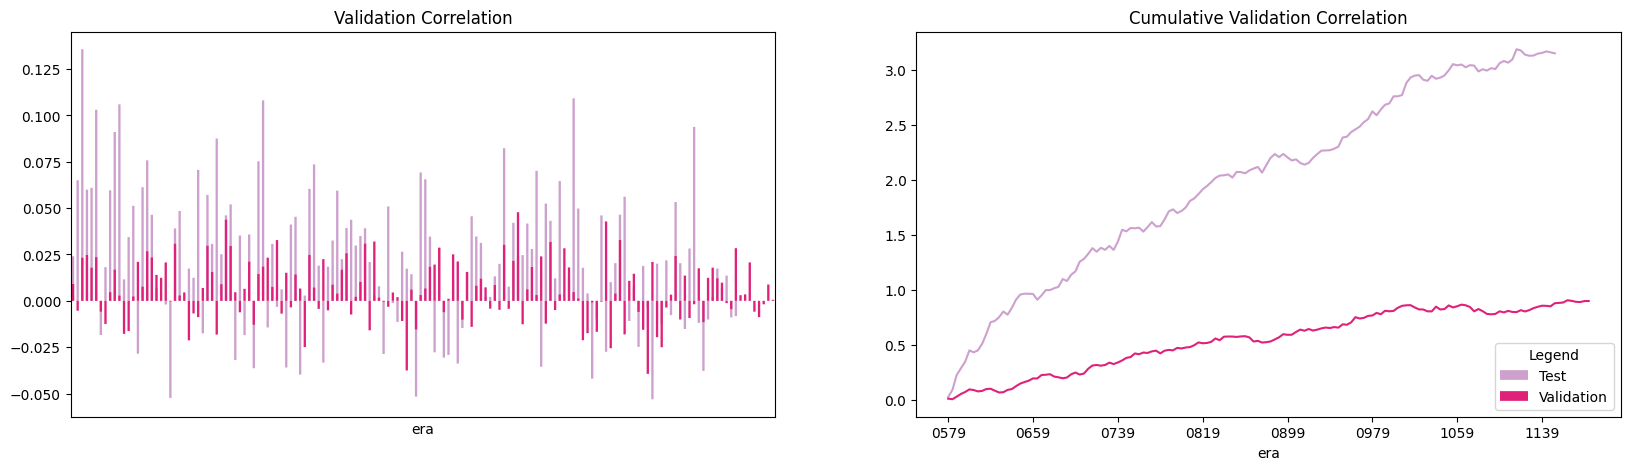

,xgb_baseline_test,xgb_baseline_val,xgb_scaled_test,xgb_scaled_val,xgb_pca_test,xgb_pca_val
mean,0.026527,0.010345,0.026527,0.010345,0.021900,0.005908
std,0.034558,0.015691,0.034558,0.015691,0.036984,0.016204
sharpe,0.767616,0.659247,0.767616,0.659247,0.592141,0.364597
max_drawdown,0.080686,0.030199,0.080686,0.030199,0.097009,0.088191


In [31]:
X_train, X_test, X_val = apply_pca(0.99, train_df[feature_set], test_df[feature_set], validation[feature_set])

xgb_base.fit(X_train, train_df["target"])

test_df["prediction"] = xgb_base.predict(X_test)
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_pca_test", per_era_corr_test, df_metrics_xgb)

validation["prediction"] = xgb_base.predict(X_val)
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_pca_val", per_era_corr_val, df_metrics_xgb)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_xgb

2.5.1.4 XGB Resample

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1718439395.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1718439395.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"],

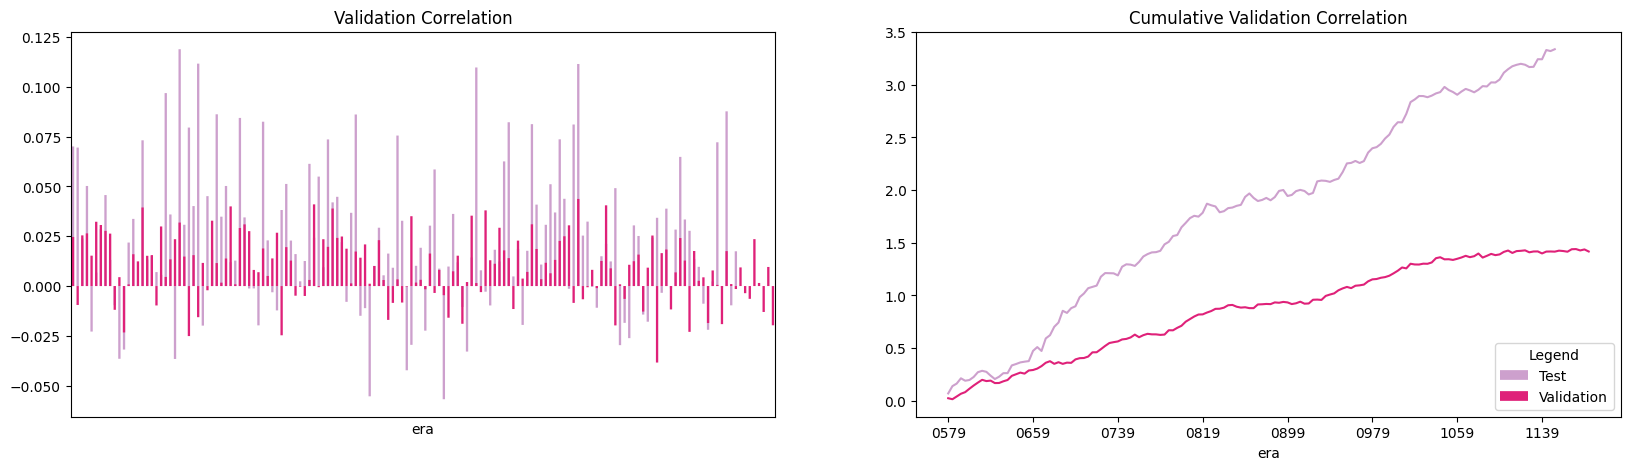

,xgb_baseline_test,xgb_baseline_val,xgb_scaled_test,xgb_scaled_val,xgb_pca_test,xgb_pca_val,xgb_resampled_test,xgb_resampled_val
mean,0.026527,0.010345,0.026527,0.010345,0.021900,0.005908,0.023177,0.009325
std,0.034558,0.015691,0.034558,0.015691,0.036984,0.016204,0.035467,0.016065
sharpe,0.767616,0.659247,0.767616,0.659247,0.592141,0.364597,0.653481,0.580408
max_drawdown,0.080686,0.030199,0.080686,0.030199,0.097009,0.088191,0.081374,0.038403


In [32]:
train_resampled = resample(train_df)

xgb_base.fit(train_resampled[feature_set], train_resampled["target"])

test_df["prediction"] = xgb_base.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_resampled_test", per_era_corr_test, df_metrics_xgb)

validation["prediction"] = xgb_base.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_resampled_val", per_era_corr_val, df_metrics_xgb)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_xgb

2.5.1.5 XGB Era split

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\678749570.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df_era.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\678749570.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

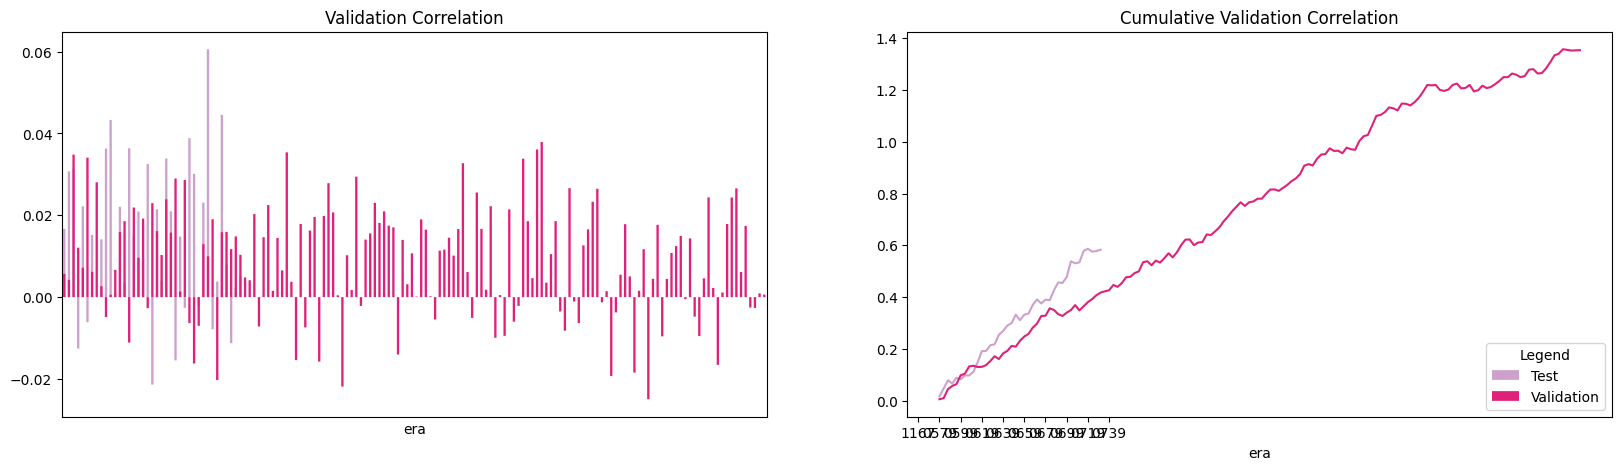

,xgb_baseline_test,xgb_baseline_val,xgb_scaled_test,xgb_scaled_val,xgb_pca_test,xgb_pca_val,xgb_resampled_test,xgb_resampled_val,xgb_erasplit_test,xgb_erasplit_val
mean,0.026527,0.010345,0.026527,0.010345,0.021900,0.005908,0.023177,0.009325,0.014951,0.008905
std,0.034558,0.015691,0.034558,0.015691,0.036984,0.016204,0.035467,0.016065,0.018492,0.013337
sharpe,0.767616,0.659247,0.767616,0.659247,0.592141,0.364597,0.653481,0.580408,0.808508,0.667662
max_drawdown,0.080686,0.030199,0.080686,0.030199,0.097009,0.088191,0.081374,0.038403,0.021381,0.030138


In [33]:
xgb_base.fit(train_df_era[feature_set], train_df_era["target"])

test_df_era["prediction"] = xgb_base.predict(test_df_era[feature_set])
per_era_corr_test = test_df_era.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_erasplit_test", per_era_corr_test, df_metrics_xgb)

validation["prediction"] = xgb_base.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_xgb = calc_metricas("xgb_erasplit_val", per_era_corr_val, df_metrics_xgb)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_xgb

2.5.2 Conclusiones  

Nota metodológica: Para esta comparación se utilizaron las configuraciones base de cada modelo (hiperparámetros por defecto) para aislar el efecto específico de cada preprocesamiento.

Comparación por tipos de preprocesamiento:  

|  | LR | XGB | Conclusión |    
|--|----|-----|------------|    
|Baseline| Rendimiento limitado por la naturaleza no lineal del problema, confirmada en la matriz de correlación de Pearson, aunque la simplicidad extrema previene overfitting incluso con configuración mínima | Como se ha visto anteriormente, XGB sí tiene la capacidad de mejorar considerablemente respecto a LR, pero los hiperparámetros por defecto en este caso son demasiado agresivos para estos datos, lo cual genera overfitting|El potencial de XGBoost es superior, pero requiere configuración cuidadosa|    
|Escalado| La solución de mínimos cuadrados es invariante a escalado lineal, es decir, los coeficientes se ajustan proporcionalmente, resultando en predicciones idénticas | La escala absoluta es irrelevante para divisiones binarias, por lo que no importa si los datos están estandarizados, que captura la misma partición | Confirmado que el escalado es innecesario para este dataset |    
|PCA=0.99| La mejora marginal en validación (+2.8%: 0.72 → 0.74) puede deberse a regularización implícita al eliminar componentes de baja varianza y reducción de multicolinealidad. Esto produce componentes ortogonales, mejorando estabilidad numérica | PCA rompe la interpretabilidad de las features, por lo que destruye la capacidad de XGB de aprender interacciones no lineales entre features originales, causando una caída (0.59 → 0.36) | PCA es contraproducente para modelos ensemble de árboles. Solo útil para modelos lineales o datasets con dimensionalidad extrema | 
|Resample| Aprende coeficientes globales ponderados por frecuencia de clase, el resampling cambia los pesos, pero el modelo es simple y robusto. Por ello, la degradación es moderada (-4.2%) | XGB construye árboles profundos que memorizan patrones locales, y al replicar muestras, éstos árboles se dividen en hojas que separan muestras duplicadas idénticas. La degradación es más pronunciada (-12%) | El resampling no solo es ineficaz, sino perjudicial para ambos modelos. La distribución natural del problema debe respetarse |    
|EraSplit| Test es anormalmente alto, mientras que val es normal | Test es alto, y en val baja rendimiento | Genera métricas poco fiables porque el test set resultante contiene muy pocas eras (~100), causando que sharpe sea artificialmente alto. Además, dado que era_specificity es muy bajo, las features son robustas temporalmente y no hay beneficio significativo en dividir por eras |    

Como conclusión, se descarta el uso de preprocesamiento ya que no aportan mejora significaiva, o incluso empeoran el rendimiento. Se van a dividir los datos de manera aleatoria, superponiendo las eras en train y test.

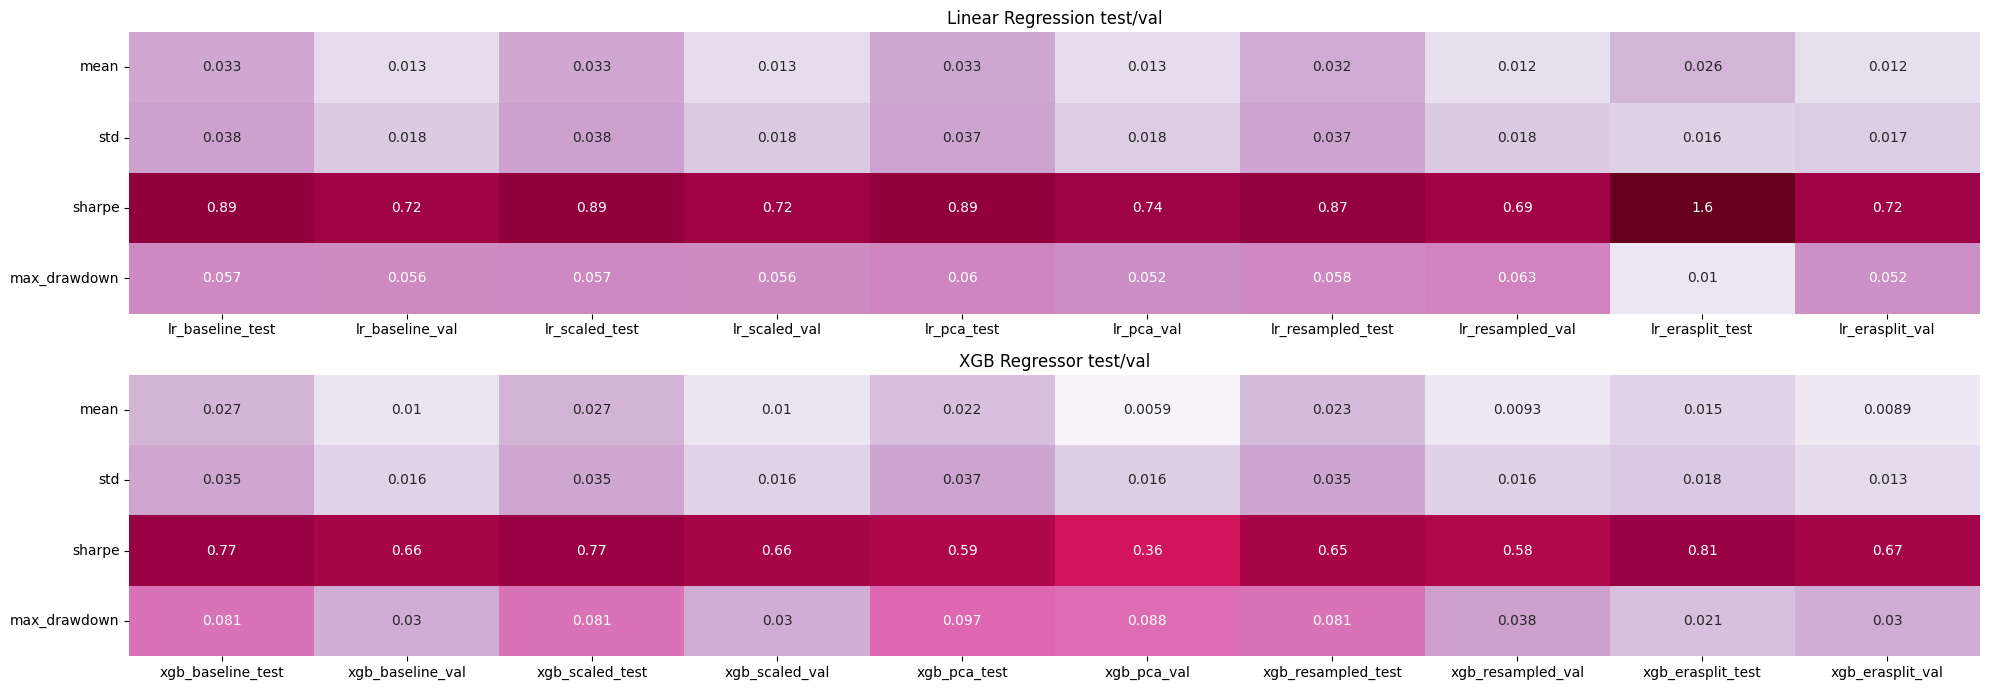

In [34]:
def reshape_metrics(df, model_name):
    df_t = df.T.reset_index()
    df_t[['model', 'setup', 'set']] = df_t['index'].str.extract(r'(\w+)_(\w+)_(test|val)')
    df_t = df_t.drop(columns='index')
    df_t['model'] = model_name
    return df_t

xgb_long = reshape_metrics(df_metrics_xgb, 'XGB')
lr_long = reshape_metrics(df_metrics_lr, 'LR')

df_all = pd.concat([xgb_long, lr_long])
df_all_melt = df_all.melt(
    id_vars=['model', 'setup', 'set'],
    var_name='metric',
    value_name='value'
)

vmin = df_all_melt['value'].min()
vmax = df_all_melt['value'].max()

fig, axs = plt.subplots(2, 1, figsize = (20,7))
sns.heatmap(df_metrics_lr, annot=True, cmap='PuRd', vmin=vmin, vmax=vmax, norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[0], cbar=False)
axs[0].set_title('Linear Regression test/val')
sns.heatmap(df_metrics_xgb, annot=True, cmap='PuRd', vmin=vmin, vmax=vmax, norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[1], cbar=False)
axs[1].set_title('XGB Regressor test/val')
plt.tight_layout()

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3775391081.py:1: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.catplot(
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3775391081.py:11: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.catplot(


Text(0.5, 0.98, 'Comparación de modelos en Val')

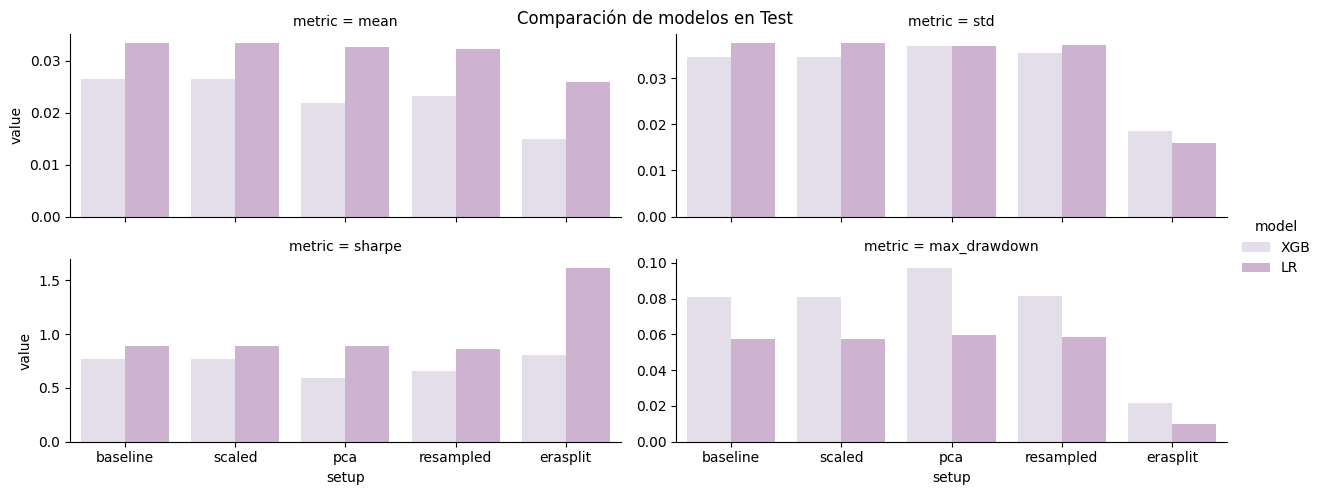

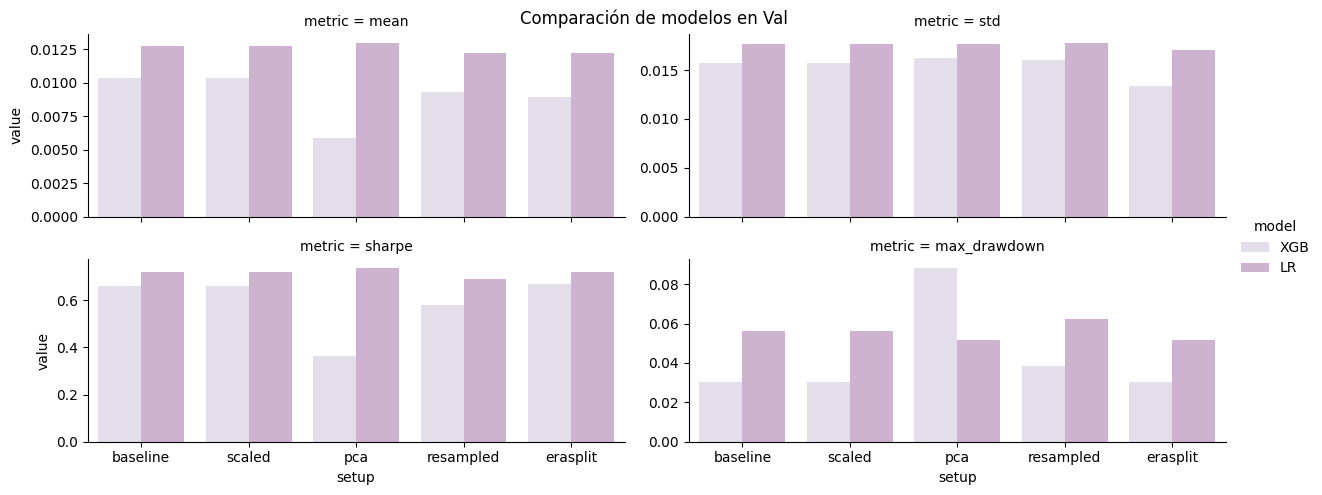

In [35]:
sns.catplot(
    data=df_all_melt[df_all_melt['set'] == 'test'],
    x='setup', y='value', hue='model',
    col='metric', kind='bar',
    col_wrap=2, height=2.5, aspect=2.5,
    palette=sns.color_palette("PuRd"),
    sharey=False
)
plt.suptitle("Comparación de modelos en Test")

sns.catplot(
    data=df_all_melt[df_all_melt['set'] == 'val'],
    x='setup', y='value', hue='model',
    col='metric', kind='bar',
    col_wrap=2, height=2.5, aspect=2.5,
    palette=sns.color_palette("PuRd"),
    sharey=False
)
plt.suptitle("Comparación de modelos en Val")


### 2.6 Entrenamiento y comparativa de los modelos finales

2.6.1 Descarga de features medium | eras::2

In [36]:
feature_set_m = feature_metadata["feature_sets"]["medium"]

train_m = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set_m
)
validation_m = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set_m
)
validation_m = validation_m[validation_m["data_type"] == "validation"]
del validation_m["data_type"]

# Comenta la línea a continuación para utilizar todos los datos.
train_m = train_m[train_m["era"].isin(train_m["era"].unique()[::2])]

# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation_m = validation_m[validation_m["era"].isin(validation_m["era"].unique()[::2])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train_m["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation_m = validation_m[~validation_m["era"].isin(eras_to_embargo)]

2.6.2 Partición del dataset

In [37]:
train_df_m, test_df_m = random_split(train_m)

In [38]:
df_metrics_final=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

2.6.3 Entrenamiento

2.6.3.1 XGB

[0]	validation_0-rmse:0.22313
[100]	validation_0-rmse:0.22287
[200]	validation_0-rmse:0.22273
[300]	validation_0-rmse:0.22261
[400]	validation_0-rmse:0.22252
[500]	validation_0-rmse:0.22243
[600]	validation_0-rmse:0.22234
[700]	validation_0-rmse:0.22227
[800]	validation_0-rmse:0.22220
[900]	validation_0-rmse:0.22213
[1000]	validation_0-rmse:0.22208
[1100]	validation_0-rmse:0.22201
[1199]	validation_0-rmse:0.22195


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1847439887.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1847439887.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation_m.groupby("era").apply(lambda x: practica_corr(x["predictio

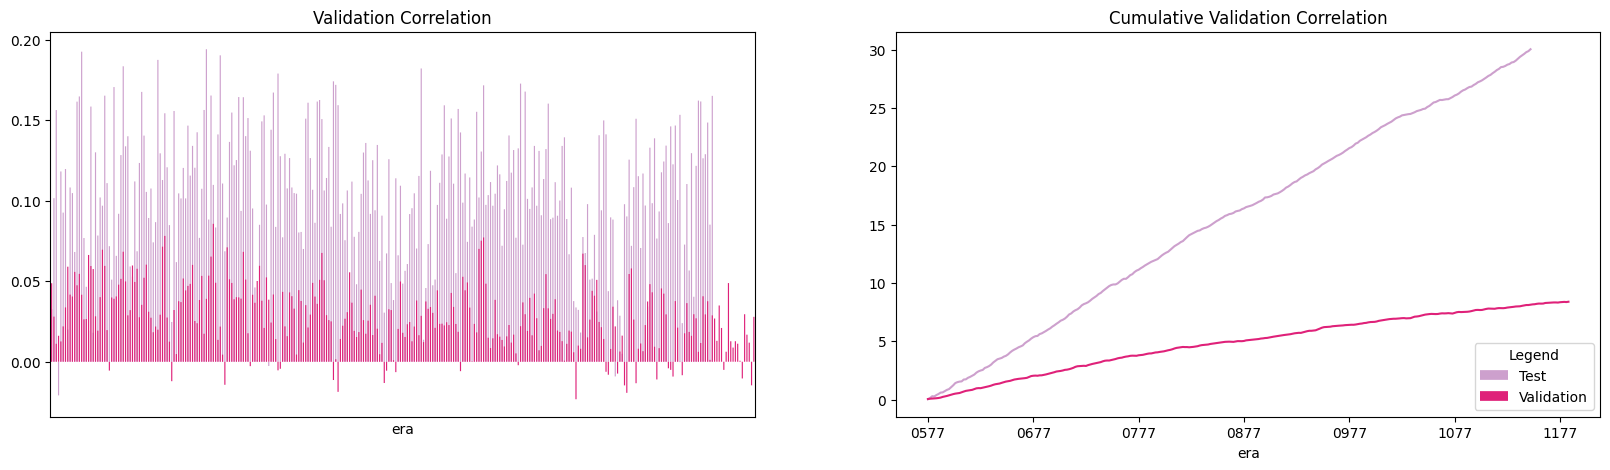

,xgb_test,xgb_val
mean,0.104696,0.027518
std,0.041399,0.020545
sharpe,2.528926,1.339402
max_drawdown,0.020892,0.033998


In [39]:
xgb.fit(train_df_m[feature_set_m], train_df_m["target"],
        eval_set=[(test_df_m[feature_set_m], test_df_m["target"])],
        verbose=100)

test_df_m["prediction"] = xgb.predict(test_df_m[feature_set_m])
per_era_corr_test = test_df_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_final = calc_metricas("xgb_test", per_era_corr_test, df_metrics_final)

validation_m["prediction"] = xgb.predict(validation_m[feature_set_m])
per_era_corr_val = validation_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_final = calc_metricas("xgb_val", per_era_corr_val, df_metrics_final)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_final

2.6.3.2 CBR

0:	learn: 0.2231334	test: 0.2231338	best: 0.2231338 (0)	total: 735ms	remaining: 12m 14s
100:	learn: 0.2230388	test: 0.2230675	best: 0.2230675 (100)	total: 1m 17s	remaining: 11m 28s
200:	learn: 0.2229673	test: 0.2230222	best: 0.2230222 (200)	total: 2m 34s	remaining: 10m 14s
300:	learn: 0.2229057	test: 0.2229868	best: 0.2229868 (300)	total: 3m 49s	remaining: 8m 52s
400:	learn: 0.2228483	test: 0.2229552	best: 0.2229552 (400)	total: 5m 5s	remaining: 7m 35s
500:	learn: 0.2227925	test: 0.2229253	best: 0.2229253 (500)	total: 6m 21s	remaining: 6m 19s
600:	learn: 0.2227397	test: 0.2228981	best: 0.2228981 (600)	total: 7m 32s	remaining: 5m
700:	learn: 0.2226895	test: 0.2228733	best: 0.2228733 (700)	total: 8m 41s	remaining: 3m 42s
800:	learn: 0.2226383	test: 0.2228488	best: 0.2228488 (800)	total: 9m 49s	remaining: 2m 26s
900:	learn: 0.2225900	test: 0.2228272	best: 0.2228272 (900)	total: 10m 56s	remaining: 1m 12s
999:	learn: 0.2225429	test: 0.2228069	best: 0.2228069 (999)	total: 12m 3s	remaining: 0

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2804742655.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2804742655.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation_m.groupby("era").apply(lambda x: practica_corr(x["predictio

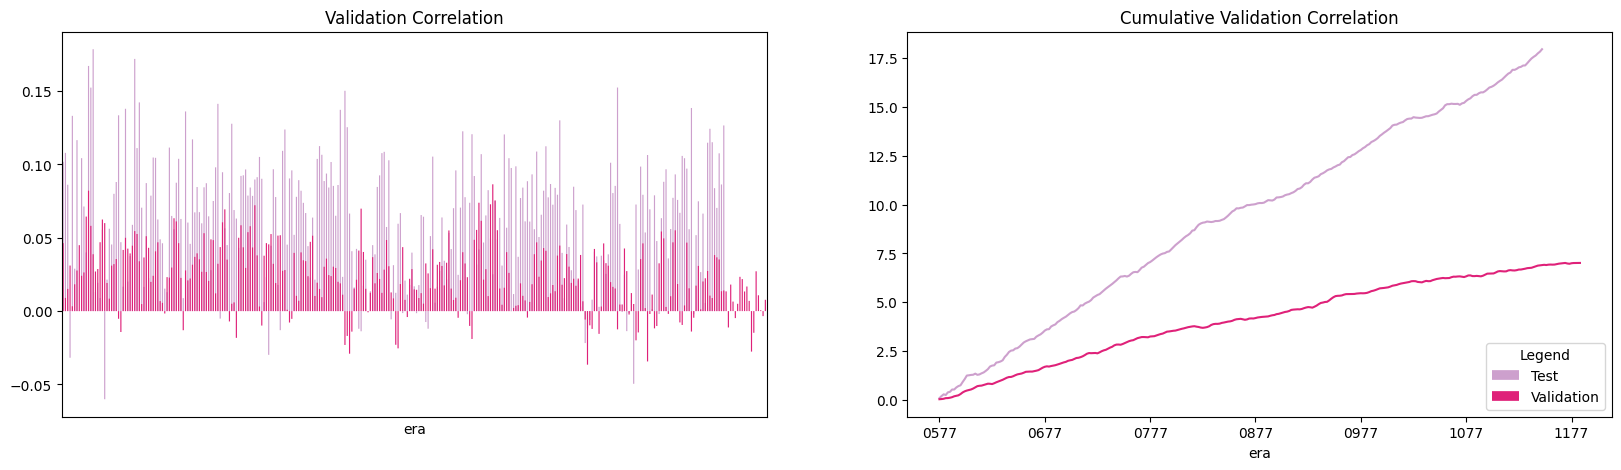

,xgb_test,xgb_val,cbr_test,cbr_val
mean,0.104696,0.027518,0.062535,0.023007
std,0.041399,0.020545,0.042109,0.022250
sharpe,2.528926,1.339402,1.485080,1.034003
max_drawdown,0.020892,0.033998,0.060109,0.083077


In [40]:
cbr.fit(train_df_m[feature_set_m], train_df_m["target"],
        eval_set=[(test_df_m[feature_set_m], test_df_m["target"])],
        use_best_model=True,
        early_stopping_rounds=50,
        verbose=100)

test_df_m["prediction"] = cbr.predict(test_df_m[feature_set_m])
per_era_corr_test = test_df_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_final = calc_metricas("cbr_test", per_era_corr_test, df_metrics_final)

validation_m["prediction"] = cbr.predict(validation_m[feature_set_m])
per_era_corr_val = validation_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_final = calc_metricas("cbr_val", per_era_corr_val, df_metrics_final)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_final

2.6.3.3 LGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.873898 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3525
[LightGBM] [Info] Number of data points in the train set: 1097774, number of used features: 705
[LightGBM] [Info] Start training from score 0.500026


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2071381588.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2071381588.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation_m.groupby("era").apply(lambda x: practica_corr(x["prediction

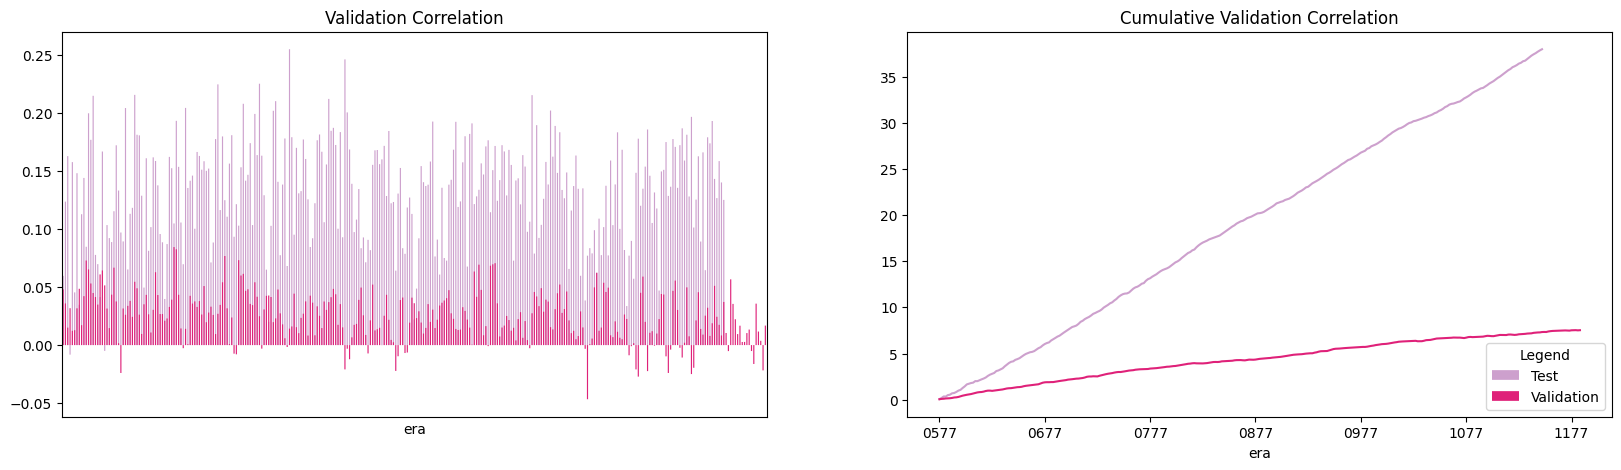

,xgb_test,xgb_val,cbr_test,cbr_val,lgbm_test,lgbm_val
mean,0.104696,0.027518,0.062535,0.023007,0.132259,0.024669
std,0.041399,0.020545,0.042109,0.022250,0.045503,0.021549
sharpe,2.528926,1.339402,1.485080,1.034003,2.906619,1.144794
max_drawdown,0.020892,0.033998,0.060109,0.083077,0.008224,0.056160


In [41]:
lgbm.fit(train_df_m[feature_set_m], train_df_m["target"],
        eval_set=[(test_df_m[feature_set_m], test_df_m["target"])])

test_df_m["prediction"] = lgbm.predict(test_df_m[feature_set_m])
per_era_corr_test = test_df_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_final = calc_metricas("lgbm_test", per_era_corr_test, df_metrics_final)

validation_m["prediction"] = lgbm.predict(validation_m[feature_set_m])
per_era_corr_val = validation_m.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_final = calc_metricas("lgbm_val", per_era_corr_val, df_metrics_final)

corr_plots(per_era_corr_test, per_era_corr_val)
df_metrics_final

2.6.4 Conclusiones  

Comparativas técnicas de cada modelo:  

|  | CBR  |  XGB  |  LGBM  |
|------|------|------|------|  
| Features categóricas   | Soporte nativo (Target Statistics)   | Permite algunas variables categóricas, pero no es tan robusto como CBR    |  Es menos robusto con features discretas |  
| Velocidad   | Moderada   | Usualmente muy rápido con datasets grandes   |  La más rápida de todas  |  
| Estrategia de crecimiento | Oblivious trees* (muy simétrico) | Level-wise (simétrico) | Leaf-wise (asimétrico) |  
| Prevención de overfitting  |  Ordered boosting* + simetría estricta  |  Gradient boosting* + regularización L1/L2 |  Gradient boosting + requiere regularización cuidadosa |  

>    
> *Oblivious trees (Árboles simétricos): En cada nivel del árbol, los splits se hacen por la misma feature. De esta manera, se gana en eficiencia y consistencia. En eficiencia ya que permite entrenamiento más rápido, porque de lo único que debe preocuparse el árbol es si decidir ir a izquierda o derecha. Y en consistencia ya que al mantener la misma estructura balanceada, asegura de que todas las ramas sean de la misma profundidad, por lo que puede ayudar a reducir el overfitting. El inconveniente es que genera menor expresividad, ya que no puede adaptar la complejidad del árbol a diferentes regiones.    
>  
> *Ordered Boosting (OB) VS Gradient Boosting (GB): En GB tradicional, a la hora de calcular los splits, se utiliza el dataset entero, cosa que puede producir target leakage (resultando en posible overfitting). En cambio en OB, se introduce el concepto de 'tiempo artificial', se basa en generar varias permutaciones aleatorias del dataset para crear distintas 'líneas temporales', entonces, por cada dato se utiliza únicamente su sus datos precedentes en esa línea temporal para hacer los cálculos, de esta manera siempre trabaja 'ciego' a los datos futuros, minimizando así el target leakage.  

Interpretación de los resultados por modelo y volumen de datos:  
| |CatBoost Regressor|XGB Regressor|LGBM Regressor|Conclusiones por datos|  
|-|-|------|------|-|   
|Feature set=small + eras ::4| Gracias al OB y Oblivious, consigue una estructura equilibrada para extraer el máximo valor sin caer en memorización, logrando un rendimiento comparable con las otras dos, y con mayor generalización | El algoritmo level-wise, aunque sistemático, realiza ajustes demasiado finos sobre patrones que podrían ser espurios | Mediante su estrategia leaf-wise, requiere muestras suficientes para estimar dichas ganancias de forma confiable. Con menor cantidad de datos, estas estimaciones se vuelven ruidosas y conducen a divisiones subóptimas. La discretización de features (0-4) agrava el problema al limitar los splits candidatos | XGB y CBR obtienen rendimientos muy similares, mientras que LGBM rinde más pobremente. Con datos limitados, la diferencia entre modelos se difumina. La ventaja de regularización de CBR es marginal, y la capacidad de XGB y LGBM de capturar patrones complejos no se aprovecha plenamente. También es muy posible que la sutil diferencia de rendimiento se deba a las distintas configuraciones de hiperparámetros, por lo que no se aprecie realmente la diferencia de los modelos en si |    
|Feature set=medium + eras ::2| Mejora el rendimiento de manera muy controlada, este modelo carece de flexibilidad para capturar patrones extremadamente complejos en espacios de alta dimensionalidad | Es más agresivo, evalúa metódicamente todas las divisiones posibles en cada nivel, descubriendo interacciones complejas entre features que CatBoost no puede capturar. El resultado es un rendimiento superior (Sharpe más alto, max_drawdown inferior), pero a coste de un overfitting superior a 1.1 a pesar de una regularización significativa (reg_lambda=30) | Al aumentar los datos se eliminan esas restricciones y puede construir árboles profundamente asimétricos, explorar muchos más splits potenciales y aumentando su capacidad de aprendizaje pero que llegan a memorizar patrones específicos, resultando en un overfitting extremadamente alto (>1.7) | En todos los modelos aumenta el overfitting, siendo el más pronunciado LGBM, seguido de XGB y el que menos CBR. Con mayor cantidad de datos, se refleja mejor la naturaleza de cada modelo: LGBM es extremadamente agresivo gracias al leaf-wise. CBR es muy conservador, por lo que tiene menos overfitting, pero su rendimiento también es el más pobre de las 3. Y XGB se encuentra en un punto intermedio de estas otras|   
|Conclusiones por modelo| CatBoost es ideal en entornos donde la consistencia importa más que el rendimiento | XGBoost puede estar identificando patrones genuinamente complejos, o simplemente memorizando ruido específico del periodo de entrenamiento. Si los datos de producción mantienen la misma estabilidad temporal de las relaciones subyacentes, entonces sí puede ser bueno el modelo | LGBM tiende a necesitar una regularización demasiado precisa para poder controlar su overfitting.  | |    



En resumen, XGB es muy bueno para datasets muy grandes, ya que puede capturar muchos patrones muy complejos y refinados, pero con un riesgo de overfitting muy alto. CBR en cambio, es muy consistente y robusto, limitando a su vez cierto potencial de aprendizaje a cambio de asegurarse de que en un entorno con datos nuevos pueda rendir similar al entrenamiento. LGBM no es el más adecuado para este tipo de datos, además de que su facilidad de overfittear hace que haya que regularizarlo mucho.

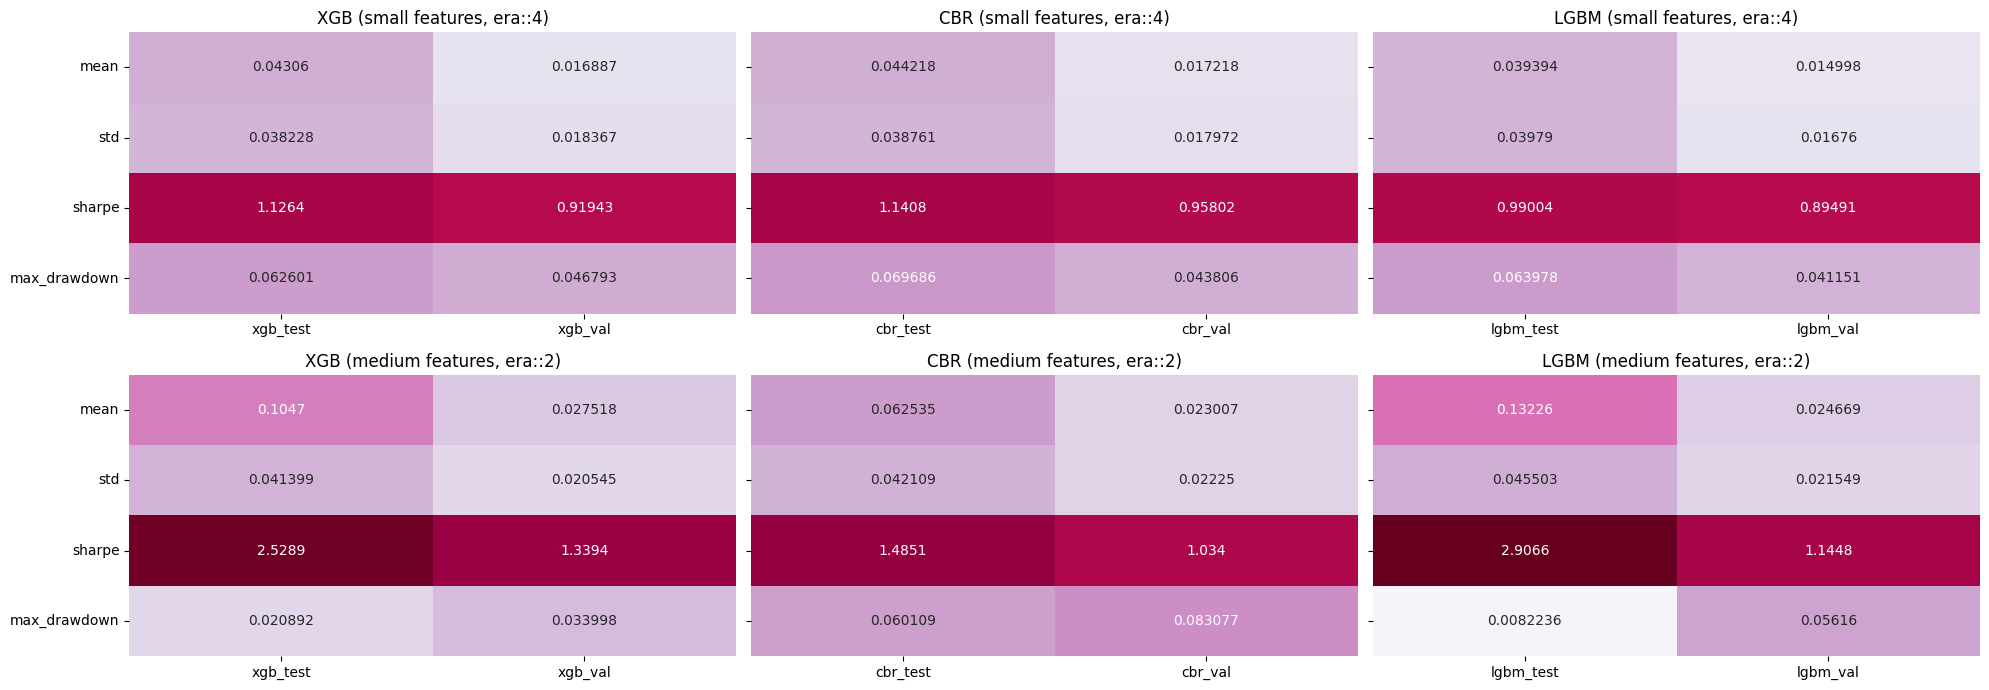

In [42]:
fig, axs = plt.subplots(2, 3, figsize=(20,7), sharey=True)

vmin = np.min([
    df_metrics_potential[["xgb_test", "xgb_val", "cbr_test", "cbr_val", "lgbm_test", "lgbm_val"]].values.min(),
    df_metrics_final[["xgb_test", "xgb_val", "cbr_test", "cbr_val", "lgbm_test", "lgbm_val"]].values.min()
])
vmax = np.max([
    df_metrics_potential[["xgb_test", "xgb_val", "cbr_test", "cbr_val", "lgbm_test", "lgbm_val"]].values.max(),
    df_metrics_final[["xgb_test", "xgb_val", "cbr_test", "cbr_val", "lgbm_test", "lgbm_val"]].values.max()
])

sns.heatmap(df_metrics_potential[["xgb_test", "xgb_val"]], annot=True, fmt=".5", vmin=vmin, vmax=vmax, cmap="PuRd", norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[0,0], cbar=False)
axs[0,0].set_title('XGB (small features, era::4)')
sns.heatmap(df_metrics_potential[["cbr_test", "cbr_val"]], annot=True, fmt=".5", vmin=vmin, vmax=vmax, cmap="PuRd", norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[0,1], cbar=False)
axs[0,1].set_title('CBR (small features, era::4)')
sns.heatmap(df_metrics_potential[["lgbm_test", "lgbm_val"]], annot=True, fmt=".5", vmin=vmin, vmax=vmax, cmap="PuRd", norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[0,2], cbar=False)
axs[0,2].set_title('LGBM (small features, era::4)')
sns.heatmap(df_metrics_final[["xgb_test", "xgb_val"]], annot=True, fmt=".5", vmin=vmin, vmax=vmax, cmap="PuRd", norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[1,0], cbar=False)
axs[1,0].set_title('XGB (medium features, era::2)')
sns.heatmap(df_metrics_final[["cbr_test", "cbr_val"]], annot=True, fmt=".5", vmin=vmin, vmax=vmax, cmap="PuRd", norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[1,1], cbar=False)
axs[1,1].set_title('CBR (medium features, era::2)')
sns.heatmap(df_metrics_final[["lgbm_test", "lgbm_val"]], annot=True, fmt=".5", vmin=vmin, vmax=vmax, cmap="PuRd", norm=mcolors.LogNorm(vmin=vmin, vmax=vmax), ax=axs[1,2], cbar=False)
axs[1,2].set_title('LGBM (medium features, era::2)')

plt.tight_layout()

#### 2.7 Overfitting

Overfitting es un problema en Machine Learning que ocurre cuando el modelo sobreajusta sus aprendizajes a los datos de entrenamiento, por lo que produce muy buenos resultados con ese set de datos, pero no generaliza bien con datos nuevos. Este problema se detecta claramente cuando el error en entrenamiento es muy bajo comparado con el error de validación. Los modelos entrenados en esta práctica, en especial LGBM Regressor, presentan un claro ejemplo de overfitting.    

Este problema se puede evitar de varias maneras:  
- Simplificación del modelo -> al hacer los modelos más simples (ajustando parámetros, limitando profundidad de árbol...) o aplicando técnicas de regularización (alpha, lambda, gamma), se limita su capacidad de ajuste excesivo y generaliza mejor.  
- Aumentar los datos -> Al tener más datos, ayuda a que el modelo aprenda patrones generales, y por ende, los outliers tengan menos peso. (Aunque se ha visto que con LGBM pasa al contrario, aunque la cuestión no es problema de cantidad de datos, sino que hay que aumentar la regularización acorde.)  
- Early stopping -> Asignar un set de validación para el modelo, para que a cada iteración compare los resultados obtenidos y detener el modelo cuando el rendimiento en validación empieza a empeorar.  
- Normalización y estandarización -> No reduce directamente el overfitting, pero hace que los datos sean más estables, y no de importancia a ciertas características por su magnitud en vez de relevancia (aunque es irrelevante en modelos basados en árboles, que son los que se usan finalmente en esta tarea).  
- Cross-validation -> Tampoco ayuda a reducir el overfitting, pero sí a detectarlo. Se entrena el conjunto de datos dividido en varios folds y se validan entre ellas, para obtener una guía de los mejores hiperparámetros que puedan reducir overfitting.  



### 3. VALIDATION

#### 3.1 F1 score VS Coeficiente de correlación de Pearson

Para explicar porqué se ha usado el coeficiente de correlación de Pearson y no F1 score, primero analicemos qué mide cada una:  
- F1 score: Mide el promedio armónico entre precision y recall. Se utiliza para modelos de clasificación.
- Coeficiente de correlación de Pearson: Mide la fuerza y dirección de la relación lineal entre las predicciones y los valores reales. Por lo que se utiliza en modelos de regresión. Cuando el valor de r es:  
    - +1 -> Indica correlación lineal perfecta, es decir, las predicciones se acercan mucho a los valores reales.
    - 0 -> No hay correlación.
    - -1 -> Correlación perfectamente negativa, las predicciones son contrarias a los valores reales, por lo que el modelo está prediciendo al revés.  

Entonces la clave es el tipo de problema al que nos enfrentamos, en este caso, y normalmente en entornos financieros o predicción de riesgo, no se busca predecir un valor exacto ni la clase correcta, sino ordenar las observaciones, es decir, el valor absoluto de la predicción no importa tanto como su dirección y consistencia. Y para ello, se utilizan modelos regresivos, para predecir un valor entre 0 y 1.  

Y el coeficiente de correlación de Pearson mide exactamente eso, qué tan alineados están las predicciones del target, una correlación alta implicaría que el modelo tiene buen poder predictivo.  

Tomando de ejemplo el último resultado corr (LGBM con dataset mediano y features ::2 sobre los datos de validación):  
- Validation Correlation: En el gráfico de la izquierda, se observa la distribución de la correlación de Pearson entre las predicciones y el target, a través de las distintas eras. Cuando el valor es positivo, quiere decir que las predicciones de esa era en específico en general han sido buenas. Entonces cuanto más alto sea el valor de la correlación, hasta un máximo de 1, más exacta fue la relación entre preddiciones y real. Y lo mismo al contrario, cuanto más negativo, hasta un máximo de -1, más se alejaron las predicciones del valor real durante esa era en específico.  

El rango de estos resultados se encuentra entre el -0.04 y 0.08, lo que indica un rendimiento estable pero con cierta volatilidad. Además, la mayoría de eras son positivas, lo cual indica un poder predictivo consistente. No son resultados brillantes, pero en el ámbito de la predicción del mercado es aceptable, ya que los datos suelen ser muy ruidosos.    

- Cumulative Validation Correlation: En el gráfico de la derecha, vemos la suma de las correlaciones a través de las eras. Sirve para visualizar la consistencia temporal del modelo. Es decir va sumando los valores de correlación de las distintas eras, y restando cuando es negativo. Por lo que la forma ideal sería una recta o curva suave diagonal ascendente. Si se encuentran picos de caída, quiere decir que en alguna era ha predicho muy mal.  

En esta curva podemos ver que el modelo generaliza decentemente a lo largo del tiempo, y es bastante estable, sin mucha varianza entre eras.

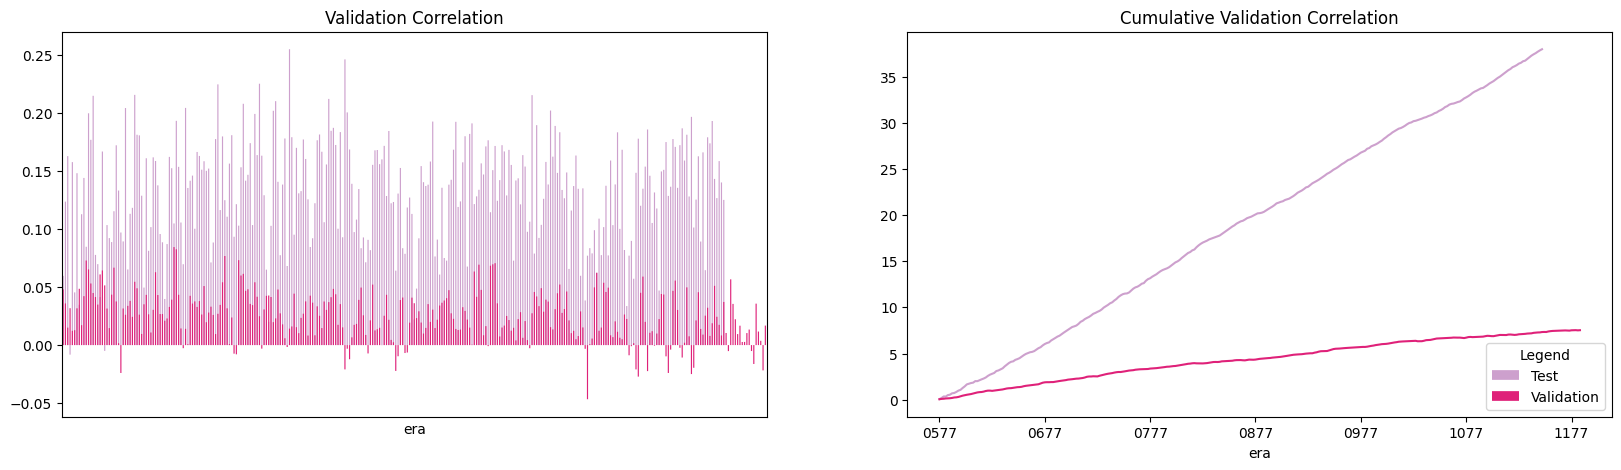

In [43]:
corr_plots(per_era_corr_test, per_era_corr_val)

#### 3.2 Métricas de rendimiento  

Analicemos las métricas de rendimiento que se han usado en esta práctica, tomando de ejemplo las métricas de los modelos finales (XGB, CBR y LGBM con datos medianos y eras ::2). Pero para ello, primero expliquemos qué indica cada cosa:  

|  | Definición | Ideal |  
|--|------------|-------|  
|Mean|La media de correlaciones en todas las eras. |Cuanto más alto mejor, quiere decir que hay más fuerza promedio.|  
|Std (Desviación estándar)| Mide la volatilidad de las correlaciones entre las eras. |Cuanto más bajo mejor, indica que el modelo es más estable.|  
|Sharpe|Medida de rendimiento ajustado al riesgo, es el resultado de la media entre la desviación estándar. | Cuanto más alto mejor, indica que tiene buena señal constante y bajo riesgo. |  
|Max drawdown |Mide la peor pérdida temporal acumulada. Calcula cuánto cae el rendimiento desde un pico hasta el siguiente valle más bajo, es decir, cuánto empeora la correlación acumulada antes de recuperarse. | Cuanto menor mejor, indica que es más estable. |  

De los siguientes resultados, podemos ver que LGBM en test obtiene los resultados más sólidos (sin tener en cuenta el overfitting). Consigue la mayor media de todas, la desviación estándar no es la más baja, pero sí lo suficiente como para dar un buen sharpe. Su max drawdown también es el más bajo de todos. Todo esto se resume en que tiene bastante fuerza de predicción positiva (mean=0.13), y aunque tiene cierta volatilidad (std=0.04), consigue recuperarse de sus caídas rápidamente (max_drawdown=0.008).  

In [44]:
df_metrics_final

,xgb_test,xgb_val,cbr_test,cbr_val,lgbm_test,lgbm_val
mean,0.104696,0.027518,0.062535,0.023007,0.132259,0.024669
std,0.041399,0.020545,0.042109,0.022250,0.045503,0.021549
sharpe,2.528926,1.339402,1.485080,1.034003,2.906619,1.144794
max_drawdown,0.020892,0.033998,0.060109,0.083077,0.008224,0.056160


### 4. IMPROVEMENT & INVESTIGATION

In [45]:
df_metrics_investigation=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

In [46]:
# función customizada de mostrar las gráficas
def custom_plots(per_era_corr_test, per_era_corr_val, color):
    per_era_corr_test.plot(kind="bar", title="Test Correlation", xticks=[], color=color, snap=False, ax=axs[0, 0])
    per_era_corr_test.cumsum().plot(kind="line", title="Cumulative Test Correlation", color=color, ax=axs[0, 1])

    per_era_corr_val.plot(kind="bar", title="Validation Correlation", xticks=[], color=color, snap=False, ax=axs[1, 0])
    per_era_corr_val.cumsum().plot(kind="line", title="Cumulative Validation Correlation", color=color, ax=axs[1, 1])
    

#### 4.1 Feature Neutralization  

Feature neutralization tiene como objetivo eliminar la parte de la predicción que está linealmente explicada por las features. Esto lo que hace es aumentar la generalización a eras futuras, bajando el era specificity de las predicciones. Aunque como se vió en el análisis de los datos, este conjunto de datos ya tiene un era specificity muy bajo, por lo que no se espera que feature neutralization vaya a hacer ningún cambio impresionante.

4.1.1 Entender cómo funciona neutralize de Numerai  

Para este ejemplo se utilizará un sample del conjunto de validación con las últimas predicciones (LGBM feature set mediano, eras ::2), para no trabajar sobre todos los datos.  

Se nuetraliza la predicción en base a distintas proporciones ([0.25, 0.5, 0.75, 1.0]). Se puede comprobar que cuanto más neutralizada estén las features, el valor de la predicción disminuye, hasta llegar a 0 e incluso negativos. En producción, normalmente nunca se usaría una neutralización absoluta (1.0) ya que se eliminaría toda la dependencia de las features.

In [47]:
sample = validation.sample(10000, random_state=42).reset_index(drop=True)
proportions = [0.25, 0.5, 0.75, 1.0]
for proportion in proportions:
    neutralized = sample.groupby("era", group_keys=True).apply(
        lambda d: neutralize(
          d[["prediction"]],
          d[feature_set],
          proportion=proportion
        )
    ).reset_index()
    sample[f"neutralized_{proportion*100:.0f}"] = neutralized["prediction"]

# Align the neutralized predictions with the validation data
prediction_cols = ["prediction"] + [f for f in sample.columns if "neutralized" in f]
sample[["era", "target"] + prediction_cols]

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1123813414.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  neutralized = sample.groupby("era", group_keys=True).apply(
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1123813414.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  neutralized = sample.groupby("era", group_keys=True).apply(
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\1123813414.py:4: FutureWarn

,era,target,prediction,neutralized_25,neutralized_50,neutralized_75,neutralized_100
0,0939,1.00,0.475489,0.391646,0.257761,0.123876,-0.010008
1,0807,1.00,0.519312,0.373996,0.256792,0.139588,0.022384
2,0627,0.50,0.465379,0.368656,0.244182,0.119707,-0.004767
3,0875,0.50,0.492858,0.376983,0.247964,0.118945,-0.010075
4,0703,0.75,0.552035,0.372163,0.250466,0.128769,0.007072
...,...,...,...,...,...,...,...
9995,0947,0.50,0.475400,0.375980,0.252093,0.128206,0.004319
9996,0939,0.50,0.561198,0.352509,0.235135,0.117761,0.000387
9997,1111,0.25,0.518819,0.339849,0.218411,0.096972,-0.024466
9998,0903,1.00,0.498738,0.363012,0.243939,0.124866,0.005793


4.1.2 Neutralización a distintas proporciones

Uno de los beneficios de feature neutralization es la posible reducción del overfitting en caso de que ciertas features estén altamente correlacionadas con target únicamente durante eras específicas. Consiguiendo así un modelo más robusto. Por ello, para este ejemplo usaremos el modelo más propenso a overfittear (LGBM).  

Se ha probado a neutralizar las top 8 features con más era specificity (obtenidas durante el análisis de los datos) a distintas proporcionalidades. 7 de las 8 features tienen un era specificity de 0.0001, por lo que se ha decidido empezar por ahí, hasta llegar a una neutralización absoluta de estas features, es decir, una proporción de 1. 

Como era de esperarse, con un era specificity tan bajo en general, el impacto de feature neutralization hasta una proporción de 0.5 es prácticamente despreciable.  

Con una neutralización absoluta de 1 sí empieza a afectar, pero lógicamente de manera desfavorable. Los resultados obtenidos se vuelven un poco más inestables que el modelo original. Esto se puede comprobar ya que max drawdown tanto en test como en validación, son considerablemente mayores que la predicción original. Otro dato importante es la diferencia de sharpe, baja tanto en test como en validación. Esto confirma que al neutralizar todo aumenta la aletoriedad.  

En conclusión, la neutralización de features no aporta beneficios significativos en este dataset. Por el contrario, introduce un coste computacional adicional y puede incluso degradar el rendimiento general del modelo.

In [48]:
df_metrics_neutralize=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

In [50]:
lgbm = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(train_df[feature_set], train_df["target"],
        eval_set=(test_df[feature_set], test_df["target"]))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 550547, number of used features: 42
[LightGBM] [Info] Start training from score 0.500008


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3456128505.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3456128505.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

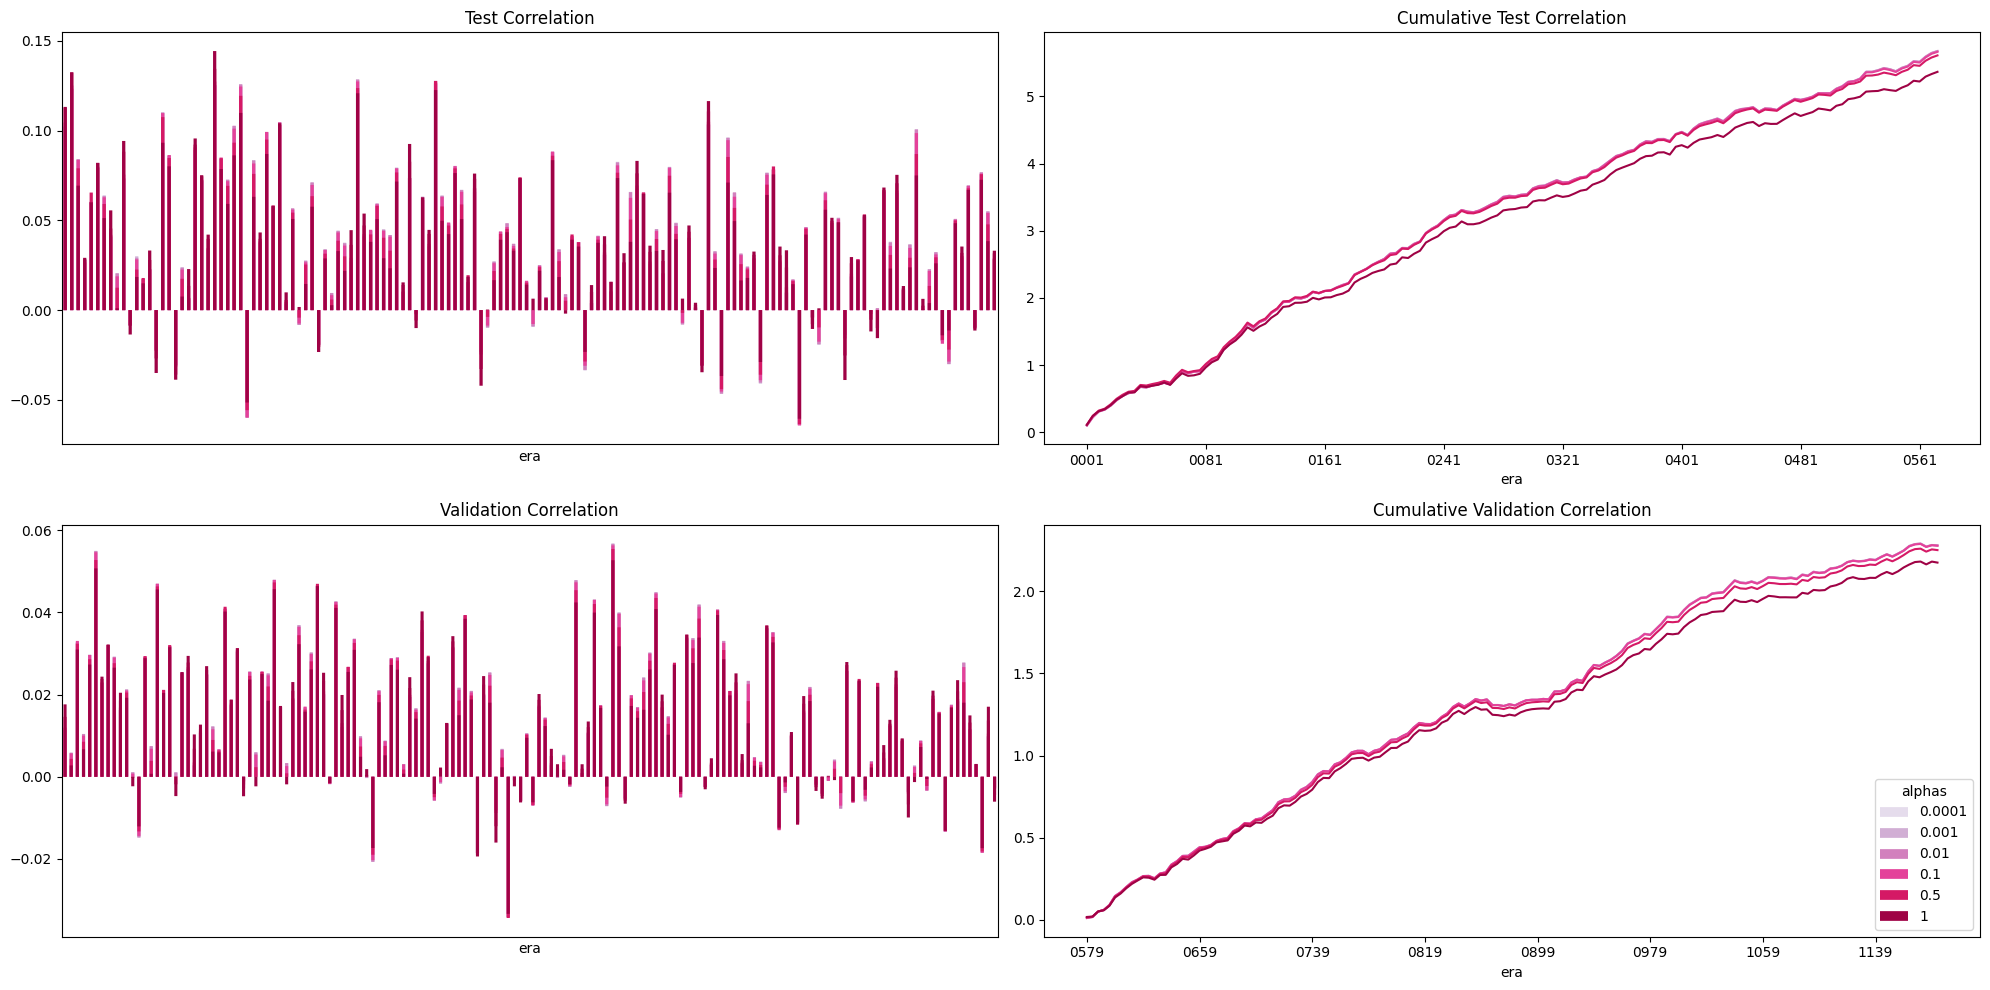

,neut_0.0001_test,neut_0.0001_val,neut_0.001_test,neut_0.001_val,neut_0.01_test,neut_0.01_val,neut_0.1_test,neut_0.1_val,neut_0.5_test,neut_0.5_val,neut_1_test,neut_1_val
mean,0.039395,0.014999,0.039386,0.014998,0.039394,0.014997,0.039312,0.014985,0.038944,0.014810,0.037248,0.014310
std,0.039793,0.016760,0.039798,0.016760,0.039786,0.016758,0.039721,0.016735,0.039413,0.016553,0.038842,0.016259
sharpe,0.990010,0.894930,0.989655,0.894887,0.990151,0.894963,0.989684,0.895455,0.988101,0.894742,0.958968,0.880175
max_drawdown,0.063968,0.041148,0.063938,0.041114,0.064038,0.041294,0.064285,0.042442,0.063451,0.048593,0.060518,0.055642


In [51]:
proportions = [0.0001, 0.001, 0.01, 0.1, 0.5, 1]
fig, axs = plt.subplots(2,2, figsize=(20, 10))
colors = sns.color_palette("PuRd", len(proportions))

def predict_neutral(proportion, live_features: pd.DataFrame, _live_benchmark_models: pd.DataFrame = None) -> pd.DataFrame:
    # make predictions using all features
    predictions = pd.DataFrame(
        lgbm.predict(live_features[feature_set]),
        index=live_features.index,
        columns=["prediction"]
    )
    # neutralize predictions to a subset of features
    neutralized = neutralize(predictions, live_features[top_features], proportion=proportion)
    return neutralized.rank(pct=True)

for i, proportion in enumerate(proportions):

    test_df["prediction"] = predict_neutral(proportion, test_df)
    per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_neutralize = calc_metricas(f'neut_{proportion}_test', per_era_corr_test, df_metrics_neutralize)

    validation["prediction"] = predict_neutral(proportion, validation)
    per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_neutralize = calc_metricas(f"neut_{proportion}_val", per_era_corr_val, df_metrics_neutralize)

    custom_plots(per_era_corr_test, per_era_corr_val, colors[i])

legend = [plt.Line2D([0], [0], linestyle="-", solid_capstyle='butt', color=colors[i % len(colors)], lw=7) for i in range(len(proportions))]
axs[1, 1].legend(legend, proportions, title="alphas", loc='lower right')

plt.tight_layout()
plt.show()
df_metrics_neutralize

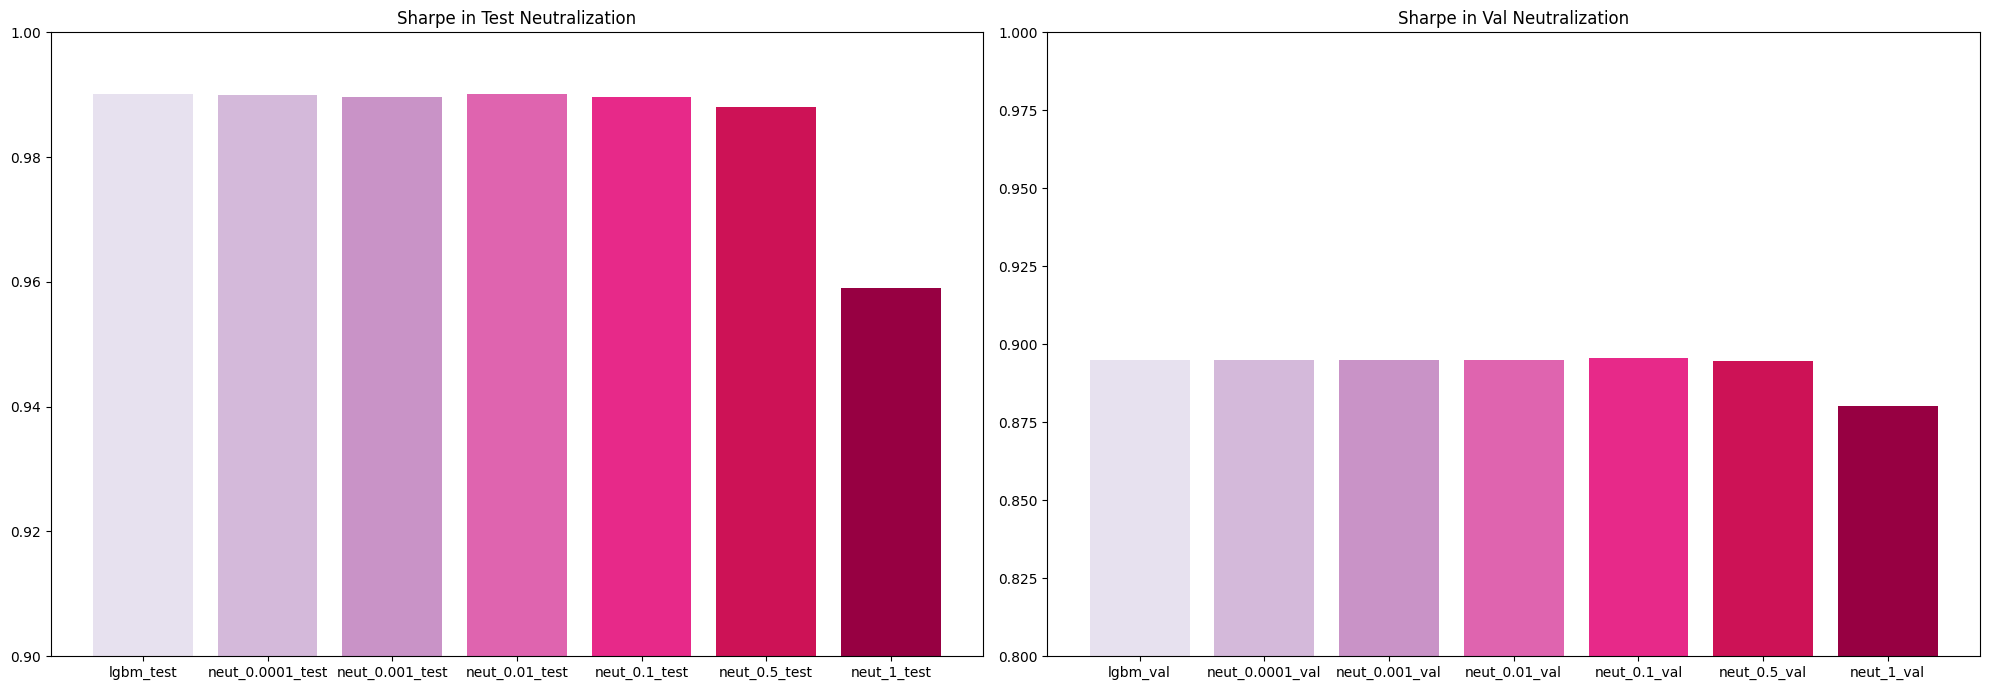

In [52]:
neutralize_test = pd.concat(
    [df_metrics_potential[["lgbm_test"]],
    df_metrics_neutralize[[i for i in df_metrics_neutralize.columns if i.endswith("_test")]]],
    axis=1)
neutralizee_val = pd.concat(
    [df_metrics_potential[["lgbm_val"]],
    df_metrics_neutralize[[i for i in df_metrics_neutralize.columns if i.endswith("_val")]]],
    axis=1)

fig, axs = plt.subplots(1, 2, figsize=(20,7))
axs[0].bar(x=neutralize_test.columns, height=neutralize_test.loc["sharpe"], color=sns.color_palette("PuRd", len(proportions) + 1))
axs[1].bar(x=neutralizee_val.columns, height=neutralizee_val.loc["sharpe"], color=sns.color_palette("PuRd", len(proportions) + 1))

axs[0].set_ylim(0.9, 1)
axs[1].set_ylim(0.8, 1)
axs[0].set_title('Sharpe in Test Neutralization')
axs[1].set_title('Sharpe in Val Neutralization')

plt.tight_layout()

#### 4.2 Ridge Regression  

Ridge Regression es un tipo de Linear Regresion, con la diferencia de que ésta le añade una penalización a los coeficientes para prevenir overfitting. El hiperparámetro α (lambda, λ) controla la fuerza de regularización, es decir, cuánto se penalizan los coeficientes grandes. Además, al intentar minimizar los coeficientes, permite obtener una menor varianza, lo cual lo hace más estable ante variables nuevas. Hay que tener en cuenta que esta reducción de varianza viene a coste de un poco más de sesgo.  

En resumen, la diferencia principal entre LR y  RR, es que LR intenta ajustarse a los datos lo máximo posible, mientras que RR, aunque también se ajusta lo máximo posible, lo hace castigando a los mayores pesos de manera que tenga una forma más suave y estable.  

4.2.1 Pruebas con distintas alphas  

Se muestra las métricas en ambas gráficas de correlación sobre el modelo de RR (con features small y eras ::4) con valores de alpha que van entre 0.001 - 1000. Se puede observar que la diferencia en estos casos es tan mínima que es despreciable. Es to puede explicar por varios puntos interesantes:  
- Los datos no tienen multicolinealidad: Ya se pudo comprobar en las matrices de correlación, que las features de este dataset no están muy correlacionadas entre sí, por lo que la penalización de RR no puede cambiar demasiado.  
- La escala de las features: Como los datos ya están estandarizados a la misma escala, el coeficiente de penalización es prácticamente 0 con todas las alphas ( se puede comprobar en la leyenda, tienendo un mismo valor de 0.00650 con alphas pequeños y medianos (desde 0.001 hasta 100), y luego desciende pero no mucho en un alpha de 10000, con un coeficiente de 0.00639).  


In [53]:
df_metrics_ridge=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3836889213.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3836889213.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

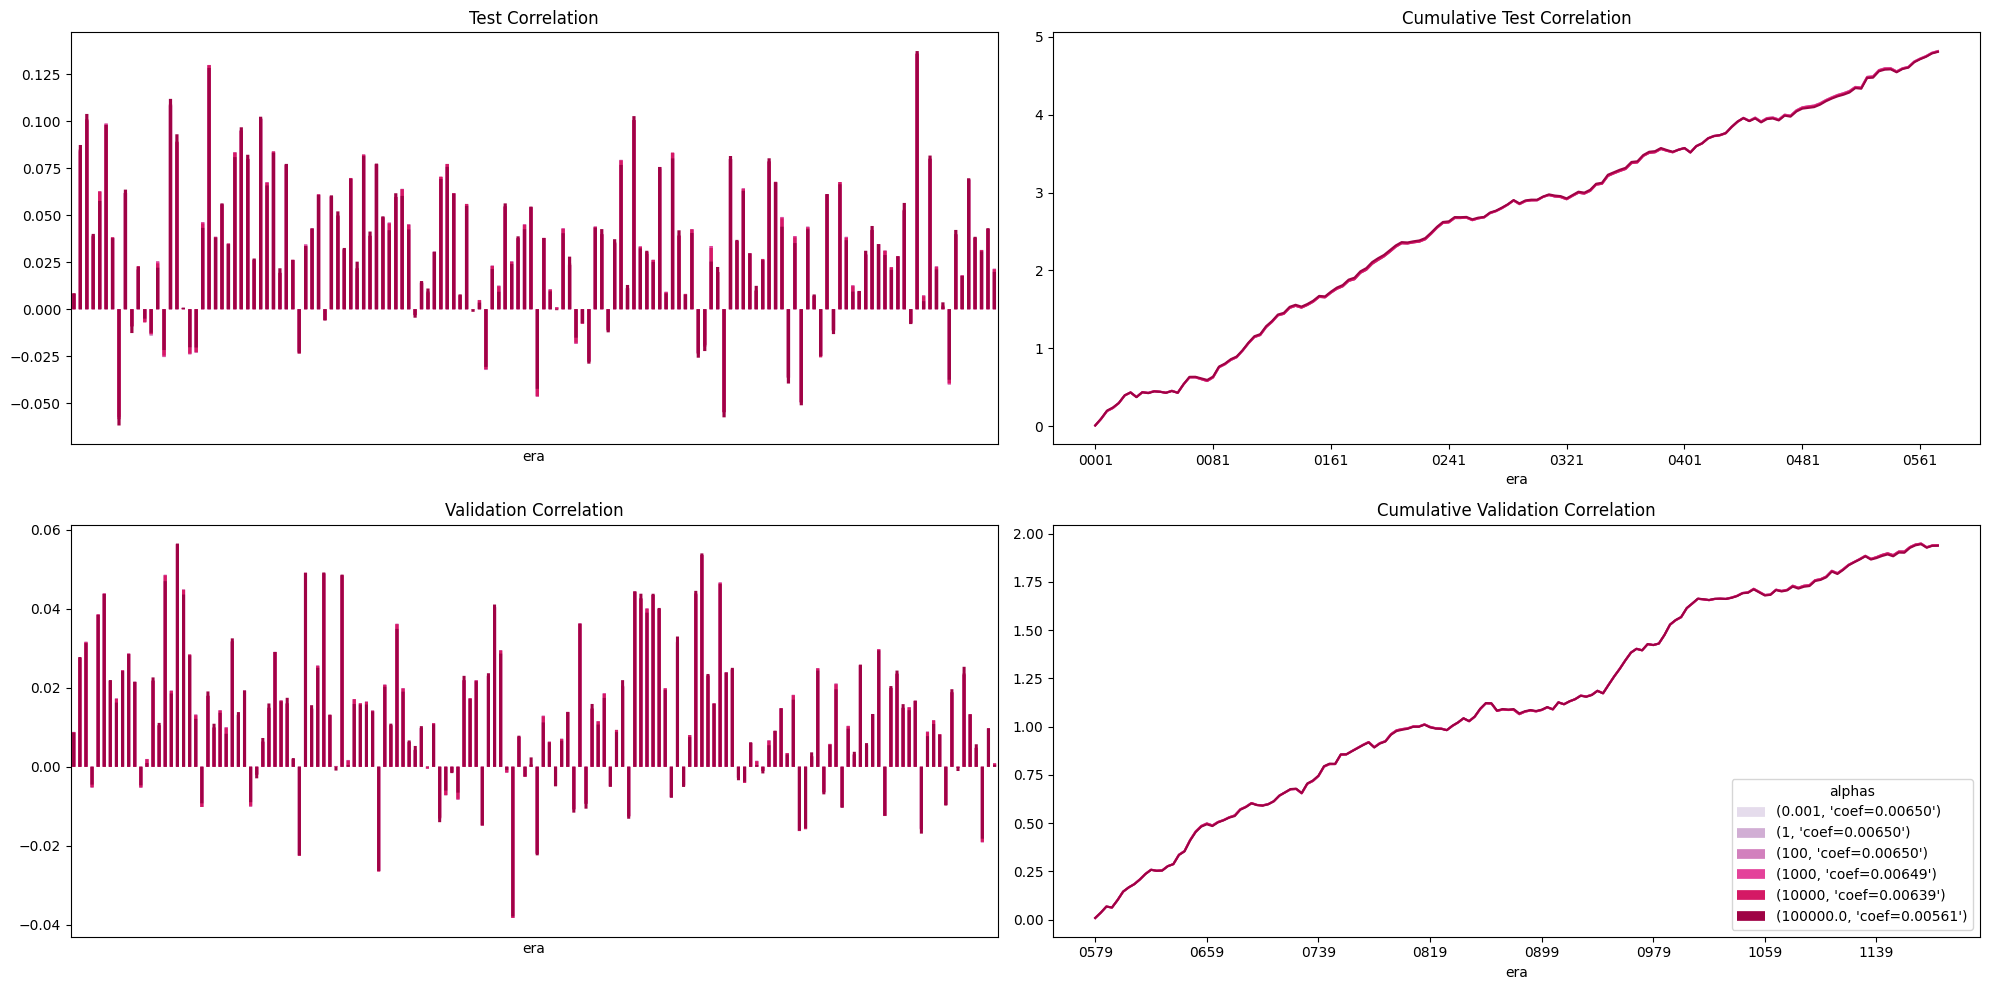

,ridge_0.001_test,ridge_0.001_val,ridge_1_test,ridge_1_val,ridge_100_test,ridge_100_val,ridge_1000_test,ridge_1000_val,ridge_10000_test,ridge_10000_val,ridge_100000.0_test,ridge_100000.0_val
mean,0.033442,0.012764,0.033442,0.012764,0.033442,0.012765,0.033451,0.012764,0.033408,0.012762,0.033376,0.012746
std,0.037633,0.017708,0.037632,0.017708,0.037634,0.017708,0.037634,0.017712,0.037653,0.017716,0.037889,0.017735
sharpe,0.888630,0.720825,0.888658,0.720820,0.888624,0.720818,0.888850,0.720637,0.887272,0.720342,0.880877,0.718666
max_drawdown,0.057322,0.056302,0.057304,0.056295,0.057312,0.056292,0.057309,0.056291,0.058579,0.056070,0.061934,0.053350


In [54]:
alphas = [0.001, 1, 100, 1000, 10000, 1e5]
fig, axs = plt.subplots(2,2, figsize=(20, 10))
coefs = []
colors = sns.color_palette("PuRd", len(alphas))

for i, alpha in enumerate(alphas):
    ridge = Ridge(
        alpha=alpha, 
        solver='sag',
        random_state=42
        )
    ridge.fit(train_df[feature_set], train_df["target"])

    test_df["prediction"] = ridge.predict(test_df[feature_set])
    per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_ridge = calc_metricas(f'ridge_{alpha}_test', per_era_corr_test, df_metrics_ridge)

    validation["prediction"] = ridge.predict(validation[feature_set])
    per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_ridge = calc_metricas(f'ridge_{alpha}_val', per_era_corr_val, df_metrics_ridge)

    custom_plots(per_era_corr_test, per_era_corr_val, colors[i])
    coefs.append(f'coef={np.linalg.norm(ridge.coef_):.5f}')

legend = [plt.Line2D([0], [0], linestyle="-", solid_capstyle='butt', color=colors[i % len(colors)], lw=7) for i in range(len(alphas))]
axs[1, 1].legend(legend, zip(alphas, coefs), title="alphas", loc='lower right')

plt.tight_layout()
plt.show()
df_metrics_ridge

4.2.2 Ridge Regression estandarizado  

A pesar de que las escalas de las features ya están discretizadas, se aplica estandarización a los datos para comprobar su rendimiento, ya que RR generalmente se beneficia de estandarización.  

Los resultados obtenidos no difieren en lo absoluto, o son mínimas a RR sin estandarización en este caso. 

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\4134542523.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\4134542523.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

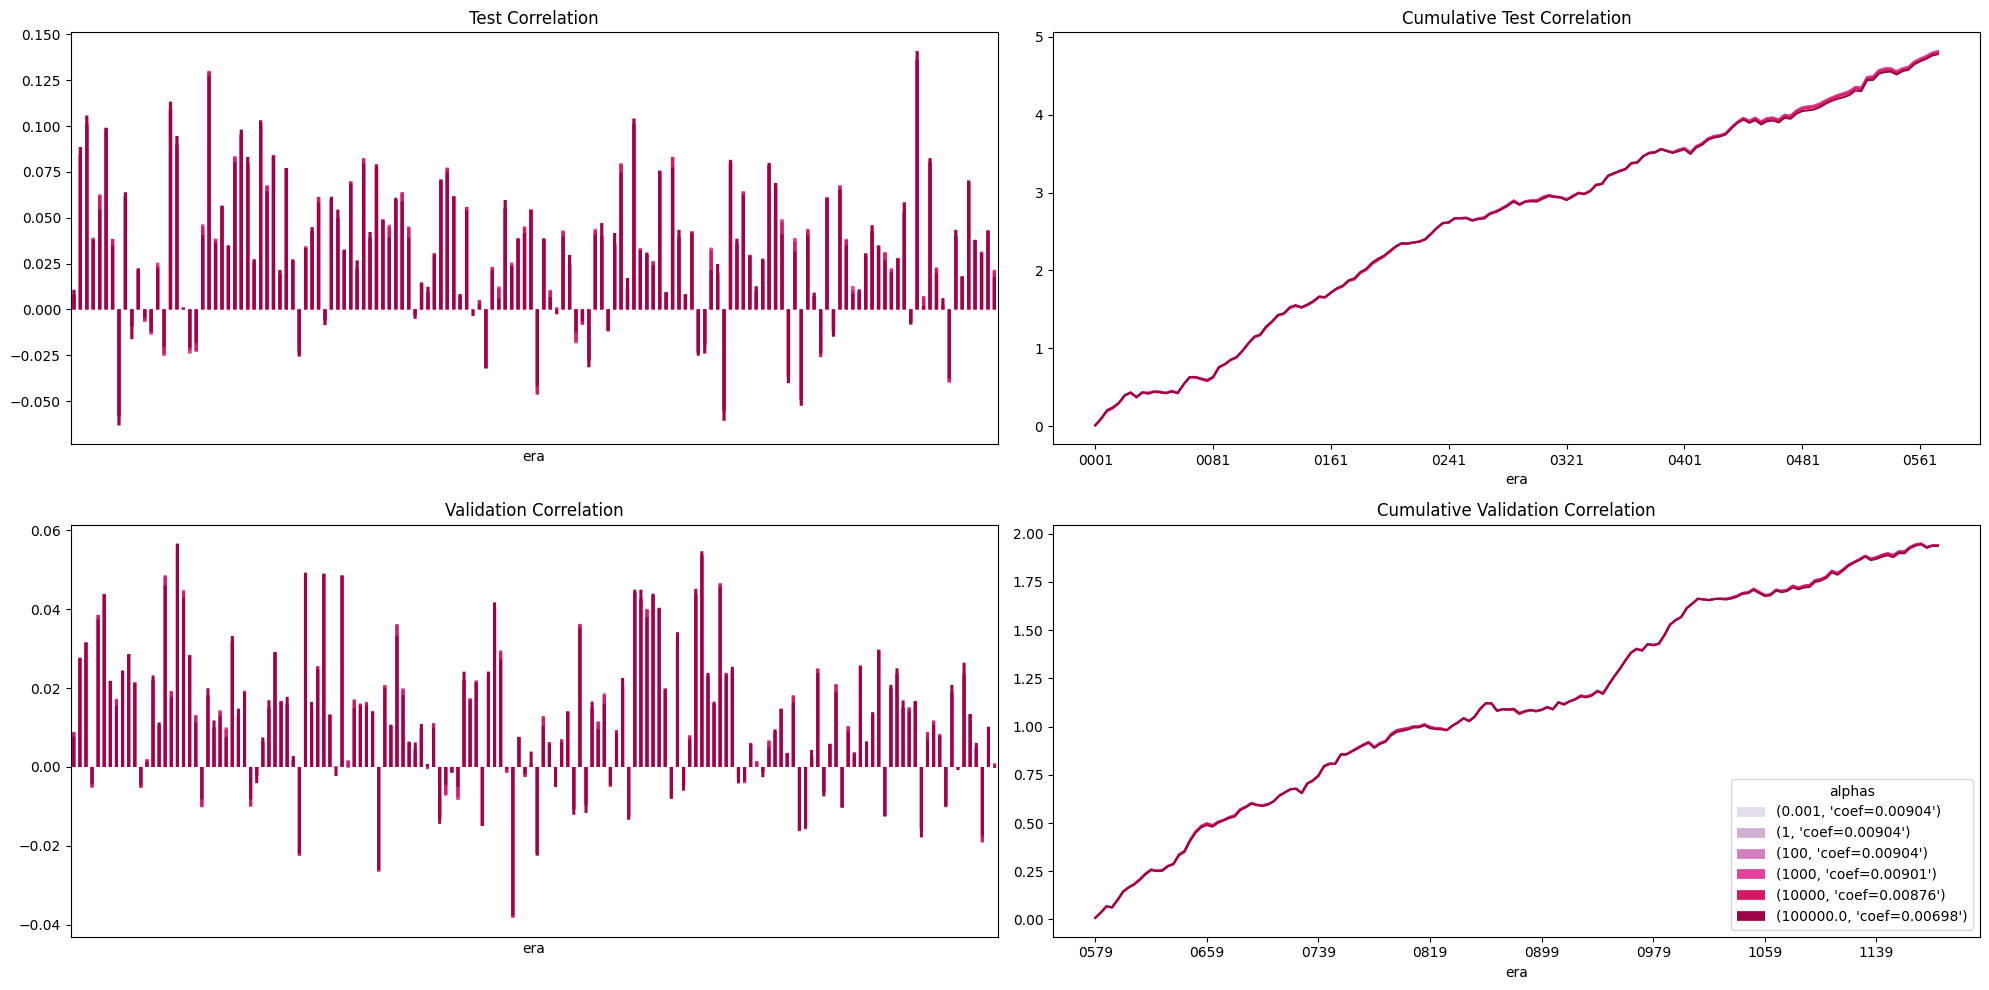

,ridge_0.001_test,ridge_0.001_val,ridge_1_test,ridge_1_val,ridge_100_test,ridge_100_val,ridge_1000_test,ridge_1000_val,ridge_10000_test,ridge_10000_val,ridge_100000.0_test,ridge_100000.0_val
mean,0.033444,0.012764,0.033439,0.012764,0.033441,0.012764,0.033459,0.012765,0.033325,0.012765,0.033177,0.012742
std,0.037630,0.017708,0.037634,0.017708,0.037631,0.017709,0.037636,0.017712,0.037642,0.017715,0.038216,0.017741
sharpe,0.888747,0.720834,0.888539,0.720801,0.888657,0.720768,0.889022,0.720703,0.885315,0.720585,0.868146,0.718184
max_drawdown,0.057327,0.056274,0.057306,0.056313,0.057309,0.056276,0.057591,0.056307,0.058911,0.055831,0.064043,0.050979


In [55]:
alphas = [0.001, 1, 100, 1000, 10000, 1e5]
fig, axs = plt.subplots(2,2, figsize=(20, 10))
coefs = []
colors = sns.color_palette("PuRd", len(alphas))
X_train, X_test, X_val = standarize(train_df[feature_set], test_df[feature_set], validation[feature_set])

for i, alpha in enumerate(alphas):
    ridge = Ridge(
        alpha=alpha, 
        solver='sag',
        random_state=42
        )
    ridge.fit(X_train, train_df["target"])

    test_df["prediction"] = ridge.predict(X_test)
    per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_ridge = calc_metricas(f'ridge_{alpha}_test', per_era_corr_test, df_metrics_ridge)

    validation["prediction"] = ridge.predict(X_val)
    per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_ridge = calc_metricas(f'ridge_{alpha}_val', per_era_corr_val, df_metrics_ridge)

    custom_plots(per_era_corr_test, per_era_corr_val, colors[i])
    coefs.append(f'coef={np.linalg.norm(ridge.coef_):.5f}')

legend = [plt.Line2D([0], [0], linestyle="-", solid_capstyle='butt', color=colors[i % len(colors)], lw=7) for i in range(len(alphas))]
axs[1, 1].legend(legend, zip(alphas, coefs), title="alphas", loc='lower right')

plt.tight_layout()
plt.show()
df_metrics_ridge

4.2.3 LR VS RR  

A continuación, se muestra una comparativa entre LR y RR para distintos valores de alpha, tanto en test como en validation. Podemos observar distintas cosas:  
- Un alpha bajo en RR, la diferencia obenida respecto a un alpha 0, es decir el modelo base de LR, es despreciable. Eso es porque la penalización es tán débil que se comporta como LR normal.  
- Cuando ridge es más alto, sharpe empieza a decaer tanto en test como en val, con una diferencia más pronunciada en test que en val. Eso se explica porque al incrementar alpha, la regularización se vuelve tan fuerte que el coeficiente se acerca demasiado a 0, perdiendo capacidad de ajuste y llegando a haber underfitting.  
- El comportamiento general en test y val es similar en todos los casos, test obtiene mayor sharpe y generaliza un poco peor en val, pero la diferencia es muy poca por lo que tampoco hay indicios de overfitting.  

En conclusión, RR se mantiene estable, su rendimiento varía muy poco a través de los distintos alphas, por que se refuerza el hecho de que no hay multicolinealidad fuerte ni coeficientes muy inflados. Por lo que este dataset no precisa de regularización extra que aporta RR, sino que con LR básico ya funciona.

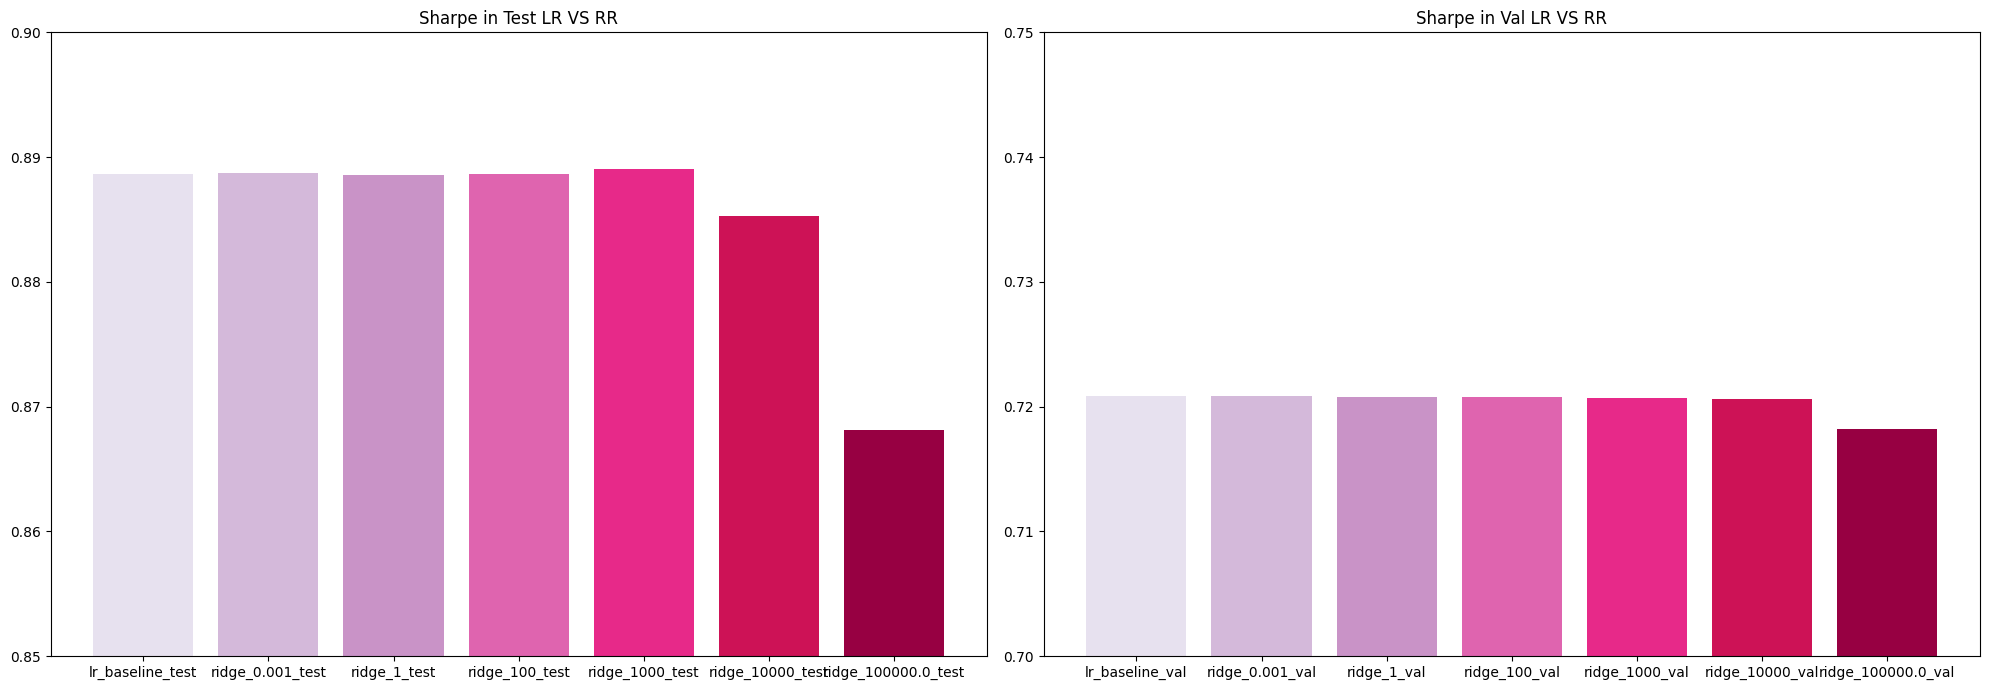

In [56]:
ridge_test = pd.concat(
    [df_metrics_lr[["lr_baseline_test"]],
    df_metrics_ridge[[i for i in df_metrics_ridge.columns if i.endswith("_test")]]],
    axis=1)
ridge_val = pd.concat(
    [df_metrics_lr[["lr_baseline_val"]],
    df_metrics_ridge[[i for i in df_metrics_ridge.columns if i.endswith("_val")]]],
    axis=1)

fig, axs = plt.subplots(1, 2, figsize=(20,7))
axs[0].bar(x=ridge_test.columns, height=ridge_test.loc["sharpe"], color=sns.color_palette("PuRd", len(alphas) + 1))
axs[1].bar(x=ridge_val.columns, height=ridge_val.loc["sharpe"], color=sns.color_palette("PuRd", len(alphas) + 1))

axs[0].set_ylim(0.85, 0.9)
axs[1].set_ylim(0.7, 0.75)
axs[0].set_title('Sharpe in Test LR VS RR')
axs[1].set_title('Sharpe in Val LR VS RR')

plt.tight_layout()

#### 4.3 Lasso 

Lasso es otro tipo de Linear Regresion regularizado, en el que suma los valores absolutos de los coeficientes y se agrega al error cuadrático medio dentro de la función de costo para ser minimizada.

La principal diferencia entre RR y Lasso es que RR suma los cuadrados de los coeficientes, por lo que consigue reducir coeficientes pero sin llegar a 0 nunca. Lasso en cambio suma los valores absolutos de los coeficientes, por lo que si se escoge un alpha grande, puede llevarlos a 0 y eliminando de forma efectiva esas variables del modelo.

4.3.1 Pruebas con distintas alphas  
  
Se han utilizado valores de alphas reducidos, ya que como se ha podido comprobar, los datos discretizados no precisan de regularización. Se puede observar que con un alpha de 0.0001 se obtiene un coeficiente extremadamente bajo del 0.006, y que a partir de 0.01 el coeficiente se vuelve ya 0.  

> Nota importante: si los coeficientes se vuelven 0, el modelo ignora todas las variables, por lo que únicamente predice el intercepto. Eso hace que la desviación estándar sea 0 -> lo cual hace que ciertas métricas como sharpe no se puedan calcular (error por división por 0)

In [57]:
df_metrics_lasso=pd.DataFrame(index=["mean", "std", "sharpe", "max_drawdown"])

C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2110151443.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\2110151443.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"]

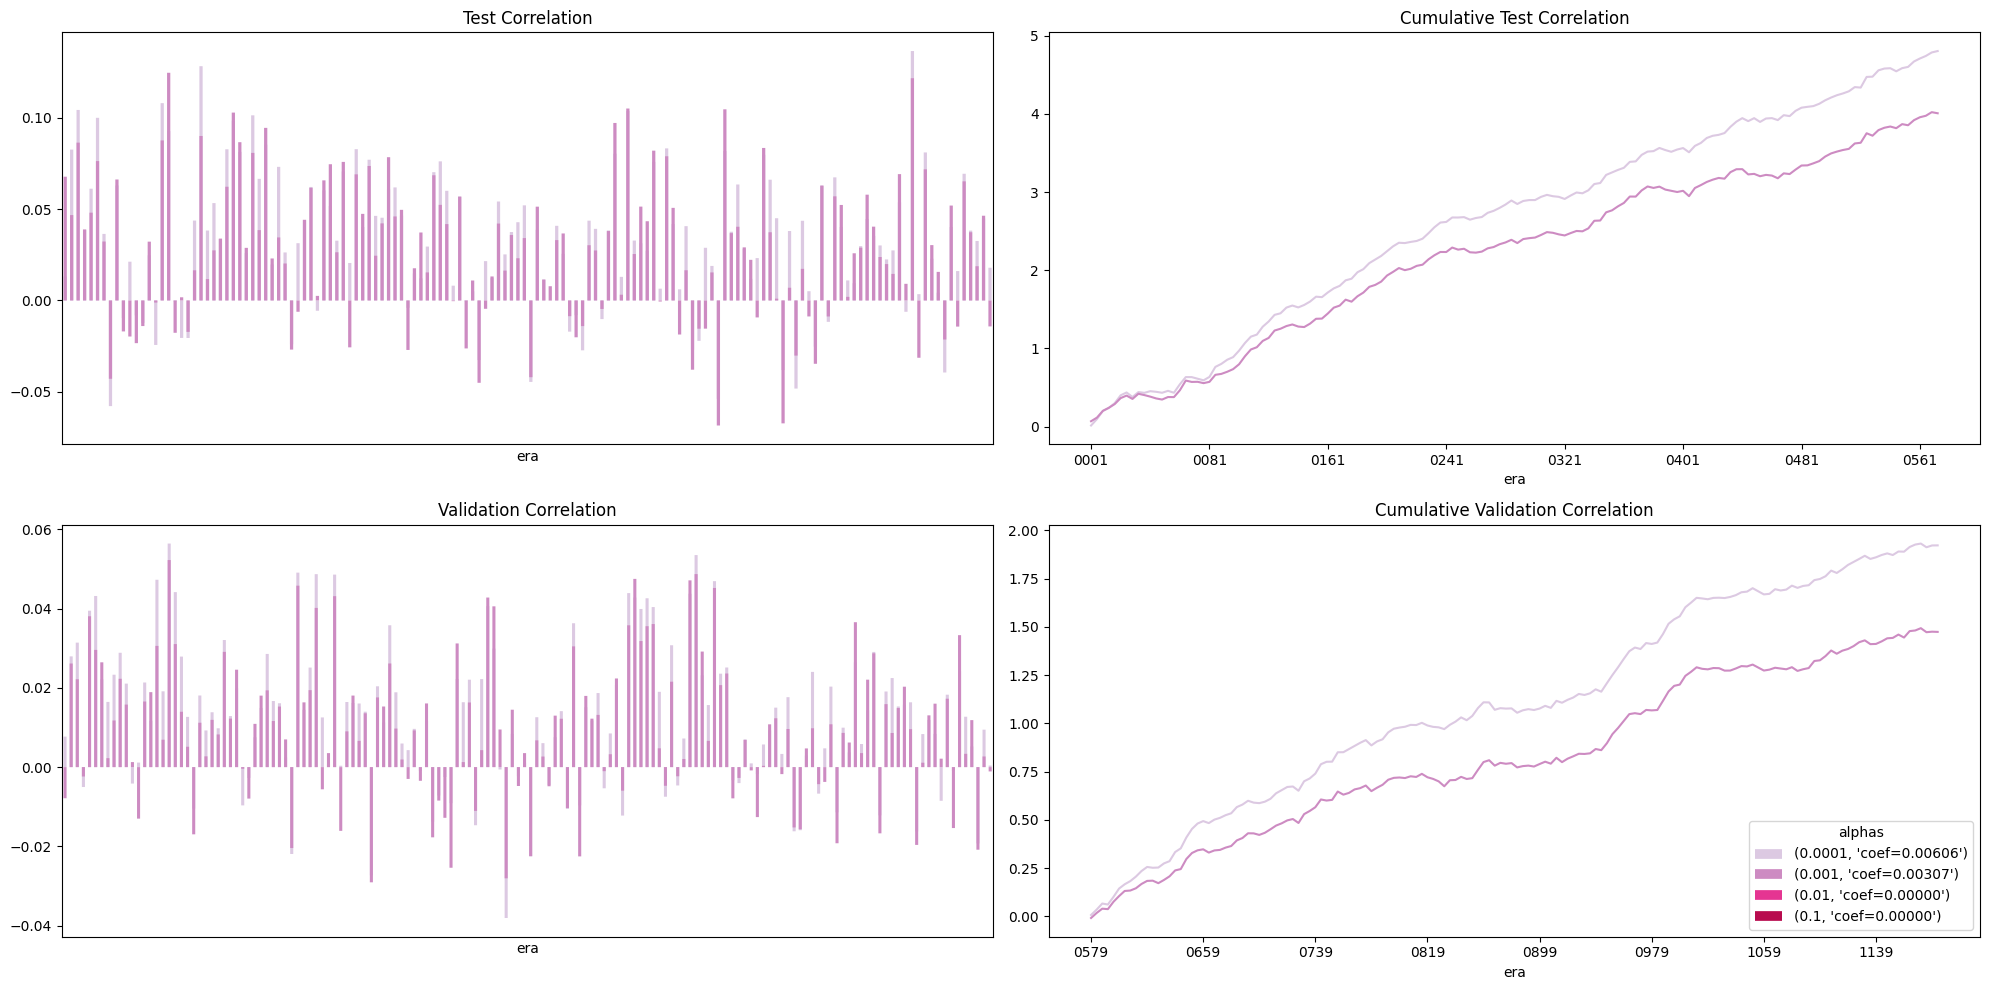

,lasso_0.0001_test,lasso_0.0001_val,lasso_0.001_test,lasso_0.001_val,lasso_0.01_test,lasso_0.01_val,lasso_0.1_test,lasso_0.1_val
mean,0.033372,0.012649,0.027842,0.009700,NaN,NaN,NaN,NaN
std,0.037704,0.017685,0.038752,0.017413,NaN,NaN,NaN,NaN
sharpe,0.885106,0.715215,0.718468,0.557046,NaN,NaN,NaN,NaN
max_drawdown,0.057772,0.054021,0.123868,0.064356,NaN,NaN,NaN,NaN


In [58]:
alphas = [0.0001, 0.001, 0.01, 0.1]
fig, axs = plt.subplots(2,2, figsize=(20, 10))
coefs = []
colors = sns.color_palette("PuRd", len(alphas))

for i, alpha in enumerate(alphas):
    lasso = Lasso(
        alpha=alpha, 
        random_state=42,
        max_iter=10000
        )
    lasso.fit(train_df[feature_set], train_df["target"])

    test_df["prediction"] = lasso.predict(test_df[feature_set])
    per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_lasso = calc_metricas(f'lasso_{alpha}_test', per_era_corr_test, df_metrics_lasso)

    validation["prediction"] = lasso.predict(validation[feature_set])
    per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
    df_metrics_lasso = calc_metricas(f'lasso_{alpha}_val', per_era_corr_val, df_metrics_lasso)

    custom_plots(per_era_corr_test, per_era_corr_val, colors[i])
    coefs.append(f'coef={np.linalg.norm(lasso.coef_):.5f}')

legend = [plt.Line2D([0], [0], linestyle="-", solid_capstyle='butt', color=colors[i % len(colors)], lw=7) for i in range(len(alphas))]
axs[1, 1].legend(legend, zip(alphas, coefs), title="alphas", loc='lower right')

plt.tight_layout()
plt.show()
df_metrics_lasso

4.3.2 LassoCV VS LR   

LassoCV es una variación de Lasso que permite calcular automáticamente el mejor alpha dentro de un rango establecido. Este modelo entrena utilizando dicho valor óptimo y se compara con el modelo base LR.

Nuevamente, se comprueba que la regularización en este dataset produce diferencias despreciables en comparación con LR, únicamente aporta mayor coste computacional innecesario.

C:\Users\chena\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.801e+03, tolerance: 2.195e+00
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\chena\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.691e+03, tolerance: 2.195e+00
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\chena\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or c

Best alpha: 6.250551925274028e-05


C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3305244561.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
C:\Users\chena\AppData\Local\Temp\ipykernel_7156\3305244561.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"],

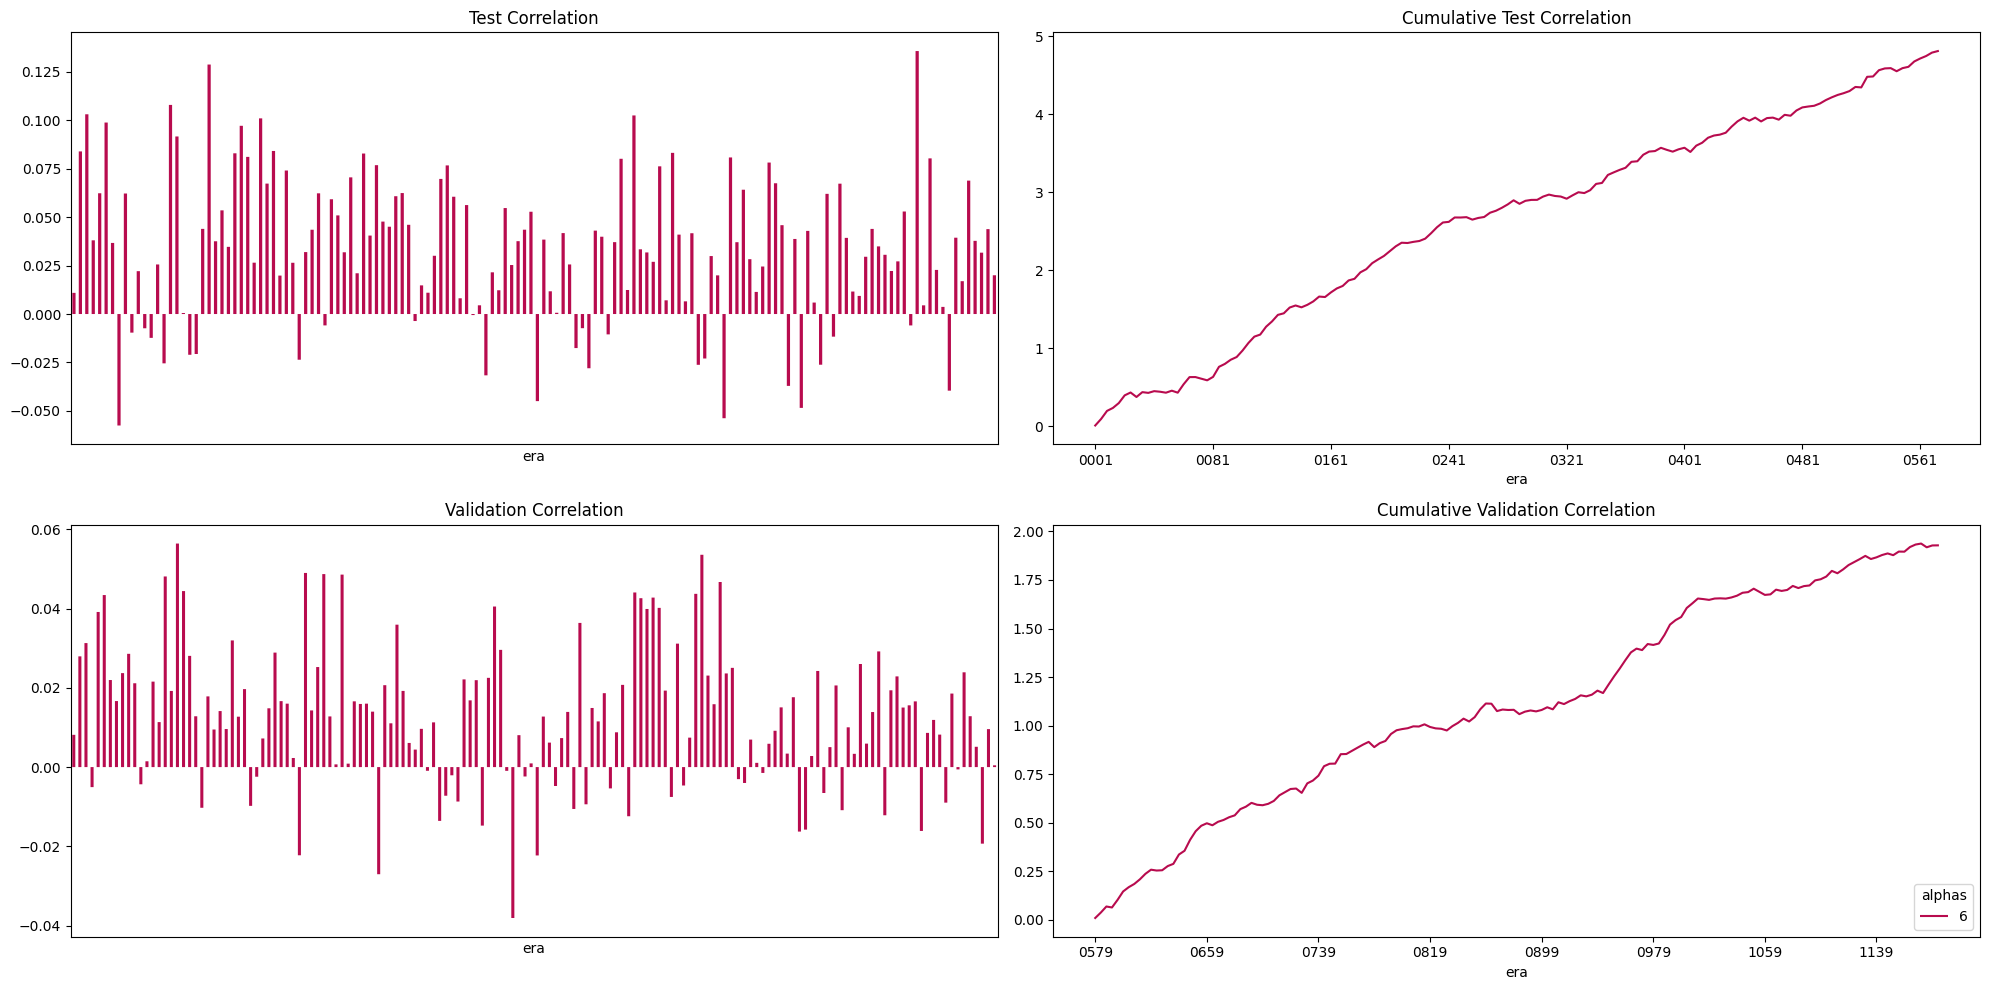

,lasso_0.0001_test,lasso_0.0001_val,lasso_0.001_test,lasso_0.001_val,lasso_0.01_test,lasso_0.01_val,lasso_0.1_test,lasso_0.1_val,lasso_6.250551925274028e-05_test,lasso_6.250551925274028e-05_val
mean,0.033372,0.012649,0.027842,0.009700,NaN,NaN,NaN,NaN,0.033411,0.012688
std,0.037704,0.017685,0.038752,0.017413,NaN,NaN,NaN,NaN,0.037637,0.017692
sharpe,0.885106,0.715215,0.718468,0.557046,NaN,NaN,NaN,NaN,0.887714,0.717140
max_drawdown,0.057772,0.054021,0.123868,0.064356,NaN,NaN,NaN,NaN,0.057561,0.054738


In [59]:
lasso_cv = LassoCV(alphas=np.logspace(-50, 1), cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(train_df[feature_set], train_df["target"])
print("Best alpha:", lasso_cv.alpha_)

fig, axs = plt.subplots(2,2, figsize=(20, 10))

test_df["prediction"] = lasso_cv.predict(test_df[feature_set])
per_era_corr_test = test_df.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lasso = calc_metricas(f'lasso_{lasso_cv.alpha_}_test', per_era_corr_test, df_metrics_lasso)

validation["prediction"] = lasso_cv.predict(validation[feature_set])
per_era_corr_val = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))
df_metrics_lasso = calc_metricas(f'lasso_{lasso_cv.alpha_}_val', per_era_corr_val, df_metrics_lasso)

custom_plots(per_era_corr_test, per_era_corr_val, colors[-1])

legend = [plt.Line2D([0], [0], linestyle="-", solid_capstyle='butt', color=colors[-1])]
axs[1, 1].legend(legend, f'{lasso_cv.alpha_} {np.linalg.norm(lasso_cv.coef_)}', title="alphas", loc='lower right')

plt.tight_layout()
plt.show()
df_metrics_lasso

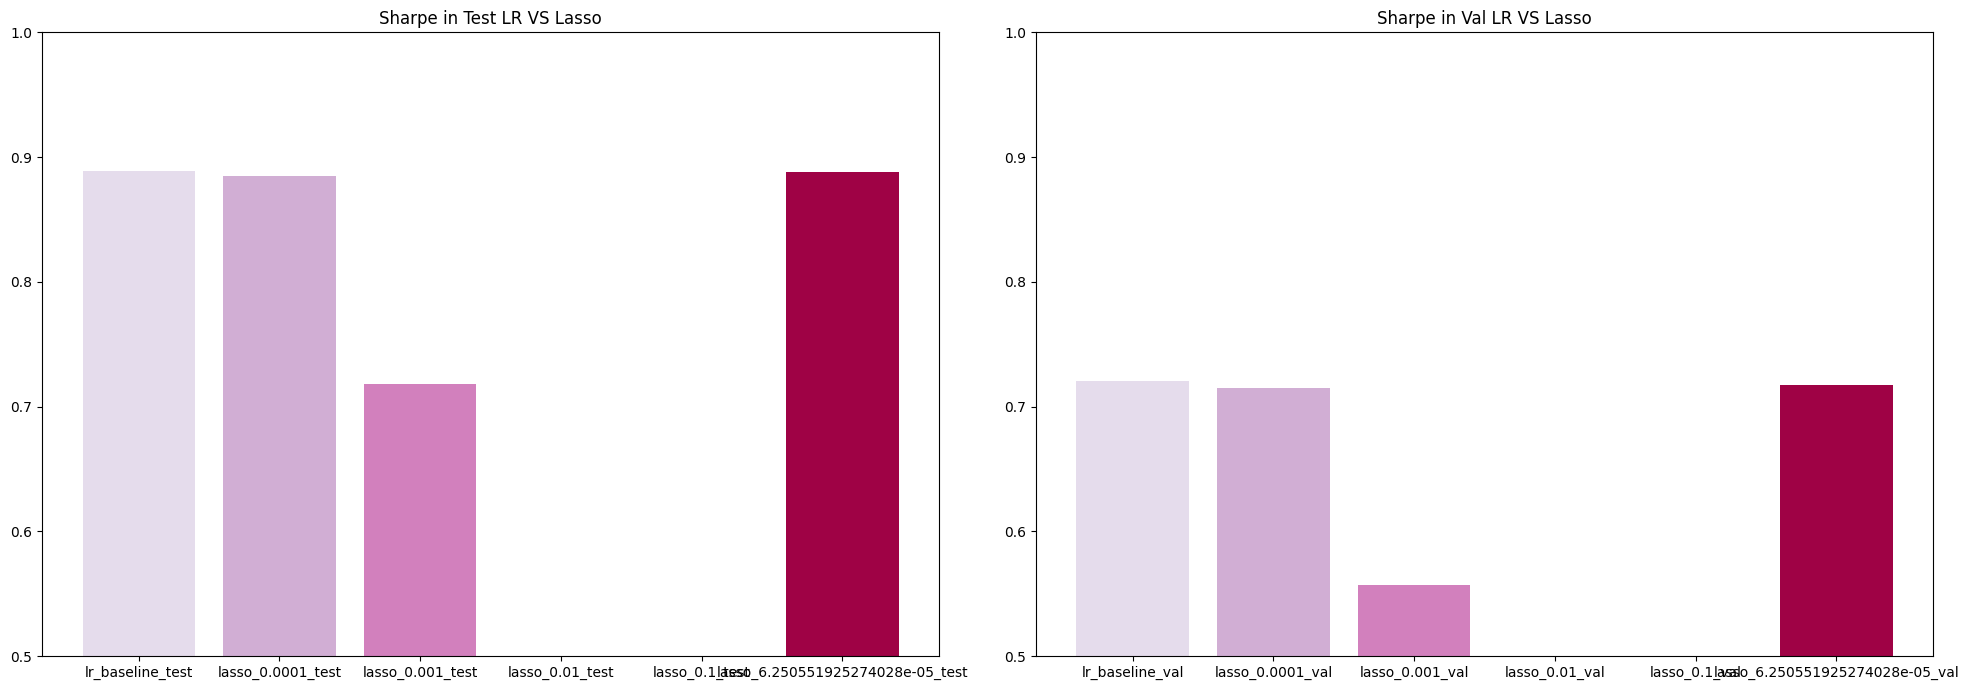

In [60]:
lasso_test = pd.concat(
    [df_metrics_lr[["lr_baseline_test"]],
    df_metrics_lasso[[i for i in df_metrics_lasso.columns if i.endswith("_test")]]],
    axis=1)
lasso_val = pd.concat(
    [df_metrics_lr[["lr_baseline_val"]],
    df_metrics_lasso[[i for i in df_metrics_lasso.columns if i.endswith("_val")]]],
    axis=1)

fig, axs = plt.subplots(1, 2, figsize=(20,7))
axs[0].bar(x=lasso_test.columns, height=lasso_test.loc["sharpe"], color=sns.color_palette("PuRd", len(alphas) + 2))
axs[1].bar(x=lasso_val.columns, height=lasso_val.loc["sharpe"], color=sns.color_palette("PuRd", len(alphas) + 2))

axs[0].set_ylim(0.5, 1)
axs[1].set_ylim(0.5, 1)
axs[0].set_title('Sharpe in Test LR VS Lasso')
axs[1].set_title('Sharpe in Val LR VS Lasso')

plt.tight_layout()

### 5. Submission

In [61]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set_m)

# Genera predicciones en vivo
live_predictions = xgb.predict(live_features[feature_set_m])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

with open('submission.pkl', 'wb') as f:
    cloudpickle.dump(live_predictions, f)

2025-11-04 13:20:00,690 INFO numerapi.utils: target file already exists
2025-11-04 13:20:00,690 INFO numerapi.utils: download complete
